# Lección 12.3 · Clustering y genes marcadores

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.3_clustering_marcadores.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 12 — Transcriptómica de célula única** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 12.1 (QC y normalización) y 12.2 (PCA, t-SNE y UMAP); rangos y valores $p$ (Módulo 11) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Construir** desde cero el grafo de $k$ vecinos más cercanos (kNN) de un conjunto de células y **ponderarlo** por
   vecinos compartidos (SNN, índice de Jaccard), y **explicar** por qué los métodos modernos agrupan células sobre un
   grafo y no con $k$-medias.
2. **Calcular** a mano y en código la **modularidad** $Q_\gamma$ de una partición, e **interpretar** el parámetro de
   resolución $\gamma$.
3. **Programar** el algoritmo de **Louvain** (movimiento local con la ganancia $\Delta Q$ y agregación), **compararlo**
   con **Leiden** de Scanpy y **explicar** qué defecto de Louvain corrige la fase de refinamiento.
4. **Barrer** la resolución y **reconocer** que un *cluster* no es un tipo celular.
5. **Aplicar** la prueba de suma de rangos de **Wilcoxon** (a mano, desde cero y con Scanpy), **leer** su estadístico
   como un AUC y **desconfiar** de sus valores $p$ (doble uso de los datos).
6. **Anotar** los tipos celulares de la sangre periférica de un donante real (PBMC 3k de 10x Genomics) con marcadores
   canónicos y un *dot plot*, y **estimar** las proporciones de cada población como en un inmunofenotipo.
7. **Diagnosticar** un efecto de lote y **corregirlo** con una versión didáctica de Harmony.

## 🗺️ Mapa de la clase

1. Un hemograma de alta resolución: la sangre como caso clínico
2. Los datos: PBMC 3k (real) y la simulación del libro (con verdad conocida)
3. El grafo de vecinos más cercanos: kNN y SNN (🔍 interactivo)
4. Modularidad: ¿qué es una buena partición?
5. Louvain desde cero y su corrección, Leiden (🎬 animación)
6. ¿Cuántos *clusters*? La resolución (🎬 animación)
7. Genes marcadores: Wilcoxon a mano, desde cero y con Scanpy (🔍 interactivo)
8. Anotación de tipos celulares y *dot plot* (🔍 interactivo)
9. Efectos de lote e integración con Harmony
10. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Clustering y genes marcadores» del capítulo 12 del libro
> *Bioinformática Práctica*. Usamos sus símbolos ($\mathcal{N}_k(i)$, $w_{ij}$, $A_{ij}$, $k_i$, $m$, $\gamma$,
> $Q_\gamma$, $k_{i,C}$, $\Sigma_C$, $U$, $R_1$, $n_1$, $n_2$, AUC), reproducimos su ejemplo resuelto «Wilcoxon a mano»
> cifra por cifra y rehacemos sus figuras (grafo kNN, barrido de resolución, *dot plot* y lotes) con la **misma
> simulación** del libro: unas 3 085 células mononucleares con siete tipos conocidos. Después aplicamos todo a datos
> **reales**. El notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, math, time, tarfile, warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats, sparse
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import scanpy as sc
    import igraph, leidenalg  # noqa: F401  (Leiden)
except ImportError:
    %pip install -q scanpy leidenalg igraph "networkx<3.6" "pandas=={pd.__version__}" "numpy=={np.__version__}"   # networkx < 3.6: el Louvain del libro
    import scanpy as sc
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

sc.settings.verbosity = 0
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name, url=None):
    """Ruta de un archivo del curso: 1) ../data; 2) la URL original; 3) copia en el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if os.path.exists(name):
        return name
    for src in ([url] if url else []) + [f"{RAW}/data/{name}"]:
        try:
            urllib.request.urlretrieve(src, name)
            return name
        except Exception as e:  # red caída o URL movida: probamos la siguiente fuente
            print("  no se pudo descargar de", src, "→", type(e).__name__)
    raise FileNotFoundError(name)

print("scanpy", sc.__version__, "| networkx", nx.__version__, "| numpy", np.__version__)

Entorno listo ✔  |  Colab: False


scanpy 1.12.4 | networkx 3.5 | numpy 2.0.2


## 1. Un hemograma de alta resolución: la sangre como caso clínico

Cuando un médico pide un **hemograma**, el laboratorio cuenta los glóbulos rojos, las plaquetas y los glóbulos blancos, y
separa estos últimos en unas pocas clases (neutrófilos, linfocitos, monocitos…). Si sospecha una inmunodeficiencia, una
infección por VIH o una leucemia, pide algo más fino: un **inmunofenotipo por citometría de flujo**. Las células pasan
una a una frente a un láser y se miden unas pocas proteínas de superficie marcadas con anticuerpos fluorescentes
(CD3, CD4, CD8, CD19, CD14, CD16, CD56…). Con esas medidas se cuentan, por ejemplo, los **linfocitos T CD4**, cuyo
recuento es la cifra clave para seguir a un paciente con VIH.

La transcriptómica de célula única hace lo mismo, pero en lugar de medir 10 proteínas elegidas de antemano mide **miles
de ARN mensajeros** en cada célula. El precio es que nadie le dice qué célula es cuál: hay que **descubrir** los grupos.
Esta clase trata exactamente de eso, en tres pasos:

1. **Agrupar** (*clustering*): decidir qué células se parecen lo suficiente como para pertenecer a una misma población.
2. **Caracterizar**: encontrar los **genes marcadores** que distinguen a cada grupo del resto.
3. **Anotar**: poner nombre biológico a cada grupo («monocitos clásicos», «linfocitos B»…) comparando esos genes con lo
   que ya sabemos de inmunología.

¿Cómo se descubren grupos sin conocer las categorías? Piense en una fiesta grande: nadie conoce a todos, pero cada
invitado conoce bien a unas pocas personas. Si dibujamos a cada invitado como un punto y unimos con una línea a los que
se conocen, sin mirar edades ni profesiones, los grupos aparecen solos: los compañeros de la oficina, la familia, los
amigos del colegio. Dentro de cada grupo hay muchas líneas; entre grupos, pocas, casi siempre a través de alguien que
pertenece a dos mundos. Agrupar células funciona igual: no definimos de antemano qué es un linfocito T; dejamos que cada
célula «conozca» a sus vecinas más parecidas y buscamos **comunidades densas** en esa red.

> 🤔 **Antes de seguir, piense.** En la fiesta, ¿qué pasaría con los grupos si obligáramos a cada invitado a «conocer»
> exactamente a 50 personas, cuando la fiesta tiene grupos de 10? ¿Y si sólo pudiera conocer a 1? Guarde su respuesta:
> es la pregunta de cómo elegir $k$.

## 2. Los datos: PBMC 3k (real) y la simulación del libro

Trabajaremos con dos conjuntos complementarios:

| | **Simulación del libro** | **PBMC 3k (real)** |
|---|---|---|
| Origen | `figuras/cap12/generar.py` del libro, mismas semillas | 10x Genomics, donante sano (Zheng *et al.*, 2017) |
| Células | 3 085 (tras QC y eliminación de dobletes) | 2 700 códigos de barras; 2 638 tras QC |
| Tipos | 7, **conocidos** (T CD4, T CD8, NK, B, Mono CD14, Mono FCGR3A, DC) | desconocidos: ¡hay que descubrirlos! |
| Sirve para | medir cuánto se equivoca cada método (ARI, pureza) | practicar el flujo real y la anotación |

De la simulación guardamos en `data/123_sim_libro.npz` sólo lo que esta lección necesita: las 30 primeras PC de las
3 085 células (`Z30`), su tipo verdadero (`T`), las coordenadas UMAP de la lección 12.2, la expresión log-normalizada de
los 32 genes marcadores simulados y el experimento de lotes. Con eso reproducimos exactamente el grafo del libro.

**PBMC 3k** son 2 700 células mononucleares de sangre periférica (linfocitos y monocitos; los neutrófilos y los
glóbulos rojos se eliminan con un gradiente de Ficoll) de un donante sano, secuenciadas con la química 3′ v1 de 10x
Genomics. Es el conjunto «de bolsillo» con el que aprendió medio mundo: el tutorial clásico de Seurat y el de Scanpy lo
usan, así que podrá comparar sus resultados con los de miles de personas.

In [2]:
# ---- Simulación del libro (7 tipos conocidos) ----
sim = np.load(course_file("123_sim_libro.npz"))
Z30, T_true, U_sim = sim["Z30"], sim["T"].astype(int), sim["umap"]
TYPES = [str(t) for t in sim["tipos"]]
print("Simulación:", Z30.shape[0], "células ×", Z30.shape[1], "PC;  tipos:", TYPES)
print("  células por tipo verdadero:", dict(zip(TYPES, np.bincount(T_true).tolist())))

# ---- PBMC 3k de 10x Genomics (real) ----
URL_10X = ("https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/"
           "pbmc3k_filtered_gene_bc_matrices.tar.gz")
tgz = course_file("12_pbmc3k_filtered.tar.gz", URL_10X)
if not os.path.exists("pbmc3k/filtered_gene_bc_matrices"):
    with tarfile.open(tgz) as tf:
        tf.extractall("pbmc3k")
adata = sc.read_10x_mtx("pbmc3k/filtered_gene_bc_matrices/hg19", var_names="gene_symbols")
adata.var_names_make_unique()
print("PBMC 3k:", adata.n_obs, "códigos de barras ×", adata.n_vars, "genes")

Simulación: 3085 células × 30 PC;  tipos: ['T CD4', 'T CD8', 'NK', 'B', 'Mono CD14', 'Mono FCGR3A', 'DC']
  células por tipo verdadero: {'T CD4': 869, 'T CD8': 475, 'NK': 323, 'B': 447, 'Mono CD14': 577, 'Mono FCGR3A': 236, 'DC': 158}


PBMC 3k: 2700 códigos de barras × 32738 genes


### Repaso exprés de las lecciones 12.1 y 12.2

La celda siguiente repite, en pocas líneas y con Scanpy, lo que hicimos con detalle en las lecciones anteriores. Para
poder comparar con la literatura usamos aquí los umbrales **fijos** del tutorial clásico de Seurat (entre 200 y 2 500
genes detectados y menos de 5 % de lecturas mitocondriales); en la lección 12.1 vimos cómo elegirlos con la mediana y la
MAD, que en este conjunto da un corte mitocondrial muy parecido (≈ 4,4 %).

| Paso | Qué hace | Lección |
|---|---|---|
| QC | descarta gotas vacías, células rotas (mucho ARN mitocondrial) y posibles dobletes (demasiados genes) | 12.1 |
| Normalización | CP10k: cada célula escalada a 10 000 UMI, y luego $\log(1+x)$ | 12.1 |
| HVG | 2 000 genes altamente variables | 12.1 |
| PCA | 50 componentes sobre los HVG escalados; usaremos 30 | 12.2 |
| UMAP | sólo para **dibujar** (¡no para agrupar!) | 12.2 |

In [3]:
t0 = time.time()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
qc_ok = ((adata.obs.n_genes_by_counts > 200) & (adata.obs.n_genes_by_counts < 2500)
         & (adata.obs.pct_counts_mt < 5))
adata = adata[qc_ok].copy()
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()                 # cuentas crudas (UMI)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata                                       # expresión log-normalizada de TODOS los genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
hv = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(hv, max_value=10)
sc.tl.pca(hv, n_comps=50, random_state=0)
adata.obsm["X_pca"] = hv.obsm["X_pca"]
Zp = adata.obsm["X_pca"][:, :30]                        # espacio donde mediremos distancias
print(f"Tras QC: {adata.n_obs} células × {adata.n_vars} genes  ({time.time() - t0:.1f} s)")

Tras QC: 2638 células × 13656 genes  (2.4 s)


## 3. El grafo de vecinos más cercanos

### 3.1 ¿Por qué no basta con $k$-medias?

El método de agrupamiento que casi todos aprendemos primero, **$k$-medias**, coloca $K$ centros y asigna cada punto al
más cercano. Funciona bien cuando los grupos son **esféricos**, de **tamaño parecido** y cuando sabemos **cuántos** hay.
La sangre no cumple ninguna de las tres condiciones: hay poblaciones de más de mil células (linfocitos T) junto a otras
de una docena (plaquetas, células dendríticas plasmacitoides), y hay formas alargadas producidas por estados continuos
(un linfocito T que pasa de virgen a memoria). Por eso Seurat y Scanpy trabajan sobre un **grafo**: cada célula se une
a sus $k$ vecinas más cercanas en el espacio de las PC, y después se buscan **comunidades** en ese grafo. El grafo sólo
usa información **local** (¿quién está cerca de quién?), así que no le importan ni la forma ni el tamaño de los grupos.

### 3.2 Resuelto a mano: siete células y un puente

Tomemos siete células en el plano de las dos primeras PC. Tres (A, B, C) forman un grupo, tres (D, E, F) otro, y G
está entre ambos: podría ser un **doblete** (dos células en una misma gota) o una célula en transición.

| Célula | A | B | C | D | E | F | G |
|---|---|---|---|---|---|---|---|
| PC1 | 0 | 1 | 0,5 | 4 | 5 | 4,5 | 2,6 |
| PC2 | 0 | 0 | 0,9 | 0 | 0 | 0,9 | 0,5 |

Con $k=2$, las dos vecinas más cercanas de cada célula son: $\mathcal{N}_2(A)=\{B,C\}$, $\mathcal{N}_2(B)=\{A,C\}$,
$\mathcal{N}_2(C)=\{A,B\}$, e igual en el otro grupo: $\mathcal{N}_2(D)=\{E,F\}$, etc. Para G, las distancias más cortas
son a D (1,49) y a B (1,68), así que $\mathcal{N}_2(G)=\{D,B\}$. **Pero nadie tiene a G entre sus dos vecinas.**

El grafo kNN une $i$ y $j$ si **alguno** de los dos elige al otro, así que G queda conectada a B y a D: ¡un camino entre
los dos grupos! El grafo de **vecinos compartidos** (SNN) mide cuánto se parecen los *vecindarios*:

* Arista A–B: $\mathcal{N}_2(A)\cap\mathcal{N}_2(B)=\{C\}$ (1 célula) y $\mathcal{N}_2(A)\cup\mathcal{N}_2(B)=\{A,B,C\}$
  (3 células), luego $w_{AB}=1/3\approx 0{,}33$.
* Arista B–G: $\mathcal{N}_2(B)\cap\mathcal{N}_2(G)=\varnothing$ y la unión tiene 4 células ($A,C,D,B$), luego
  $w_{BG}=0/4=0$.

El puente pesa **cero**: B y G son vecinas por accidente, no porque vivan en el mismo barrio.

### 3.3 La definición

Sea $\mathcal{N}_k(i)$ el conjunto de las $k$ células más cercanas a $i$ (distancia euclídea en las primeras PC). El
**grafo kNN** tiene una arista entre $i$ y $j$ si $j\in\mathcal{N}_k(i)$ **o** $i\in\mathcal{N}_k(j)$. En el grafo de
**vecinos compartidos** (SNN), cada arista recibe el peso de Jaccard

$$
w_{ij}=\frac{\lvert\mathcal{N}_k(i)\cap\mathcal{N}_k(j)\rvert}{\lvert\mathcal{N}_k(i)\cup\mathcal{N}_k(j)\rvert},
$$

que es alto cuando dos células comparten vecindario y bajo cuando la arista es un «puente» accidental.

| Símbolo | Significado |
|---|---|
| $\mathcal{N}_k(i)$ | las $k$ células más cercanas a la célula $i$ (sin contarse a sí misma) |
| $k$ | número de vecinos (típico: 10–30; Scanpy usa 15 por defecto) |
| $\lvert\cdot\rvert$ | número de elementos de un conjunto |
| $\cap,\ \cup$ | intersección (vecinas comunes) y unión (vecinas de alguna de las dos) |
| $w_{ij}\in[0,1]$ | peso de Jaccard de la arista $i$–$j$ |

> 🤔 **Antes de ejecutar, prediga.** Con $k=2$, ¿cuántas aristas tendrá el grafo kNN de las siete células? (Cuente las
> parejas **distintas**: si A elige a B y B elige a A, es una sola arista.)

In [4]:
toy_names = list("ABCDEFG")
toy_xy = np.array([[0, 0], [1, 0], [0.5, 0.9], [4, 0], [5, 0], [4.5, 0.9], [2.6, 0.5]])

def neighbor_sets(Z, k):
    """N_k(i) de cada célula: índices de sus k vecinas más cercanas (sin ella misma)."""
    D = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(D, np.inf)
    return [set(np.argsort(D[i])[:k]) for i in range(len(Z))], D

def jaccard(Ni, Nj):
    return len(Ni & Nj) / len(Ni | Nj)

N2, Dtoy = neighbor_sets(toy_xy, k=2)
edges = sorted({tuple(sorted((i, j))) for i in range(7) for j in N2[i]})
rows = [(toy_names[i] + "–" + toy_names[j], round(Dtoy[i, j], 2),
         ", ".join(toy_names[x] for x in sorted(N2[i] & N2[j])) or "∅",
         len(N2[i] | N2[j]), round(jaccard(N2[i], N2[j]), 3)) for i, j in edges]
print("Vecinas (k=2):", {toy_names[i]: "".join(sorted(toy_names[x] for x in N2[i])) for i in range(7)})
print(f"Aristas del grafo kNN: {len(edges)}")
pd.DataFrame(rows, columns=["arista", "distancia", "vecinas comunes", "|unión|", "w (Jaccard)"])

Vecinas (k=2): {'A': 'BC', 'B': 'AC', 'C': 'AB', 'D': 'EF', 'E': 'DF', 'F': 'DE', 'G': 'BD'}
Aristas del grafo kNN: 8


,arista,distancia,vecinas comunes,|unión|,w (Jaccard)
0,A–B,1.00,C,3,0.333
1,A–C,1.03,B,3,0.333
2,B–C,1.03,A,3,0.333
3,B–G,1.68,∅,4,0.000
4,D–E,1.00,F,3,0.333
5,D–F,1.03,E,3,0.333
6,D–G,1.49,∅,4,0.000
7,E–F,1.03,D,3,0.333


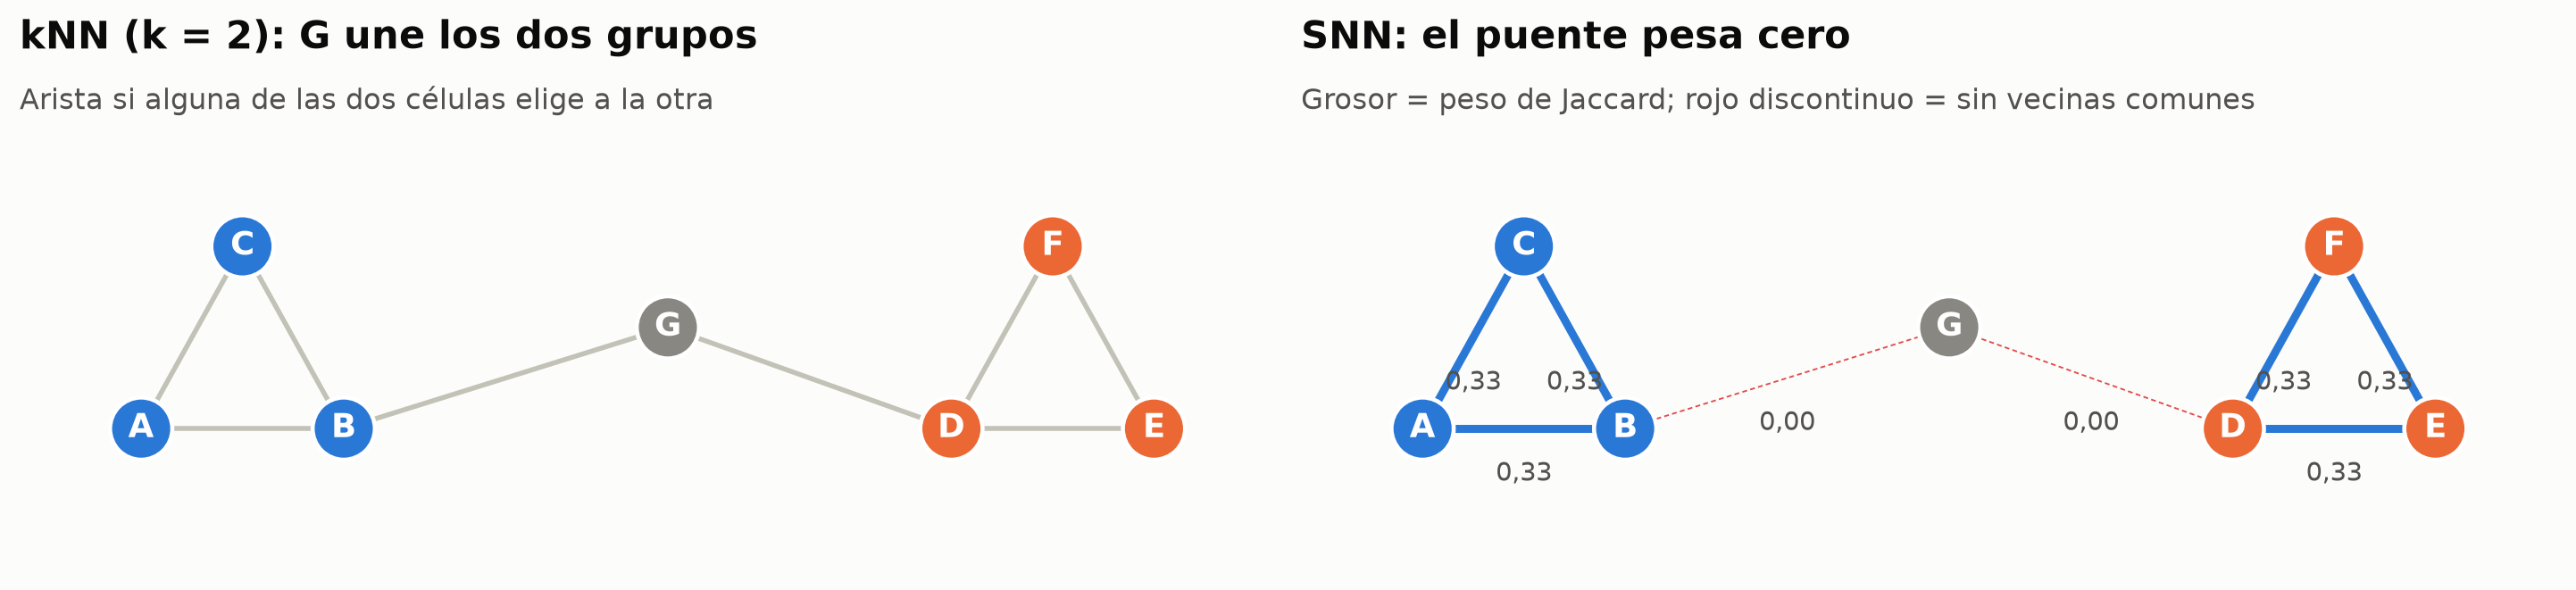

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, weighted in zip(axs, (False, True)):
    for i, j in edges:
        w = jaccard(N2[i], N2[j])
        lw = 1.8 if not weighted else 0.6 + 7 * w
        col = ec.BASELINE if not weighted else (ec.RED if w == 0 else ec.BLUE)
        ls = "-" if (not weighted or w > 0) else (0, (3, 2))
        ax.plot(*toy_xy[[i, j]].T, color=col, lw=lw, ls=ls, zorder=1)
        if weighted:
            mid = toy_xy[[i, j]].mean(0)
            ax.text(mid[0], mid[1] - 0.16, f"{w:.2f}".replace(".", ","), ha="center", va="top",
                    fontsize=9.5, color=ec.INK_2)
    cols = [ec.BLUE] * 3 + [ec.ORANGE] * 3 + [ec.MUTED]
    ax.scatter(*toy_xy.T, s=520, c=cols, zorder=2, edgecolor="white", lw=1.5)
    for n, (x, y) in zip(toy_names, toy_xy):
        ax.text(x, y, n, ha="center", va="center", color="white", fontsize=12, fontweight="bold", zorder=3)
    ax.set_xlim(-0.6, 5.6); ax.set_ylim(-0.7, 1.5); ax.set_aspect("equal"); ax.axis("off")
ec.title(axs[0], "kNN (k = 2): G une los dos grupos", "Arista si alguna de las dos células elige a la otra")
ec.title(axs[1], "SNN: el puente pesa cero", "Grosor = peso de Jaccard; rojo discontinuo = sin vecinas comunes")
plt.show()

> 🔎 **Qué observamos.** El grafo kNN tiene 8 aristas: 3 en cada triángulo y 2 que unen G con B y con D. En el grafo
> SNN, las aristas internas pesan 1/3 y las dos que tocan a G pesan 0. Un algoritmo de agrupamiento sobre el grafo SNN
> no tendría ningún incentivo para juntar los dos grupos a través de G. Con 3 000 células el efecto es el mismo, sólo
> que estadístico: las aristas «de frontera» tienen pesos menores que las internas.

### 3.4 El grafo kNN de la simulación del libro

Ahora el mismo cálculo a escala: 3 085 células en 30 PC, $k=15$. Usamos `NearestNeighbors` de scikit-learn (un
árbol de búsqueda) en lugar de la matriz completa de distancias, y guardamos el grafo como **matriz dispersa**:
de los $3\,085^2\approx 9{,}5$ millones de pares, sólo unos 77 000 son aristas.

> 🤔 **Antes de ejecutar, prediga.** Cada célula elige 15 vecinas. ¿El **grado medio** (número medio de aristas por
> célula) del grafo simetrizado será 15, menos de 15 o más de 15?

In [6]:
def knn_graph(Z, k=15):
    """Grafo kNN simétrico (0/1) como matriz dispersa, y la lista de vecinas de cada célula."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(Z)
    d, idx = nn.kneighbors(Z)                        # la primera vecina es la propia célula
    n = Z.shape[0]
    rows = np.repeat(np.arange(n), k)
    A = sparse.csr_matrix((np.ones(n * k), (rows, idx[:, 1:].ravel())), shape=(n, n))
    A = ((A + A.T) > 0).astype(float)                # arista si i elige a j O j elige a i
    return A, idx[:, 1:]

def snn_weights(A, nbrs):
    """Peso de Jaccard |N(i)∩N(j)| / |N(i)∪N(j)| para cada arista de A."""
    n, k = nbrs.shape
    M = sparse.csr_matrix((np.ones(n * k), (np.repeat(np.arange(n), k), nbrs.ravel())), shape=(n, n))
    C = A.tocoo()
    inter = np.asarray(M[C.row].multiply(M[C.col]).sum(1)).ravel()     # vecinas comunes
    w = inter / (2 * k - inter)                                         # |unión| = k + k − |intersección|
    return sparse.csr_matrix((w, (C.row, C.col)), shape=A.shape)

A_sim, nbrs_sim = knn_graph(Z30, k=15)
deg = np.asarray(A_sim.sum(1)).ravel()
print(f"Aristas: {A_sim.nnz // 2:,}   grado medio: {deg.mean():.1f}   (mín {deg.min():.0f}, máx {deg.max():.0f})")
W_sim = snn_weights(A_sim, nbrs_sim)
C = sparse.triu(A_sim).tocoo()
same_type = T_true[C.row] == T_true[C.col]
w_edges = np.asarray(W_sim[C.row, C.col]).ravel()
print(f"Aristas entre tipos verdaderos distintos: {np.mean(~same_type):.1%}")
print(f"Peso SNN medio: dentro de un tipo {w_edges[same_type].mean():.3f}  |  entre tipos {w_edges[~same_type].mean():.3f}")

Aristas: 38,688   grado medio: 25.1   (mín 15, máx 154)
Aristas entre tipos verdaderos distintos: 12.7%
Peso SNN medio: dentro de un tipo 0.105  |  entre tipos 0.062


> 🔎 **Qué observamos.** Reproducimos las cifras del libro: **38 688 aristas** y un **grado medio de 25,1**, mayor que
> 15 porque la simetrización añade las aristas recíprocas (si A elige a B pero B no elige a A, la arista aparece igual).
> Las células «populares» (en el centro de un grupo denso) acumulan muchas aristas; las periféricas, cerca de 15. Y el
> peso SNN de las aristas que cruzan de un tipo a otro es claramente menor que el de las internas: es la versión
> estadística del puente G.

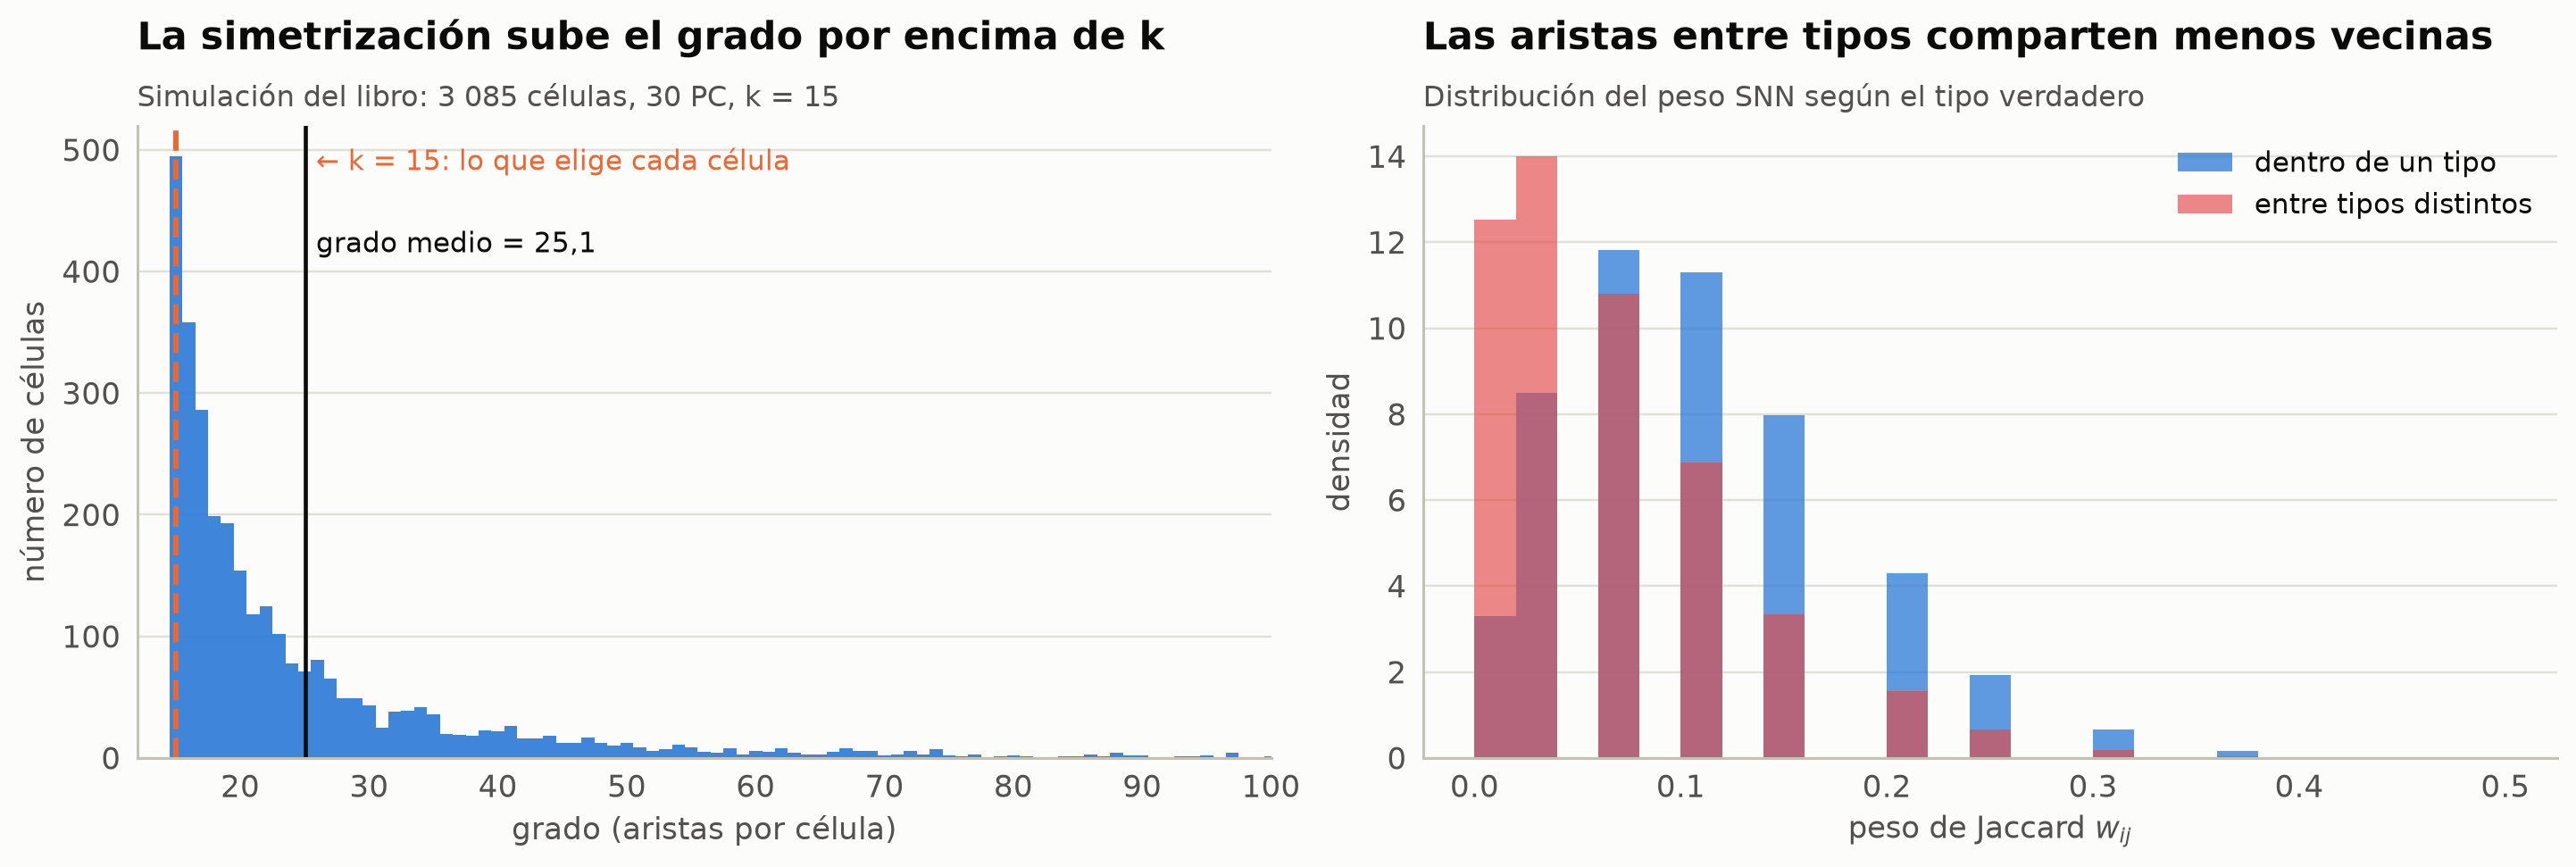

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axs[0]
ax.hist(deg, bins=np.arange(14.5, deg.max() + 1.5, 1), color=ec.BLUE, alpha=0.9)
ax.axvline(15, color=ec.ORANGE, lw=2, ls="--"); ax.axvline(deg.mean(), color=ec.INK, lw=1.5)
ax.text(deg.mean() + 0.8, ax.get_ylim()[1] * 0.93, "← k = 15: lo que elige cada célula", color=ec.ORANGE, fontsize=10)
ax.set_xlim(12, 100)
ax.text(deg.mean() + 0.8, ax.get_ylim()[1] * 0.80, f"grado medio = {deg.mean():.1f}".replace(".", ","), fontsize=10)
ax.set_xlabel("grado (aristas por célula)"); ax.set_ylabel("número de células")
ec.title(ax, "La simetrización sube el grado por encima de k", "Simulación del libro: 3 085 células, 30 PC, k = 15")
ax = axs[1]
bins = np.linspace(0, 0.5, 26)
ax.hist(w_edges[same_type], bins=bins, color=ec.BLUE, alpha=0.75, density=True, label="dentro de un tipo")
ax.hist(w_edges[~same_type], bins=bins, color=ec.RED, alpha=0.65, density=True, label="entre tipos distintos")
ax.set_xlabel("peso de Jaccard $w_{ij}$"); ax.set_ylabel("densidad")
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Las aristas entre tipos comparten menos vecinas", "Distribución del peso SNN según el tipo verdadero")
plt.show()

### 3.5 Explore el grafo (interactivo)

La figura siguiente dibuja el grafo kNN de 700 células de la simulación sobre sus coordenadas UMAP (lección 12.2). **Pase
el cursor** por las células: verá su tipo verdadero, su grado, el peso SNN medio de sus aristas y qué fracción de sus
vecinas es de **otro** tipo. Busque las células de la frontera entre T CD8 y NK: son las que harán sufrir al algoritmo.
Recuerde que el algoritmo de agrupamiento **no ve** estas coordenadas: sólo ve las aristas.

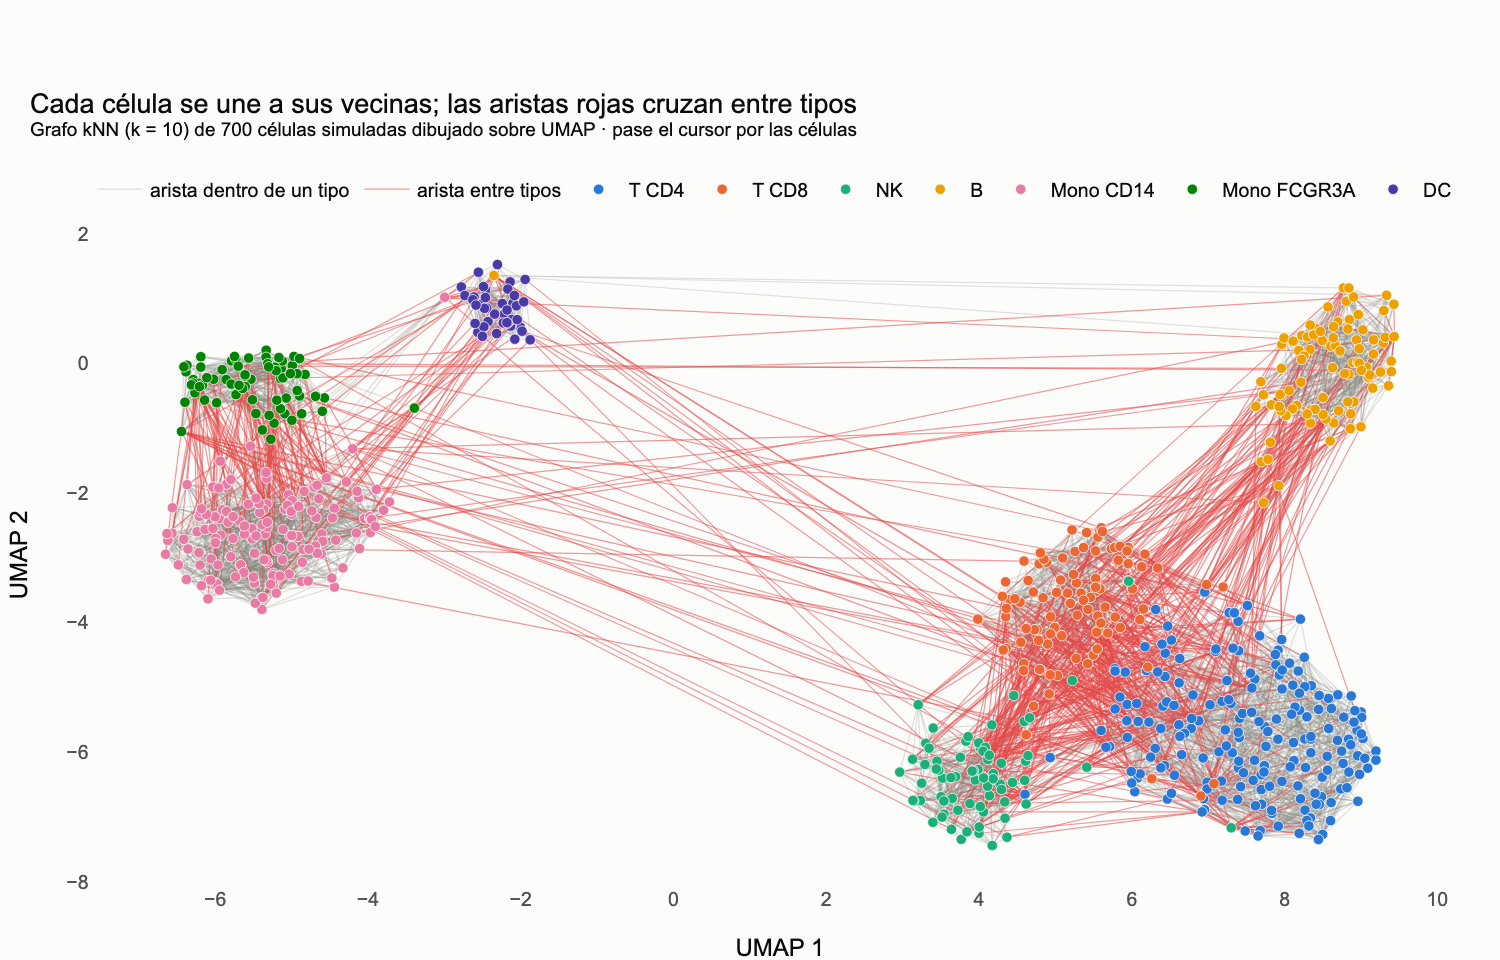

In [8]:
rng = np.random.default_rng(1)
sub = np.sort(rng.choice(len(Z30), 700, replace=False))
A_s, nb_s = knn_graph(Z30[sub], k=10)
W_s = snn_weights(A_s, nb_s)
Us, Ts = U_sim[sub], T_true[sub]
Cs = sparse.triu(A_s).tocoo()
cross = Ts[Cs.row] != Ts[Cs.col]
fig = go.Figure()
for mask, col, name in ((~cross, "rgba(137,135,129,0.25)", "arista dentro de un tipo"),
                        (cross, "rgba(227,73,72,0.55)", "arista entre tipos")):
    xs = np.column_stack([Us[Cs.row[mask], 0], Us[Cs.col[mask], 0], np.full(mask.sum(), np.nan)]).ravel()
    ys = np.column_stack([Us[Cs.row[mask], 1], Us[Cs.col[mask], 1], np.full(mask.sum(), np.nan)]).ravel()
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color=col, width=0.8),
                               hoverinfo="skip", name=name))
deg_s = np.asarray(A_s.sum(1)).ravel()
wmean = np.asarray(W_s.sum(1)).ravel() / deg_s
other = np.array([np.mean(Ts[A_s[i].indices] != Ts[i]) for i in range(len(sub))])
for t, name in enumerate(TYPES):
    m = Ts == t
    fig.add_trace(go.Scatter(
        x=Us[m, 0], y=Us[m, 1], mode="markers", name=name,
        marker=dict(size=7, color=ec.CATEGORICAL[t], line=dict(color="white", width=0.5)),
        customdata=np.column_stack([sub[m], deg_s[m], wmean[m], 100 * other[m]]),
        hovertemplate=("<b>célula %{customdata[0]}</b> · tipo verdadero: " + name +
                       "<br>grado (aristas): %{customdata[1]:.0f}"
                       "<br>peso SNN medio: %{customdata[2]:.2f}"
                       "<br>vecinas de otro tipo: %{customdata[3]:.0f} %<extra></extra>")))
fig.update_layout(
    title="Cada célula se une a sus vecinas; las aristas rojas cruzan entre tipos<br>"
          "<sup>Grafo kNN (k = 10) de 700 células simuladas dibujado sobre UMAP · pase el cursor por las células</sup>",
    xaxis=dict(title="UMAP 1", showgrid=False, zeroline=False), yaxis=dict(title="UMAP 2", showgrid=False, zeroline=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=640, margin=dict(t=150, l=60, r=20, b=50))
fig.show()

> 🔎 **Qué observamos.** Casi todas las aristas rojas se concentran en dos fronteras: entre los linfocitos T CD4, T CD8
> y NK, y entre los monocitos CD14, FCGR3A y las dendríticas. Son poblaciones **emparentadas** que comparten programas
> génicos (citotoxicidad; presentación de antígeno). Las células B, en cambio, están casi aisladas. Las células con
> mayor porcentaje de vecinas de otro tipo son, a menudo, dobletes residuales que QC no eliminó.

### 3.6 Lo que hace Scanpy

Scanpy (`sc.pp.neighbors`) no usa Jaccard, sino los **pesos difusos de UMAP** (lección 12.2), guardados en
`adata.obsp["connectivities"]`; la idea es la misma: aristas fuertes entre células que se eligen mutuamente y comparten
entorno. Un detalle práctico: en Scanpy, `n_neighbors=15` **incluye a la propia célula**, de modo que equivale a nuestro
$k=14$. Comprobémoslo en PBMC 3k.

In [9]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=0)
Csc = adata.obsp["connectivities"]
A_pb, nbrs_pb = knn_graph(Zp, k=14)
ours = set(zip(*sparse.triu(A_pb).nonzero()))
theirs = set(zip(*sparse.triu(Csc).nonzero()))
print(f"Aristas (nuestro kNN, k=14): {len(ours):,}   ·   aristas de Scanpy: {len(theirs):,}")
print(f"Coinciden: {len(ours & theirs) / len(ours | theirs):.1%} de la unión")
cw = np.asarray(Csc[tuple(np.array(list(ours & theirs)).T)]).ravel()
print(f"Pesos de Scanpy en esas aristas: mediana {np.median(cw):.2f}, rango {cw.min():.2f}–{cw.max():.2f}")

Aristas (nuestro kNN, k=14): 30,736   ·   aristas de Scanpy: 30,736
Coinciden: 100.0% de la unión
Pesos de Scanpy en esas aristas: mediana 0.19, rango 0.00–1.00


> 🔎 **Qué observamos.** Los dos grafos tienen exactamente las mismas aristas (con conjuntos más grandes, Scanpy busca
> vecinos con un método aproximado y pueden aparecer pequeñas diferencias). La diferencia está en los **pesos**: nuestro kNN es binario; el de Scanpy va de casi 0 (aristas débiles, vecinas lejanas) a 1.

> ✅ **Compruebe su comprensión.** (1) ¿Por qué el grafo kNN, que es **dirigido** en origen («A elige a B»), se
> simetriza antes de agrupar? (2) Si $k=15$, ¿cuál es el peso de Jaccard **máximo** que puede tener una arista, y cuándo
> se alcanza? (Pista: la unión nunca tiene menos de 15 elementos.)

## 4. Modularidad: ¿qué es una buena partición?

### 4.1 La idea

Una partición es buena si deja **muchas aristas dentro** de las comunidades y **pocas entre** ellas. Pero «muchas»
¿comparado con qué? Una comunidad formada por las células más conectadas del grafo tendría muchas aristas internas
aunque no hubiera estructura alguna, simplemente porque sus miembros tienen muchas aristas. Newman y Girvan (2004)
propusieron comparar con lo que se esperaría **por azar en un grafo aleatorio con los mismos grados**: si la célula $i$
tiene $k_i$ aristas y la $j$ tiene $k_j$, y repartimos al azar los $2m$ «extremos» de arista, el número esperado de
aristas entre ellas es $k_ik_j/2m$.

### 4.2 Resuelto a mano: dos triángulos y un puente

Seis células: un triángulo 1–2–3, otro 4–5–6 y una arista 3–4 que los une. Hay $m=7$ aristas; los grados son
$k=(2,2,3,3,2,2)$ y $2m=14$. Con comunidades $\{1,2,3\}$ y $\{4,5,6\}$, cada una tiene 3 aristas internas y una suma
de grados de $2+2+3=7$. La modularidad es, para cada comunidad, (fracción de aristas internas) − (fracción esperada):

$$
Q_1=\underbrace{\left[\tfrac{3}{7}-\left(\tfrac{7}{14}\right)^2\right]}_{\{1,2,3\}}+
\underbrace{\left[\tfrac{3}{7}-\left(\tfrac{7}{14}\right)^2\right]}_{\{4,5,6\}}=2\,(0{,}4286-0{,}25)=0{,}357 .
$$

Si ponemos las seis células en **una sola** comunidad: $Q_1=\tfrac{7}{7}-\left(\tfrac{14}{14}\right)^2=0$. Si cada
célula va **sola**: no hay aristas internas y $Q_1=-\sum_i (k_i/2m)^2=-34/196=-0{,}173$. La partición «natural» gana.

### 4.3 La definición

Para un grafo con matriz de adyacencia (o de pesos) $A$, grados $k_i=\sum_j A_{ij}$, $m=\frac12\sum_{ij}A_{ij}$
aristas y una asignación de comunidades $c_i$,

$$
Q_\gamma = \frac{1}{2m}\sum_{i,j}\left[A_{ij}-\gamma\,\frac{k_i\,k_j}{2m}\right]\delta(c_i,c_j).
$$

| Símbolo | Significado |
|---|---|
| $A_{ij}$ | peso de la arista entre $i$ y $j$ (0 si no existe) |
| $k_i$ | grado de $i$: suma de los pesos de sus aristas |
| $m$ | número (o peso total) de aristas |
| $k_ik_j/2m$ | peso esperado entre $i$ y $j$ en un grafo aleatorio que conserva los grados (modelo de configuración) |
| $\delta(c_i,c_j)$ | vale 1 si $i$ y $j$ están en la misma comunidad, 0 si no |
| $\gamma$ | parámetro de **resolución**: multiplica el término nulo; $\gamma=1$ es la modularidad original |

Sumando por comunidades se obtiene la forma que usamos a mano, $Q_\gamma=\sum_c\left[\frac{L_c}{m}-\gamma\left(\frac{d_c}{2m}\right)^2\right]$,
con $L_c$ las aristas internas de la comunidad $c$ y $d_c$ la suma de sus grados. $Q$ es la fracción de aristas dentro
de comunidades menos la fracción esperada por azar. Una sola comunidad da $Q=0$; valores por encima de $0{,}3$ suelen
indicar estructura clara.

> 🤔 **Antes de ejecutar, prediga.** Con $\gamma=2$ (el término nulo pesa el doble), ¿seguirá siendo positiva la
> modularidad de los dos triángulos?

In [10]:
def modularity(A, labels, gamma=1.0):
    """Q_γ = Σ_c [ L_c/m − γ (d_c / 2m)² ]  (forma por comunidades de la ecuación)."""
    A = sparse.csr_matrix(A)
    k = np.asarray(A.sum(1)).ravel()
    two_m = k.sum()
    Q = 0.0
    for c in np.unique(labels):
        s = labels == c
        Q += A[s][:, s].sum() / two_m - gamma * (k[s].sum() / two_m) ** 2   # A[s][:, s].sum() = 2 L_c
    return Q

tri = np.zeros((6, 6))
for i, j in [(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5), (2, 3)]:
    tri[i, j] = tri[j, i] = 1
parts = {"una comunidad": np.zeros(6, int), "dos triángulos": np.array([0, 0, 0, 1, 1, 1]),
         "cada célula sola": np.arange(6)}
G_tri = nx.from_numpy_array(tri)
for name, lab in parts.items():
    comms = [set(np.where(lab == c)[0]) for c in np.unique(lab)]
    print(f"{name:17s}  Q_1 = {modularity(tri, lab):+.3f}   Q_2 = {modularity(tri, lab, 2):+.3f}"
          f"   (networkx: {nx.community.modularity(G_tri, comms):+.3f})")

una comunidad      Q_1 = +0.000   Q_2 = -1.000   (networkx: +0.000)
dos triángulos     Q_1 = +0.357   Q_2 = -0.143   (networkx: +0.357)
cada célula sola   Q_1 = -0.173   Q_2 = -0.347   (networkx: -0.173)


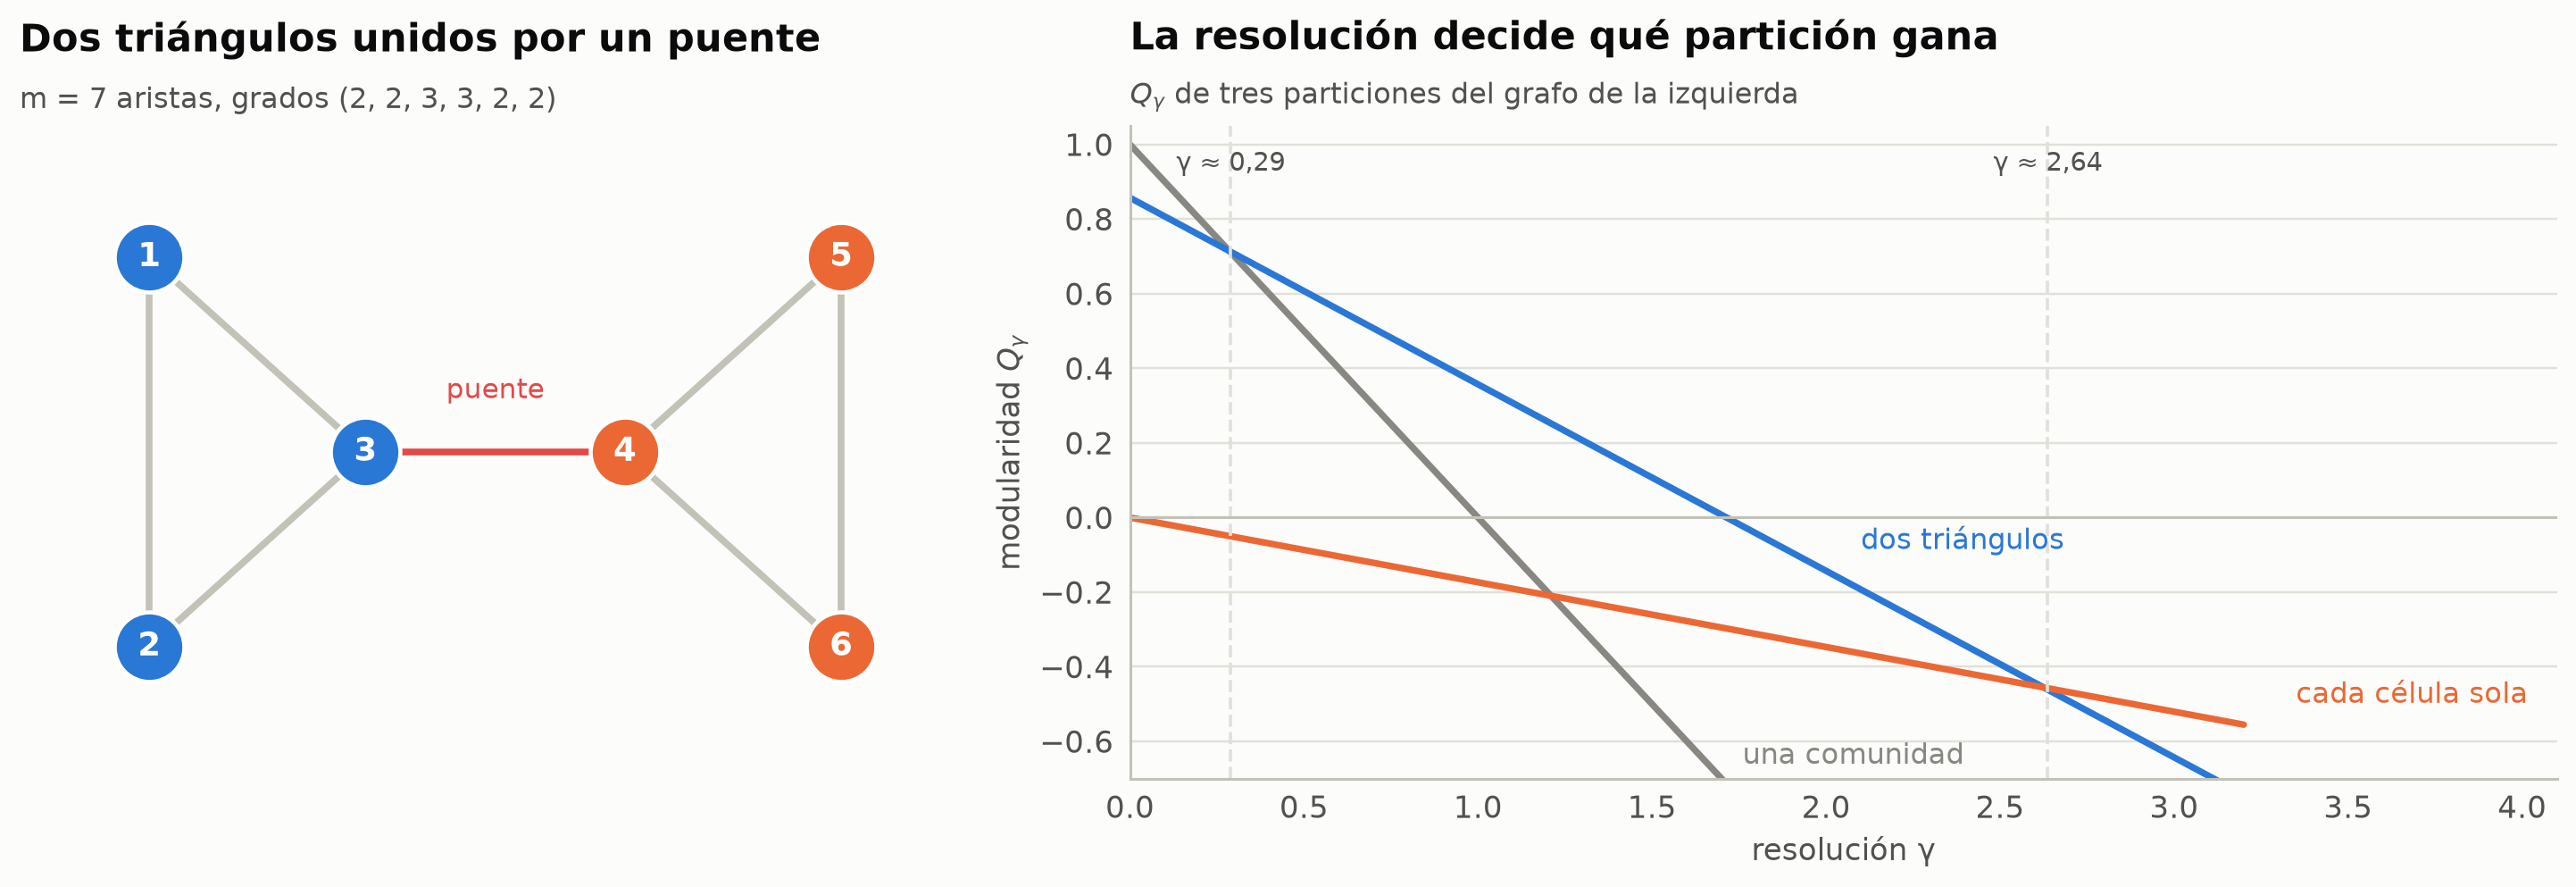

In [11]:
gam = np.linspace(0, 3.2, 200)
curves = {n: [modularity(tri, lab, g) for g in gam] for n, lab in parts.items()}
fig, axs = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1, 1.5]))
ax = axs[0]
pos = {0: (0, 0.9), 1: (0, -0.9), 2: (1, 0), 3: (2.2, 0), 4: (3.2, 0.9), 5: (3.2, -0.9)}
for i, j in zip(*np.triu(tri).nonzero()):
    ax.plot(*np.array([pos[i], pos[j]]).T, color=ec.RED if (i, j) == (2, 3) else ec.BASELINE, lw=2.5, zorder=1)
for i, (x, y) in pos.items():
    ax.scatter(x, y, s=650, color=ec.BLUE if i < 3 else ec.ORANGE, zorder=2, edgecolor="white", lw=1.5)
    ax.text(x, y, str(i + 1), color="white", ha="center", va="center", fontweight="bold", fontsize=12, zorder=3)
ax.text(1.6, 0.25, "puente", color=ec.RED, ha="center", fontsize=10)
ax.set_xlim(-0.6, 3.8); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal"); ax.axis("off")
ec.title(ax, "Dos triángulos unidos por un puente", "m = 7 aristas, grados (2, 2, 3, 3, 2, 2)")
ax = axs[1]
for (name, ys), col, gx in zip(curves.items(), [ec.MUTED, ec.BLUE, ec.ORANGE], [0.62, 2.0, 3.25]):
    ax.plot(gam, ys, color=col, lw=2.4)
    yx = np.interp(gx, gam, ys)
    if gx < 1:                                     # la recta gris sale por abajo: etiqueta junto a su extremo
        ax.text(1.76, -0.64, name, color=col, va="center", ha="left", fontsize=10.5)
    else:
        ax.text(gx + 0.1, yx + 0.04, name, color=col, va="bottom", ha="left", fontsize=10.5)
best = np.argmax(np.array(list(curves.values())), axis=0)
for g0 in gam[1:][np.diff(best) != 0]:
    ax.axvline(g0, color=ec.GRID, lw=1.2, ls="--")
    ax.text(g0, 0.93, f"γ ≈ {g0:.2f}".replace(".", ","), ha="center", fontsize=9.5, color=ec.INK_2)
ax.axhline(0, color=ec.BASELINE, lw=1)
ax.set_xlabel("resolución γ"); ax.set_ylabel("modularidad $Q_\\gamma$"); ax.set_xlim(0, 4.1); ax.set_ylim(-0.7, 1.05)
ec.title(ax, "La resolución decide qué partición gana", "$Q_\\gamma$ de tres particiones del grafo de la izquierda")
plt.show()

> 🔎 **Qué observamos.** Cada partición es una **recta** en $\gamma$: su ordenada en el origen es la fracción de aristas
> internas y su pendiente, $-\sum_c(d_c/2m)^2$. Para $\gamma<0{,}29$ gana la comunidad única (el término nulo apenas
> pesa); entre $0{,}29$ y $2{,}6$ ganan los dos triángulos; por encima, cada célula sola. Por eso $\gamma$ elige la
> **escala** de la respuesta: al aumentarlo, sólo sobreviven comunidades muy densas y el óptimo tiene más grupos y más
> pequeños. Con $\gamma=2$ los dos triángulos dan $Q_2=-0{,}143$ (negativo), pero siguen siendo la **mejor** opción:
> lo que importa es comparar particiones con el mismo $\gamma$, no el signo.

> ✅ **Compruebe su comprensión.** Calcule a mano $Q_1$ de la partición $\{1,2\}$, $\{3,4\}$, $\{5,6\}$ del grafo de
> los triángulos. ¿Es mejor o peor que la de los dos triángulos? (Respuesta: $3\cdot\tfrac17-[(4/14)^2+(6/14)^2+(4/14)^2]=0{,}429-0{,}347=0{,}082$.)

## 5. El algoritmo de Louvain y su corrección, Leiden

### 5.1 Un problema difícil y una heurística voraz

Maximizar $Q$ exactamente es NP-difícil: el número de particiones posibles de 3 000 células es astronómico. Blondel y
colaboradores (2008) propusieron una heurística voraz de dos fases, llamada **de Louvain** por la universidad de sus
autores, que escala a millones de nodos:

1. **Movimiento local.** Cada nodo empieza en su propia comunidad. Se recorren los nodos y cada uno se mueve a la
   comunidad vecina que más aumenta $Q$, si alguna lo aumenta. Se repite hasta que ningún movimiento mejora.
2. **Agregación.** Cada comunidad se contrae en un **supernodo**, con aristas cuyos pesos suman los de las originales,
   y se vuelve a la fase 1 sobre el grafo reducido.

La eficiencia proviene de que la ganancia de mover un nodo aislado $i$ a una comunidad $C$ se calcula con información
**local**:

$$
\Delta Q = \frac{k_{i,C}}{m}-\gamma\,\frac{\Sigma_C\,k_i}{2m^2}.
$$

| Símbolo | Significado |
|---|---|
| $k_{i,C}$ | suma de los pesos de las aristas entre $i$ y los nodos de $C$ |
| $\Sigma_C$ | suma de los grados de los nodos de $C$ |
| $k_i$, $m$, $\gamma$ | grado de $i$, número de aristas y resolución, como antes |

**¿De dónde sale?** Restamos a la modularidad de $C\cup\{i\}$ la de $C$ y la de $\{i\}$ por separado. El término de
aristas crece en $2k_{i,C}/2m$ (las aristas nuevas se cuentan dos veces en la suma sobre $i,j$) y el término nulo en
$\gamma\,[(\Sigma_C+k_i)^2-\Sigma_C^2-k_i^2]/(2m)^2=2\gamma\,\Sigma_Ck_i/(2m)^2$. Sólo intervienen las aristas de $i$ y un
total por comunidad: mover un nodo cuesta $O(k_i)$ operaciones, no $O(n^2)$.

### 5.2 Resuelto a mano

En el grafo de los triángulos ($m=7$, $\gamma=1$), suponga que 1 y 2 ya forman la comunidad $C=\{1,2\}$
($\Sigma_C=4$) y que el nodo 3 ($k_3=3$) está solo. Tiene dos opciones:

* Unirse a $\{1,2\}$: $k_{3,C}=2$ (aristas 3–1 y 3–2), $\Delta Q=\tfrac{2}{7}-\tfrac{4\cdot3}{2\cdot49}=0{,}2857-0{,}1224=+0{,}163$.
* Unirse a $\{4\}$ ($\Sigma=3$): $k_{3,C}=1$, $\Delta Q=\tfrac{1}{7}-\tfrac{3\cdot3}{2\cdot49}=0{,}1429-0{,}0918=+0{,}051$.

Ambas mejoran $Q$, pero el nodo 3 elige la mayor: se une a $\{1,2\}$.

In [12]:
def delta_q(k_iC, Sigma_C, k_i, m, gamma=1.0):
    return k_iC / m - gamma * Sigma_C * k_i / (2 * m * m)

print(f"3 → {{1,2}}:  ΔQ = {delta_q(2, 4, 3, 7):+.4f}")
print(f"3 → {{4}}:    ΔQ = {delta_q(1, 3, 3, 7):+.4f}")
# Comprobación directa con la definición de Q
before = modularity(tri, np.array([0, 0, 2, 3, 4, 5]))
after = modularity(tri, np.array([0, 0, 0, 3, 4, 5]))
print(f"Q antes = {before:.4f}, Q después = {after:.4f}, diferencia = {after - before:+.4f}")

3 → {1,2}:  ΔQ = +0.1633
3 → {4}:    ΔQ = +0.0510
Q antes = -0.0714, Q después = 0.0918, diferencia = +0.1633


### 5.3 Louvain desde cero

Programamos las dos fases tal como las describe el libro. El movimiento local recorre los nodos en orden aleatorio
(con semilla fija, para que el resultado sea reproducible), saca el nodo de su comunidad, calcula $\Delta Q$ para cada
comunidad vecina y lo coloca en la mejor. La agregación es una multiplicación de matrices: si $P$ es la matriz
nodo × comunidad (1 si el nodo pertenece a la comunidad), el grafo de supernodos es $P^{\top}AP$, cuyos elementos
diagonales guardan el peso de las aristas internas.

In [13]:
def local_moving(A, gamma=1.0, seed=0, max_pass=20, record=False):
    """Fase 1 de Louvain: mover nodos a la comunidad vecina con mayor ΔQ hasta que nada mejore."""
    A = sparse.csr_matrix(A)
    n = A.shape[0]
    k = np.asarray(A.sum(1)).ravel()
    m = k.sum() / 2
    comm = np.arange(n)                    # cada nodo en su propia comunidad
    Sigma = k.copy()                       # Σ_C: suma de grados de cada comunidad
    rng = np.random.default_rng(seed)
    moves = []
    for _ in range(max_pass):
        improved = False
        for i in rng.permutation(n):
            nbr, w = A.indices[A.indptr[i]:A.indptr[i + 1]], A.data[A.indptr[i]:A.indptr[i + 1]]
            ci = comm[i]
            Sigma[ci] -= k[i]              # sacamos a i de su comunidad
            k_iC = {}
            for j, wij in zip(nbr, w):
                if j != i:
                    k_iC[comm[j]] = k_iC.get(comm[j], 0.0) + wij
            best = ci
            best_gain = delta_q(k_iC.get(ci, 0.0), Sigma[ci], k[i], m, gamma)
            for c, kic in k_iC.items():
                gain = delta_q(kic, Sigma[c], k[i], m, gamma)
                if gain > best_gain + 1e-12:
                    best, best_gain = c, gain
            Sigma[best] += k[i]
            if best != ci:
                comm[i] = best
                improved = True
                if record:
                    moves.append((i, best))
        if not improved:
            break
    labels = np.unique(comm, return_inverse=True)[1]
    return (labels, moves) if record else labels

def aggregate(A, labels):
    """Fase 2: contraer cada comunidad en un supernodo (P^T A P)."""
    P = sparse.csr_matrix((np.ones(len(labels)), (np.arange(len(labels)), labels)))
    return (P.T @ A @ P).tocsr()

def relabel_by_size(labels):
    """Numera las comunidades de mayor a menor (0 = la más grande), como Scanpy y el libro."""
    order = np.argsort(-np.bincount(labels), kind="stable")
    return np.argsort(order)[labels]

def louvain(A, gamma=1.0, seed=0):
    """Louvain completo: movimiento local + agregación hasta que no cambie nada."""
    labels = np.arange(A.shape[0])
    Ag = sparse.csr_matrix(A)
    n_levels = 0
    while True:
        comm = local_moving(Ag, gamma, seed)
        if comm.max() + 1 == Ag.shape[0]:          # nadie se movió: fin
            break
        labels = comm[labels]
        Ag = aggregate(Ag, comm)
        n_levels += 1
    return relabel_by_size(labels), n_levels

t0 = time.time()
lab_ours, n_lev = louvain(A_sim, gamma=1.0)
print(f"Louvain (nuestro): {lab_ours.max() + 1} comunidades en {n_lev} niveles, "
      f"Q = {modularity(A_sim, lab_ours):.4f}, ARI frente a la verdad = {adjusted_rand_score(T_true, lab_ours):.3f}"
      f"   ({time.time() - t0:.1f} s)")
print("Tamaños:", np.bincount(lab_ours))

Louvain (nuestro): 7 comunidades en 2 niveles, Q = 0.7234, ARI frente a la verdad = 0.894   (0.3 s)
Tamaños: [824 583 511 444 323 240 160]


> 🔎 **Qué observamos.** Nuestro Louvain de 60 líneas encuentra **7 comunidades** con $Q\approx0{,}723$ y un índice de
> Rand ajustado (ARI) cercano a 0,89 frente a los tipos simulados: las mismas cifras que el libro obtiene con la
> implementación de `networkx`. El ARI mide la concordancia entre dos particiones: 1 si son idénticas, 0 si coinciden
> lo que se esperaría por azar. Bastaron dos niveles: el primero agrupa las células en unas decenas de comunidades
> pequeñas; el segundo fusiona esos supernodos en los siete tipos.

### 5.4 Louvain en cámara lenta

La animación siguiente sigue el movimiento local sobre un grafo pequeño: 60 células simuladas de tres tipos
emparentados (T CD4, T CD8 y NK) con $k=6$. Al principio cada célula es su propia comunidad (60 colores); en cada
cuadro, varias células se mudan a la comunidad vecina que más aumenta $Q$, y el título muestra cómo sube la
modularidad. Al final de la fase 1, la agregación convierte cada comunidad en un supernodo.

In [14]:
rng = np.random.default_rng(7)
toy_idx = np.concatenate([rng.choice(np.where(T_true == t)[0], 20, replace=False) for t in (0, 1, 2)])
A_toy, _ = knn_graph(Z30[toy_idx], k=6)
lab_mov, moves = local_moving(A_toy, gamma=1.0, seed=3, record=True)
lab_2 = local_moving(aggregate(A_toy, lab_mov), gamma=1.0, seed=3)[lab_mov]
pos_toy = nx.spring_layout(nx.from_scipy_sparse_array(A_toy), seed=4, k=0.35)
XY = np.array([pos_toy[i] for i in range(len(toy_idx))])
print(f"Movimientos en la fase 1: {len(moves)} → {lab_mov.max() + 1} comunidades; "
      f"tras agregar: {lab_2.max() + 1} comunidades")
print("ARI frente a los tres tipos verdaderos:", round(adjusted_rand_score(T_true[toy_idx], lab_2), 3))

Movimientos en la fase 1: 84 → 5 comunidades; tras agregar: 3 comunidades
ARI frente a los tres tipos verdaderos: 0.814


![Vista previa: fase de movimiento local de Louvain sobre 60 células (T CD4, T CD8 y NK); cada célula se muda a la comunidad vecina que más aumenta la modularidad Q, y al final la agregación deja tres comunidades.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.3_louvain_movimientos.gif)

*Vista previa: fase de movimiento local de Louvain sobre 60 células (T CD4, T CD8 y NK); cada célula se muda a la comunidad vecina que más aumenta la modularidad Q, y al final la agregación deja tres comunidades.*

In [15]:
PAL60 = [plt.cm.tab20(i) for i in range(20)] + [plt.cm.tab20b(i) for i in range(20)] + [plt.cm.tab20c(i) for i in range(20)]
MARK = {0: "o", 1: "s", 2: "^"}                      # forma = tipo verdadero (T CD4, T CD8, NK)
Ct = sparse.triu(A_toy).tocoo()
n_frames_moves = 36
chunks = np.array_split(np.arange(len(moves)), n_frames_moves)
states, qs = [], []
state = np.arange(len(toy_idx))
states.append(state.copy()); qs.append(modularity(A_toy, state))
for ch in chunks:
    for mv in ch:
        i, c = moves[mv]
        state[i] = c
    states.append(state.copy()); qs.append(modularity(A_toy, state))
final_q = modularity(A_toy, lab_2)
n_hold = 8

fig, ax = plt.subplots(figsize=(8.6, 7.4))
fig.set_layout_engine(None)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.84)
ax.add_collection(LineCollection(np.stack([XY[Ct.row], XY[Ct.col]], 1), colors=ec.BASELINE, lw=0.9, zorder=1))
tt_true = T_true[toy_idx]
scats = [ax.scatter(XY[tt_true == t, 0], XY[tt_true == t, 1], s=150, marker=MARK[t], zorder=2,
                    edgecolor="white", lw=0.8) for t in (0, 1, 2)]
ax.set_xlim(XY[:, 0].min() - 0.12, XY[:, 0].max() + 0.12); ax.set_ylim(XY[:, 1].min() - 0.12, XY[:, 1].max() + 0.2)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.legend(handles=[Line2D([], [], marker=MARK[t], ls="", color=ec.MUTED, ms=9, label=TYPES[t]) for t in (0, 1, 2)],
           loc="upper left", bbox_to_anchor=(0.02, 0.895), ncol=3, frameon=False, title=None, fontsize=10.5)
fig.text(0.40, 0.872, "(forma = tipo verdadero)", fontsize=10.5, color=ec.INK_2)
ttl = fig.text(0.02, 0.965, "", fontsize=14, fontweight="bold", va="top")
sub = fig.text(0.02, 0.918, "", fontsize=11, color=ec.INK_2, va="top")

def update(f):
    if f < len(states):
        st = states[f]
        cols = [PAL60[c % 60] for c in st]
        ttl.set_text(f"Fase 1 · movimiento local: Q = {qs[f]:.3f}".replace(".", ","))
        sub.set_text(f"{len(np.unique(st))} comunidades · movimientos realizados: "
                     f"{0 if f == 0 else chunks[f - 1][-1] + 1} de {len(moves)}")
    else:
        cols = [ec.CATEGORICAL[c % 8] for c in lab_2]
        ttl.set_text(f"Fase 2 · agregación: Q = {final_q:.3f}".replace(".", ","))
        sub.set_text(f"{lab_2.max() + 1} comunidades (supernodos) · ARI frente a los tipos = "
                     f"{adjusted_rand_score(tt_true, lab_2):.2f}".replace(".", ","))
    cols = np.array(cols, dtype=object)
    for t, scat in zip((0, 1, 2), scats):
        scat.set_facecolor(list(cols[tt_true == t]))
    return scats

ec.animate(fig, update, frames=len(states) + n_hold, interval=260, name="12.3_louvain_movimientos")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En los primeros cuadros la modularidad sube deprisa: cada célula se une a una vecina y se
> forman decenas de parejas y tríos, que después se van fusionando. Luego los cambios se hacen raros y $Q$ se estanca:
> el movimiento local ha encontrado un **óptimo local** con algunas comunidades más de las necesarias, porque mover
> una célula sola ya no compensa. La **agregación** rompe ese estancamiento: al tratar cada comunidad como un
> supernodo, el algoritmo puede mover grupos enteros de una vez y fusionar los trozos del mismo tipo. Las formas (tipo verdadero) permiten juzgar el resultado: los errores se concentran en la frontera
> entre T CD8 y NK, dos poblaciones que comparten el programa citotóxico (*NKG7*, *GZMK*, *PRF1*).

### 5.5 El defecto de Louvain y su corrección: Leiden

Traag, Waltman y van Eck (2019) mostraron que Louvain tiene un defecto grave: al mover un nodo que servía de **puente**
dentro de una comunidad, esta puede quedar internamente **desconectada** (dos trozos sin ninguna arista entre ellos
que comparten etiqueta), y las fases posteriores nunca lo corrigen, porque a partir de ahí la comunidad viaja como un
único supernodo. El algoritmo de **Leiden** añade una fase de **refinamiento** entre el movimiento y la agregación:
dentro de cada comunidad, los nodos se reagrupan en subcomunidades **bien conectadas**, y es sobre esas subcomunidades
sobre las que se agrega. Con ello Leiden garantiza comunidades conectadas y, además, converge más rápido. Es el método
recomendado en Scanpy (`sc.tl.leiden`) y está disponible como opción en Seurat.

| | Louvain (2008) | Leiden (2019) |
|---|---|---|
| Fases | movimiento local → agregación | movimiento local (rápido) → **refinamiento** → agregación |
| ¿Comunidades conectadas? | no garantizado | sí (y localmente óptimas tras iterar) |
| Velocidad | rápida | más rápida (sólo revisita los nodos cuyos vecinos cambiaron) |
| En Scanpy | `sc.tl.louvain` (heredado) | `sc.tl.leiden` (recomendado) |

Comparemos en la simulación nuestro Louvain, el de `networkx` (el que usa el libro) y el Leiden de Scanpy, y contemos
cuántas comunidades salen desconectadas.

In [16]:
def n_disconnected(A, labels):
    """Número de comunidades formadas por más de un trozo conexo."""
    bad = 0
    for c in np.unique(labels):
        s = np.where(labels == c)[0]
        if len(s) > 1 and sparse.csgraph.connected_components(A[s][:, s], directed=False)[0] > 1:
            bad += 1
    return bad

G_sim = nx.from_scipy_sparse_array(A_sim)
def nx_louvain(G, gamma, seed=0):
    comms = sorted(nx.community.louvain_communities(G, resolution=gamma, seed=seed), key=len, reverse=True)
    lab = np.zeros(G.number_of_nodes(), int)
    for c, s in enumerate(comms):
        lab[list(s)] = c
    return lab

ad_sim = sc.AnnData(np.zeros((len(Z30), 1), dtype=np.float32))
res_rows = []
for name, fun in [("Louvain (nuestro)", lambda: louvain(A_sim, 1.0)[0]),
                  ("Louvain (networkx)", lambda: nx_louvain(G_sim, 1.0)),
                  ("Leiden (Scanpy)", lambda: (sc.tl.leiden(ad_sim, adjacency=A_sim, resolution=1.0, flavor="igraph",
                                                            n_iterations=2, random_state=0),
                                               ad_sim.obs["leiden"].astype(int).values)[1])]:
    t0 = time.time(); lab = fun(); dt = time.time() - t0
    res_rows.append((name, lab.max() + 1, round(modularity(A_sim, lab), 4),
                     round(adjusted_rand_score(T_true, lab), 3), n_disconnected(A_sim, lab), round(dt, 2)))
    if name.startswith("Leiden"):
        lab_leiden_sim = lab
pd.DataFrame(res_rows, columns=["método", "comunidades", "Q (γ=1)", "ARI vs verdad", "desconectadas", "segundos"])

,método,comunidades,Q (γ=1),ARI vs verdad,desconectadas,segundos
0,Louvain (nuestro),7,0.7234,0.894,0,0.34
1,Louvain (networkx),7,0.7233,0.892,0,0.16
2,Leiden (Scanpy),7,0.7241,0.885,0,0.03


> 🔎 **Qué observamos.** Los tres métodos llegan a particiones casi idénticas (7 comunidades, $Q\approx0{,}72$,
> ARI $\approx0{,}89$) y ninguna comunidad desconectada. Como dice el libro, en esta simulación relativamente sencilla
> Louvain no produce comunidades rotas; Traag *et al.* sí las encontraron al aplicarlo a redes reales grandes, y en
> algunas hasta un 25 % de las comunidades estaban mal conectadas. La recomendación práctica no cambia: use Leiden. En
> el ejercicio 2 fabricará un caso en el que el movimiento local deja una comunidad desconectada.

Ahora el caso real: agrupamos las 2 638 células de PBMC 3k con Leiden ($\gamma=1$) sobre el grafo de Scanpy y
comparamos con nuestro Louvain aplicado al **mismo** grafo ponderado.

In [17]:
sc.tl.umap(adata, random_state=0)
t0 = time.time()
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0, key_added="leiden")
lab_leiden = adata.obs["leiden"].astype(int).values
t_leiden = time.time() - t0
t0 = time.time(); lab_lv_pb, _ = louvain(adata.obsp["connectivities"], 1.0); t_lv = time.time() - t0
print(f"Leiden (Scanpy): {lab_leiden.max() + 1} grupos en {t_leiden:.2f} s · tamaños {np.bincount(lab_leiden).tolist()}")
print(f"Louvain (nuestro): {lab_lv_pb.max() + 1} grupos en {t_lv:.2f} s")
print(f"ARI Leiden vs Louvain: {adjusted_rand_score(lab_leiden, lab_lv_pb):.3f}  ·  "
      f"Q Leiden = {modularity(adata.obsp['connectivities'], lab_leiden):.3f}, "
      f"Q Louvain = {modularity(adata.obsp['connectivities'], lab_lv_pb):.3f}")
print("Comunidades desconectadas → Leiden:", n_disconnected(adata.obsp["connectivities"], lab_leiden),
      "| Louvain:", n_disconnected(adata.obsp["connectivities"], lab_lv_pb))

Leiden (Scanpy): 9 grupos en 0.03 s · tamaños [627, 526, 342, 485, 152, 153, 302, 36, 15]
Louvain (nuestro): 9 grupos en 0.59 s
ARI Leiden vs Louvain: 0.790  ·  Q Leiden = 0.711, Q Louvain = 0.696
Comunidades desconectadas → Leiden: 0 | Louvain: 0


> 🔎 **Qué observamos.** En nuestra ejecución, Leiden encuentra 9 grupos en PBMC 3k, los mismos que describe el
> tutorial clásico de Seurat. Nuestro Louvain, aplicado al mismo grafo, coincide en buena medida (ARI ≈ 0,8) con una
> modularidad algo menor. Las diferencias se concentran en las fronteras difusas (por ejemplo, entre linfocitos T CD4
> vírgenes y de memoria), donde varias particiones tienen casi la misma $Q$: el paisaje de la modularidad es **plano**
> cerca del óptimo, y dos algoritmos (o dos semillas) pueden detenerse en picos distintos igual de altos.

> ✅ **Compruebe su comprensión.** (1) ¿Por qué la fase de movimiento local, por sí sola, deja muchas comunidades
> pequeñas? (2) Explique con sus palabras cómo puede quedar desconectada una comunidad de Louvain y por qué la
> agregación posterior no lo arregla.

## 6. ¿Cuántos *clusters*? La resolución

No existe un número «correcto» de grupos. Los tipos celulares forman una **jerarquía** (linfocitos $\supset$
linfocitos T $\supset$ T CD4 $\supset$ T CD4 vírgenes), igual que en un inmunofenotipo clínico se puede informar
«linfocitos» o bajar hasta «T CD4 de memoria central». El parámetro $\gamma$ elige a qué nivel cortar esa jerarquía.

Reproducimos el barrido del libro: Louvain (`networkx`, semilla 0) sobre el grafo kNN de la simulación, con $\gamma$
entre 0,05 y 3. Para cada resolución medimos el número de comunidades, la modularidad **evaluada con $\gamma=1$** (para
poder comparar particiones) y el ARI frente a los siete tipos simulados.

> 🤔 **Antes de ejecutar, prediga.** ¿Será el ARI máximo exactamente en $\gamma=1$? ¿Qué forma tendrá la curva del
> número de *clusters* frente a $\gamma$: una recta, una escalera, una curva suave?

In [18]:
RES = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0]
BOOK = {0.05: (2, 0.425, 0.276), 0.1: (2, 0.425, 0.276), 0.2: (4, 0.584, 0.495), 0.3: (5, 0.653, 0.644),
        0.5: (6, 0.712, 0.808), 0.7: (7, 0.724, 0.887), 1.0: (7, 0.723, 0.892), 1.3: (7, 0.722, 0.881),
        1.6: (8, 0.705, 0.759), 2.0: (9, 0.699, 0.735), 2.5: (12, 0.655, 0.601), 3.0: (13, 0.637, 0.555)}
t0 = time.time()
sweep, labs_sim = [], {}
for g in RES:
    lab = nx_louvain(G_sim, g, seed=0)
    labs_sim[g] = lab
    sweep.append(dict(res=g, k=lab.max() + 1, Q1=round(modularity(A_sim, lab), 3),
                      ARI=round(adjusted_rand_score(T_true, lab), 3), k_libro=BOOK[g][0],
                      Q1_libro=BOOK[g][1], ARI_libro=BOOK[g][2], desconectadas=n_disconnected(A_sim, lab)))
sweep = pd.DataFrame(sweep)
n_diff = int((sweep.k.ne(sweep.k_libro) | sweep.Q1.ne(sweep.Q1_libro) | sweep.ARI.ne(sweep.ARI_libro)).sum())
print(f"networkx {nx.__version__}: barrido en {time.time() - t0:.1f} s · "
      + ("coincide cifra por cifra con el libro" if n_diff == 0 else
         f"difiere del libro en {n_diff} de {len(RES)} resoluciones. Con networkx 3.5 el barrido reproduce el libro; versiones "
         "posteriores (p. ej., 3.7) cambiaron detalles internos de Louvain y, con la misma semilla, dan particiones "
         "algo distintas: otro número de clusters en γ altas y un ARI que cambia en la segunda o tercera cifra. "
         "Instale networkx<3.6 para reproducirlo."))
sweep

networkx 3.5: barrido en 2.6 s · coincide cifra por cifra con el libro


,res,k,Q1,ARI,k_libro,Q1_libro,ARI_libro,desconectadas
0,0.05,2,0.425,0.276,2,0.425,0.276,0
1,0.10,2,0.425,0.276,2,0.425,0.276,0
2,0.20,4,0.584,0.495,4,0.584,0.495,0
3,0.30,5,0.653,0.644,5,0.653,0.644,0
4,0.50,6,0.712,0.808,6,0.712,0.808,0
5,0.70,7,0.724,0.887,7,0.724,0.887,0
6,1.00,7,0.723,0.892,7,0.723,0.892,0
7,1.30,7,0.722,0.881,7,0.722,0.881,0
8,1.60,8,0.705,0.759,8,0.705,0.759,0
9,2.00,9,0.699,0.735,9,0.699,0.735,0


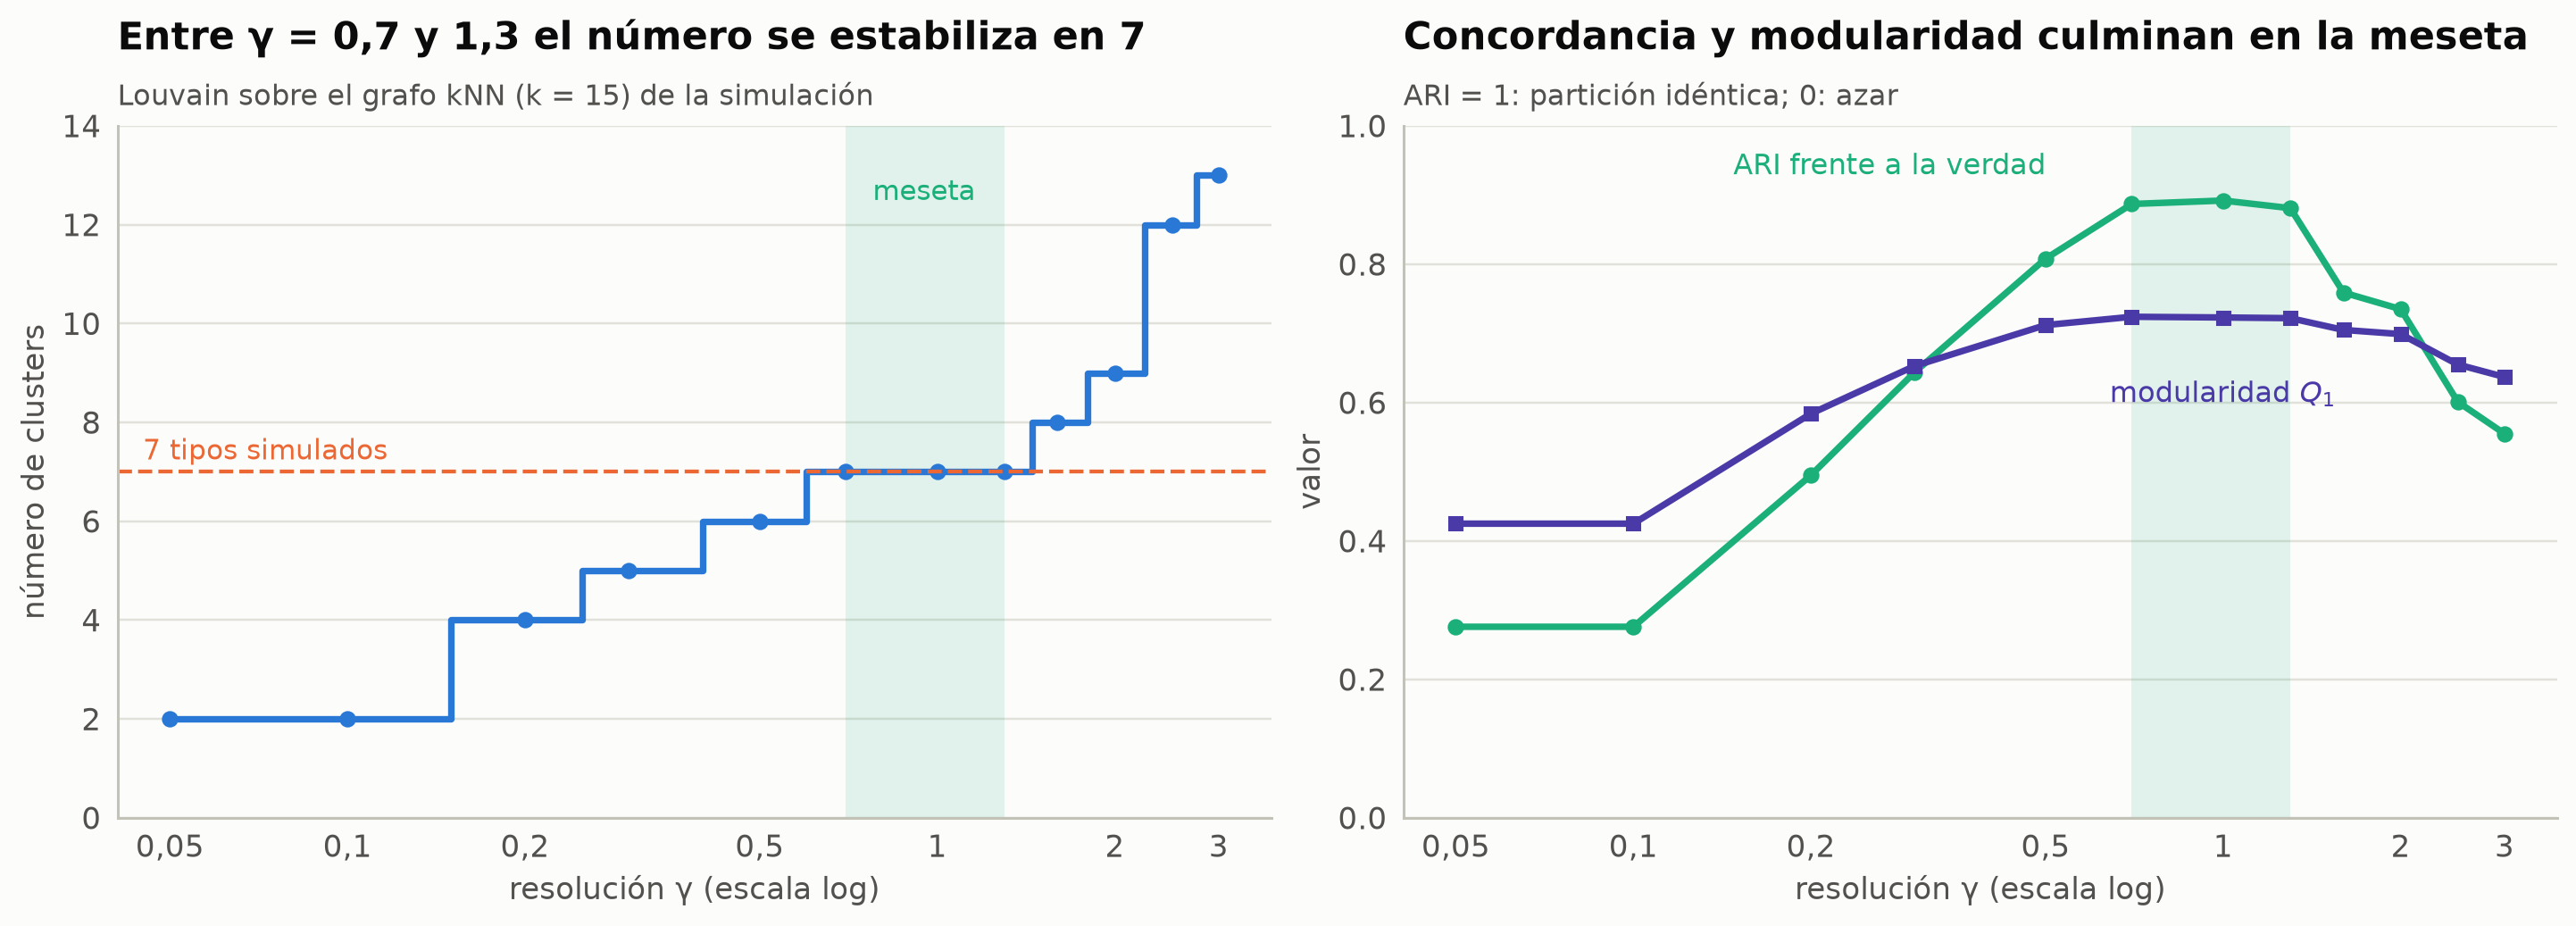

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axs[0]
ax.step(sweep.res, sweep.k, where="mid", color=ec.BLUE, lw=2.4)
ax.plot(sweep.res, sweep.k, "o", color=ec.BLUE, ms=5)
ax.axhline(7, color=ec.ORANGE, ls="--", lw=1.4)
ax.text(0.045, 7.25, "7 tipos simulados", color=ec.ORANGE, fontsize=10)
ax.axvspan(0.7, 1.3, color=ec.AQUA, alpha=0.12)
ax.text(0.95, 12.5, "meseta", color=ec.AQUA, ha="center", fontsize=10)
ax.set_ylabel("número de clusters"); ax.set_ylim(0, 14)
ec.title(ax, "Entre γ = 0,7 y 1,3 el número se estabiliza en 7", "Louvain sobre el grafo kNN (k = 15) de la simulación")
ax = axs[1]
ax.plot(sweep.res, sweep.ARI, "o-", color=ec.AQUA, lw=2.4, ms=5)
ax.plot(sweep.res, sweep.Q1, "s-", color=ec.VIOLET, lw=2.4, ms=4.5)
ax.text(0.5, 0.93, "ARI frente a la verdad", color=ec.AQUA, ha="right", fontsize=10.5)
ax.text(1.0, 0.60, "modularidad $Q_1$", color=ec.VIOLET, ha="center", fontsize=10.5)
ax.axvspan(0.7, 1.3, color=ec.AQUA, alpha=0.12)
ax.set_ylabel("valor"); ax.set_ylim(0, 1)
ec.title(ax, "Concordancia y modularidad culminan en la meseta", "ARI = 1: partición idéntica; 0: azar")
for ax in axs:
    ax.set_xscale("log"); ax.set_xlabel("resolución γ (escala log)")
    ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1, 2, 3]); ax.set_xticklabels(["0,05", "0,1", "0,2", "0,5", "1", "2", "3"])
    ax.minorticks_off()
plt.show()

> 🔎 **Qué observamos.** El número de grupos sube en **escalera**: pasa de 2 (mieloides y linfoides) a 13. Entre
> $\gamma=0{,}7$ y $1{,}3$ se queda en 7, el número de tipos simulados. Una **meseta** así es un indicio (no una
> prueba) de estructura robusta: la partición no depende del valor exacto del parámetro. El ARI y $Q_1$ alcanzan su
> máximo en esa meseta (ARI $\approx0{,}89$, $Q\approx0{,}72$ con $\gamma=1$). Con resoluciones altas los tipos se
> fragmentan en subgrupos, sobre todo el **estado continuo** de las células T CD4, que la simulación modela como un
> gradiente de virgen a memoria. Ninguna partición de Louvain resultó desconectada.

### 6.1 ¿Qué tan puros son los grupos?

Con $\gamma=1$, cruzamos cada comunidad con el tipo verdadero. La **pureza** de un grupo es la fracción de sus células
que pertenecen al tipo mayoritario.

           n tipo mayoritario  pureza
cluster                              
0        824            T CD4    97.6
1        582        Mono CD14    97.1
2        512            T CD8    88.3
3        444                B    98.0
4        321               NK    96.0
5        242      Mono FCGR3A    93.4
6        160               DC    96.2


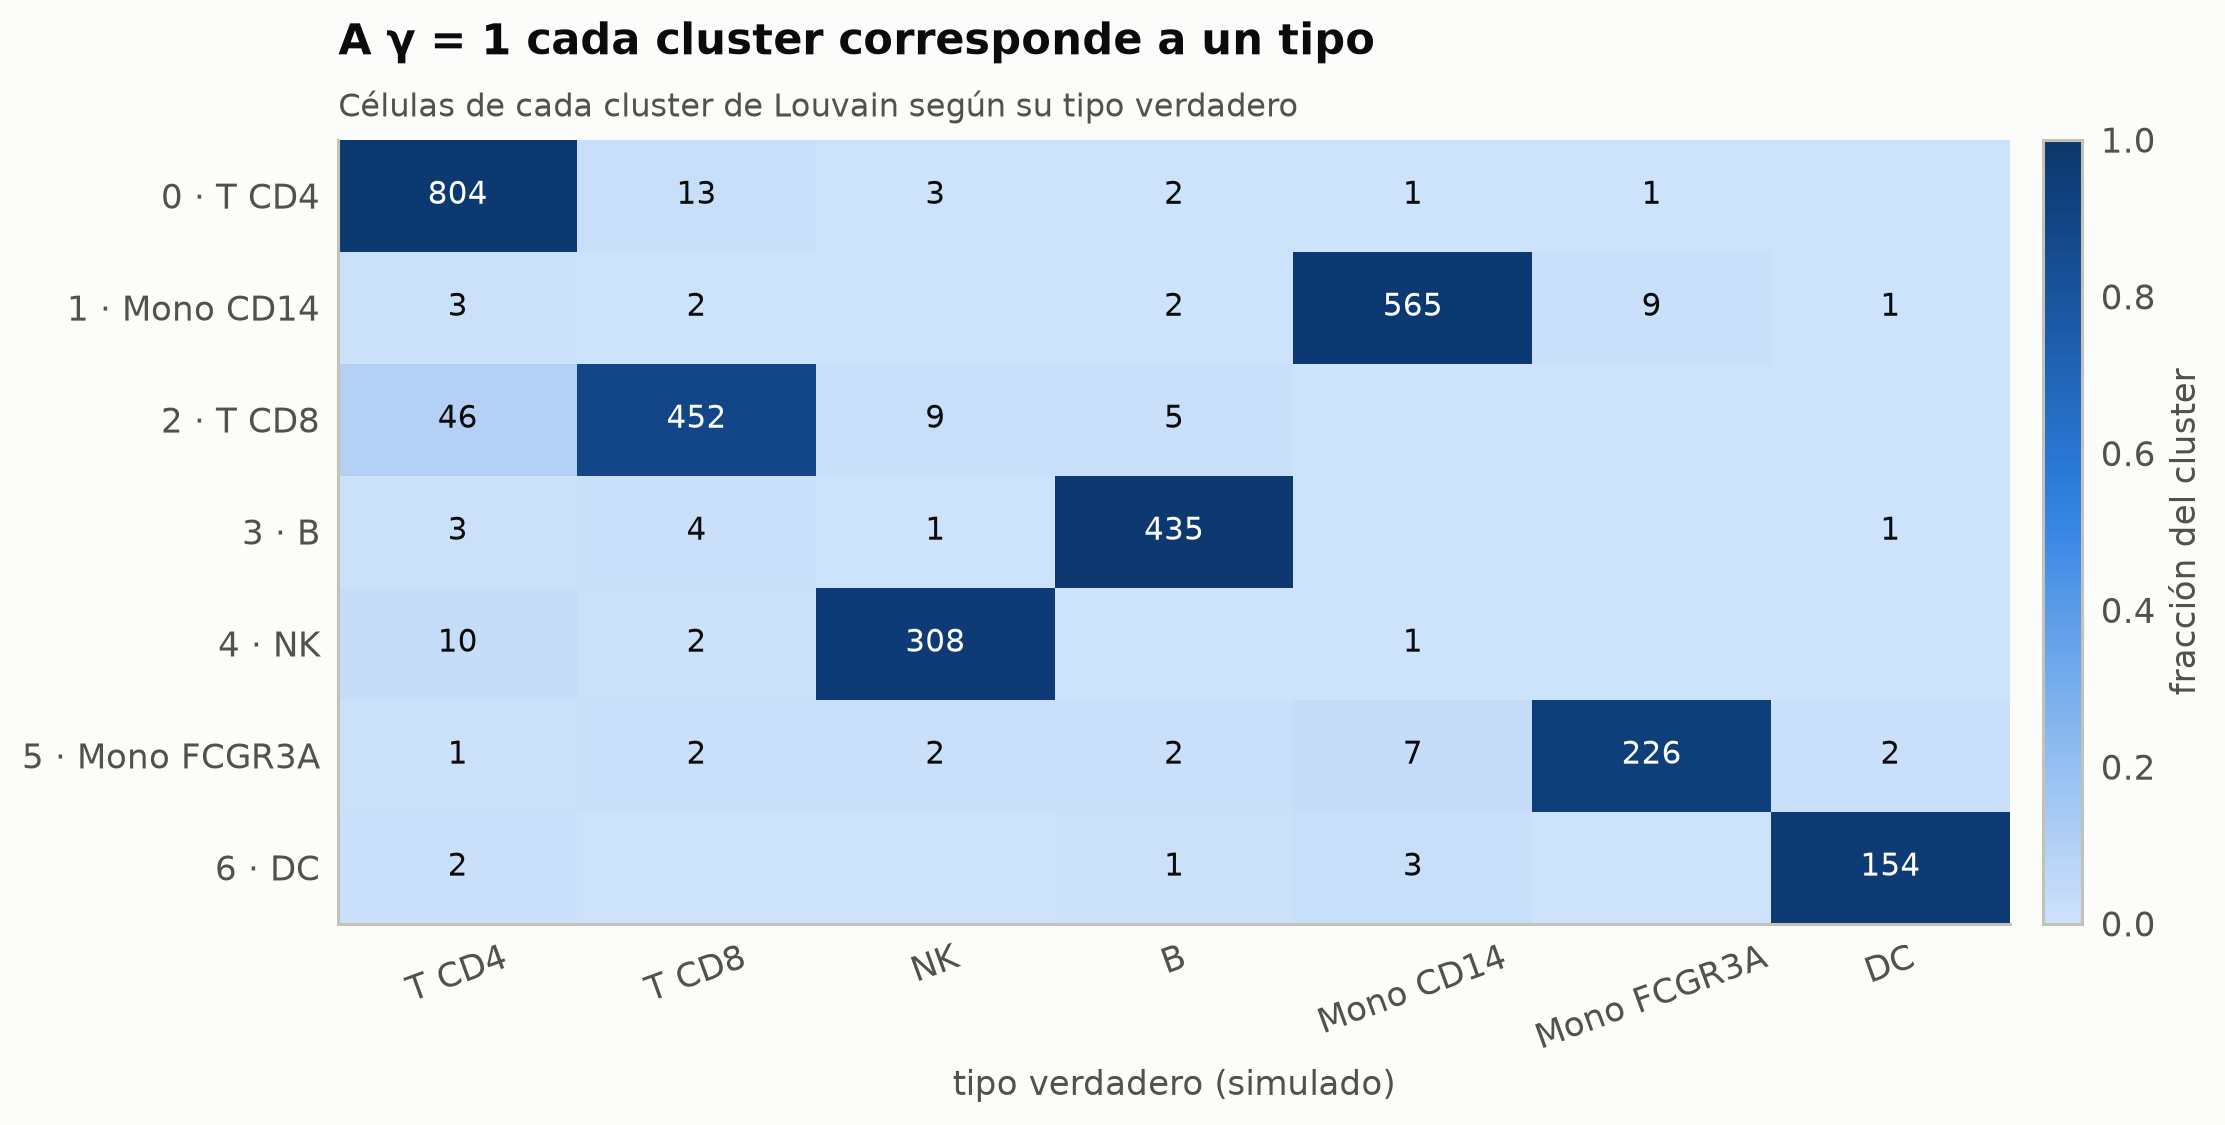

In [20]:
lab1 = labs_sim[1.0]
K1 = lab1.max() + 1
tab = pd.crosstab(pd.Series(lab1, name="cluster"), pd.Series([TYPES[t] for t in T_true], name="tipo verdadero"))
tab = tab[TYPES]
anot_sim = tab.idxmax(axis=1)
purity = tab.max(axis=1) / tab.sum(axis=1)
summary = pd.DataFrame({"n": tab.sum(axis=1), "tipo mayoritario": anot_sim, "pureza": (100 * purity).round(1)})
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
frac = tab.div(tab.sum(axis=1), axis=0).values
im = ax.imshow(frac, cmap=ec.CMAP_SEQ, vmin=0, vmax=1, aspect="auto")
for i in range(K1):
    for j in range(len(TYPES)):
        v = tab.values[i, j]
        if v:
            ax.text(j, i, f"{v}", ha="center", va="center", fontsize=10,
                    color="white" if frac[i, j] > 0.55 else ec.INK)
ax.set_xticks(range(len(TYPES)), TYPES, rotation=20)
ax.set_yticks(range(K1), [f"{c} · {anot_sim[c]}" for c in range(K1)])
ax.set_xlabel("tipo verdadero (simulado)"); ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cb.set_label("fracción del cluster")
ec.title(ax, "A γ = 1 cada cluster corresponde a un tipo", "Células de cada cluster de Louvain según su tipo verdadero")
plt.show()

> 🔎 **Qué observamos.** Las siete comunidades se corresponden una a una con los tipos simulados, con purezas entre el
> 88 % (T CD8, que recibe algunas células T CD4 y NK) y el 98 % (células B). Parte de los errores procede de los 135
> dobletes que el detector de la lección 12.1 no eliminó y de células situadas en la frontera entre poblaciones
> emparentadas, como T CD8 y NK.

Ahora la figura del grafo del libro: las aristas del kNN dibujadas sobre UMAP, en gris si unen células del mismo
*cluster* y en rojo si cruzan de uno a otro.

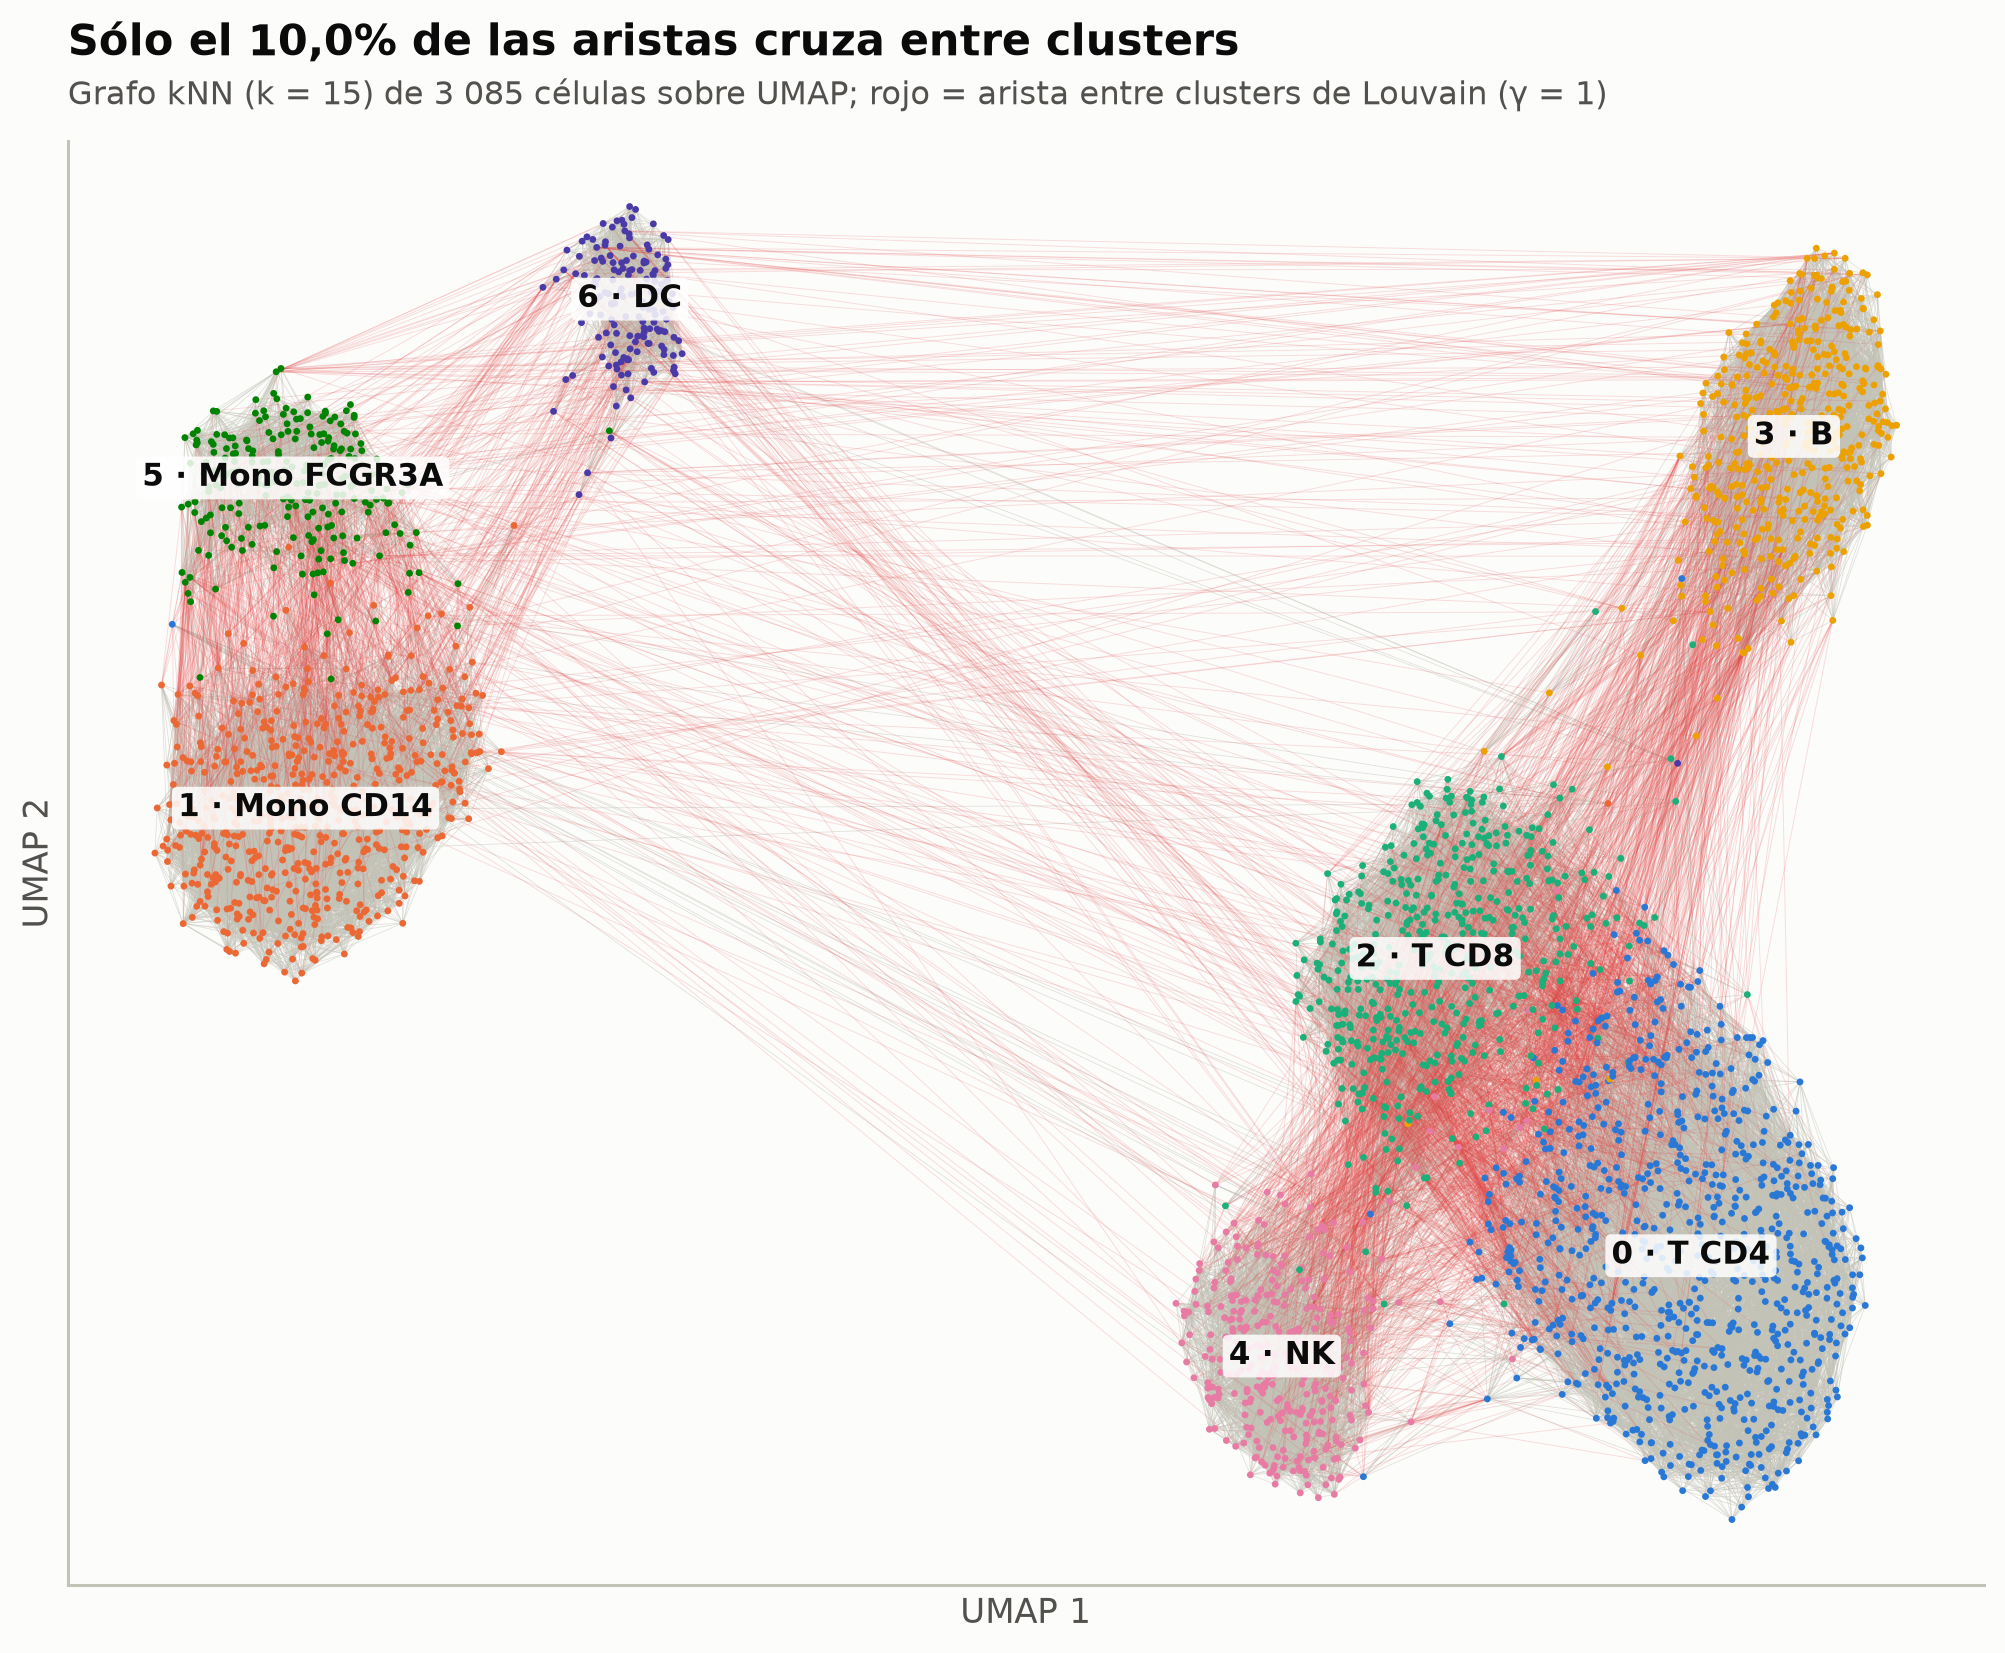

In [21]:
Ctu = sparse.triu(A_sim).tocoo()
same = lab1[Ctu.row] == lab1[Ctu.col]
segs = np.stack([U_sim[Ctu.row], U_sim[Ctu.col]], axis=1)
fig, ax = plt.subplots(figsize=(9, 7.4))
ax.add_collection(LineCollection(segs[same], colors=ec.BASELINE, linewidths=0.25, alpha=0.5, zorder=1))
ax.add_collection(LineCollection(segs[~same], colors=ec.RED, linewidths=0.3, alpha=0.18, zorder=1))
order = np.random.default_rng(0).permutation(len(lab1))
ax.scatter(U_sim[order, 0], U_sim[order, 1], s=5, lw=0, c=[ec.CATEGORICAL[c % 8] for c in lab1[order]], zorder=2)
for c in range(K1):
    mc = np.median(U_sim[lab1 == c], axis=0)
    ax.text(mc[0], mc[1], f"{c} · {anot_sim[c]}", fontsize=10, fontweight="bold", ha="center", va="center", zorder=3,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.grid(False)
ec.title(ax, f"Sólo el {np.mean(~same):.1%} de las aristas cruza entre clusters".replace(".", ","),
         "Grafo kNN (k = 15) de 3 085 células sobre UMAP; rojo = arista entre clusters de Louvain (γ = 1)")
plt.show()

> 🔎 **Qué observamos.** Sólo alrededor del **10 %** de las aristas cruza de un *cluster* a otro, y se concentran entre
> poblaciones emparentadas: linfocitos T CD4 (0), T CD8 (2) y NK (4), por un lado; monocitos CD14 (1), FCGR3A (5) y
> células dendríticas (6), por otro. Recuerde que el algoritmo sólo ve estas aristas, no las coordenadas del dibujo.

### 6.2 ¿Y $k$-medias?

Para cerrar la comparación del principio: $k$-medias con el número **correcto** de grupos ($K=7$, que en datos reales
no conoceríamos) sobre las mismas 30 PC.

In [22]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=7, n_init=10, random_state=0).fit_predict(Z30)
print(f"k-medias (K = 7): ARI = {adjusted_rand_score(T_true, km):.3f}   ·   "
      f"Louvain (γ = 1): ARI = {adjusted_rand_score(T_true, lab1):.3f}")
print("Tamaños k-medias:", np.bincount(km).tolist())
print("Tamaños verdaderos:", np.bincount(T_true).tolist())

k-medias (K = 7): ARI = 0.814   ·   Louvain (γ = 1): ARI = 0.892
Tamaños k-medias: [251, 710, 622, 567, 166, 324, 445]
Tamaños verdaderos: [869, 475, 323, 447, 577, 236, 158]


> 🔎 **Qué observamos.** Aun sabiendo que hay siete tipos, $k$-medias concuerda peor con la verdad que Louvain: tiende a
> partir los grupos grandes y alargados (T CD4, con su gradiente interno) y a fusionar los pequeños, porque minimiza la
> varianza dentro de cada grupo, que crece con el tamaño. El grafo no tiene ese sesgo.

> ⚠️ **Cuidado: un *cluster* no es un tipo celular.** Un *cluster* es la salida de un algoritmo con un parámetro
> arbitrario; un tipo celular es una hipótesis biológica. Al subir la resolución, Louvain y Leiden parten con gusto un
> gradiente continuo (un estado de activación, un ciclo celular) en trozos discretos, que después se «anotan» como
> subtipos. Antes de bautizar un grupo nuevo, compruebe que tiene marcadores propios que no son simplemente los extremos
> de un gradiente, que aparece en varias muestras y que no está definido por métricas de calidad (UMI totales, % de ARN
> mitocondrial) ni por genes de estrés de la disociación (*FOS*, *JUN*, proteínas de choque térmico).

### 6.3 La resolución en PBMC 3k

Repetimos el barrido con Leiden sobre los datos reales. Para que la animación sea legible, cada grupo nuevo hereda el
color del grupo de la resolución anterior con el que más células comparte: así se ve **quién se parte en quién**.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué población de la sangre se separará primero del resto al subir $\gamma$
> desde casi cero? ¿Y cuál se fragmentará antes al llegar a resoluciones altas?

In [23]:
RES_PB = [0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
labs_pb = {}
t0 = time.time()
for g in RES_PB:
    sc.tl.leiden(adata, resolution=g, flavor="igraph", n_iterations=2, random_state=0, key_added="tmp")
    labs_pb[g] = adata.obs["tmp"].astype(int).values
del adata.obs["tmp"]
print(f"Barrido Leiden en PBMC ({time.time() - t0:.1f} s):",
      {g: int(l.max() + 1) for g, l in labs_pb.items()})

PAL_EXT = ec.CATEGORICAL + ["#9ec5f4", "#f3b0ae", "#8fd9bd", "#f5d27a", "#f2bdd2", "#7fc47f", "#a39ad6",
                            "#104281", "#b8302f", "#0d6b4a", "#a36f00", "#a3446a", "#005200", "#2b2170",
                            "#52514e", "#c3c2b7", "#6da7ec", "#ec835a", "#3fcf98", "#fab219", "#d99ab8", "#898781"]

def match_colors(prev_lab, prev_col, lab):
    """Cada grupo nuevo hereda el color del grupo previo con el que más células comparte (el más grande primero)."""
    col, used = {}, set()
    for c in np.argsort(-np.bincount(lab)):
        overlap = np.bincount(prev_lab[lab == c], minlength=prev_lab.max() + 1)
        for p in np.argsort(-overlap):
            if overlap[p] > 0 and prev_col[p] not in used:
                col[c] = prev_col[p]; break
        else:
            free = [x for x in PAL_EXT if x not in used]
            fresh = [x for x in free if x not in prev_col.values()]
            col[c] = (fresh or free or [ec.MUTED])[0]
        used.add(col[c])
    return col

colmaps = {RES_PB[0]: {c: PAL_EXT[c] for c in range(labs_pb[RES_PB[0]].max() + 1)}}
for g0, g1 in zip(RES_PB[:-1], RES_PB[1:]):
    colmaps[g1] = match_colors(labs_pb[g0], colmaps[g0], labs_pb[g1])
U_pb = adata.obsm["X_umap"]

Barrido Leiden en PBMC (0.5 s): {0.02: 3, 0.05: 3, 0.1: 3, 0.15: 4, 0.2: 4, 0.3: 6, 0.4: 6, 0.5: 6, 0.6: 6, 0.8: 9, 1.0: 9, 1.2: 9, 1.5: 13, 2.0: 19, 2.5: 24, 3.0: 29}


![Vista previa: al subir la resolución de Leiden de 0,02 a 3, las 2 638 células de PBMC 3k pasan de 3 grupos a 29; cada grupo hereda el color del grupo del que se desprende.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.3_resolucion_pbmc.gif)

*Vista previa: al subir la resolución de Leiden de 0,02 a 3, las 2 638 células de PBMC 3k pasan de 3 grupos a 29; cada grupo hereda el color del grupo del que se desprende.*

In [24]:
fig, (ax, axk) = plt.subplots(1, 2, figsize=(12.5, 6.2), gridspec_kw=dict(width_ratios=[1.55, 1]))
scat = ax.scatter(U_pb[:, 0], U_pb[:, 1], s=6, lw=0)
ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.grid(False)
ttl = ax.set_title("", loc="left", fontsize=14, fontweight="bold", pad=24)
subt = ax.text(0, 1.015, "", transform=ax.transAxes, fontsize=11, color=ec.INK_2)
ks = [labs_pb[g].max() + 1 for g in RES_PB]
axk.plot(RES_PB, ks, "-", color=ec.BASELINE, lw=1.5)
axk.plot(RES_PB, ks, "o", color=ec.MUTED, ms=4)
dot, = axk.plot([], [], "o", color=ec.BLUE, ms=11)
axk.set_xscale("log"); axk.set_xlabel("resolución γ (escala log)"); axk.set_ylabel("número de grupos (Leiden)")
axk.set_xticks([0.02, 0.1, 0.5, 1, 3]); axk.set_xticklabels(["0,02", "0,1", "0,5", "1", "3"]); axk.minorticks_off()
axk.set_title("La escalera de la resolución", loc="left", fontsize=12)
frames = [g for g in RES_PB for _ in range(3)]

def update(f):
    g = frames[f]
    lab = labs_pb[g]
    scat.set_color([colmaps[g][c] for c in lab])
    ttl.set_text(f"γ = {g:g}: {lab.max() + 1} grupos".replace(".", ","))
    subt.set_text("Leiden sobre el grafo kNN de PBMC 3k · color heredado del grupo «padre»")
    dot.set_data([g], [lab.max() + 1])
    return scat, dot


ec.animate(fig, update, frames=len(frames), interval=330, name="12.3_resolucion_pbmc")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con $\gamma$ muy bajo ya aparecen tres grandes linajes: **linfocitos T y NK**, **linfocitos
> B** y **mieloides** (monocitos y dendríticas). Hacia $\gamma=0{,}15$ se desprenden las células citotóxicas (NK y T
> CD8); hacia $0{,}3$, dos grupos diminutos pero muy distintos, las **dendríticas** y las **plaquetas**. Entre
> $0{,}8$ y $1{,}2$ aparecen los nueve grupos clásicos (T CD4 vírgenes y de memoria, T CD8, NK, B, monocitos CD14 y
> FCGR3A, dendríticas y plaquetas), otra pequeña meseta. Por encima de $\gamma\approx1{,}5$ el algoritmo trocea la gran
> nube de linfocitos T CD4 (y luego los monocitos CD14), que en buena parte es un **continuo** de estados: esos trozos
> rara vez son tipos celulares nuevos.

> ✅ **Compruebe su comprensión.** Si un colaborador le muestra un UMAP con 25 *clusters* de PBMC y afirma haber
> descubierto «12 subtipos nuevos de linfocitos T», ¿qué tres comprobaciones le pediría antes de creérselo?

## 7. Genes marcadores

### 7.1 La pregunta

Tenemos grupos; ahora hay que saber **qué son**. Para interpretar un grupo buscamos genes cuya expresión lo distinga
del resto. Imagine que elige al azar una célula **del grupo** y otra **de fuera**: ¿con qué probabilidad la primera
expresa más el gen que la segunda? Si el gen no distingue nada, esa probabilidad es 1/2 (una moneda). Si el gen es un
marcador perfecto, es 1. Esa probabilidad es el **AUC**, y la prueba que la estima es la de **suma de rangos de
Wilcoxon** (equivalente a la $U$ de Mann-Whitney). Es no paramétrica: no supone que la expresión sea normal, lo cual es
una suerte, porque en célula única la mayoría de los valores son **ceros**.

### 7.2 Wilcoxon a mano (ejemplo del libro)

Cuatro células de un grupo tienen expresiones log-normalizadas 0; 1,9; 2,3 y 2,8, y cinco del resto, 0; 0; 0,7; 1,1 y
0. Ordenamos las nueve:

| valor | 0 | 0 | 0 | 0 | 0,7 | 1,1 | 1,9 | 2,3 | 2,8 |
|---|---|---|---|---|---|---|---|---|---|
| origen | grupo | resto | resto | resto | resto | resto | grupo | grupo | grupo |
| rango | 2,5 | 2,5 | 2,5 | 2,5 | 5 | 6 | 7 | 8 | 9 |

Los cuatro ceros empatan en los rangos 1 a 4 y reciben el **rango medio** $(1+2+3+4)/4=2{,}5$. La suma de rangos del
grupo es $R_1=2{,}5+7+8+9=26{,}5$, luego

$$
U=26{,}5-\frac{4\cdot5}{2}=16{,}5,\qquad \mathrm{AUC}=\frac{16{,}5}{4\cdot5}=0{,}825 .
$$

En el 82,5 % de los pares (célula del grupo, célula de fuera) la primera expresa más el gen. Puede comprobarlo
contando: de los 20 pares, la célula con 0 del grupo empata con los tres ceros de fuera (3 medios pares) y pierde con
0,7 y 1,1; las otras tres células del grupo ganan los 5 pares cada una: $U=15+1{,}5=16{,}5$.

### 7.3 La definición

Sean $n_1$ células del grupo y $n_2$ del resto, y $R_1$ la suma de los rangos de las del grupo cuando se ordenan las
$N=n_1+n_2$ expresiones (los empates reciben el rango medio). Entonces

$$
U = R_1-\frac{n_1(n_1+1)}{2},\qquad \mathrm{AUC}=\frac{U}{n_1 n_2}=\Pr(Y_1>Y_2)+\tfrac12\Pr(Y_1=Y_2).
$$

Bajo la hipótesis nula de distribuciones iguales, $\mathrm{E}[U]=n_1n_2/2$ y

$$
\mathrm{Var}[U]=\frac{n_1n_2}{12}\left[(N+1)-\frac{\sum_t (t^3-t)}{N(N-1)}\right],\qquad z=\frac{U-n_1n_2/2}{\sqrt{\mathrm{Var}[U]}},
$$

donde la suma recorre los grupos de valores empatados, de tamaño $t$.

| Símbolo | Significado |
|---|---|
| $n_1$, $n_2$, $N$ | células del grupo, del resto y en total |
| $R_1$ | suma de los rangos de las células del grupo |
| $U$ | número de pares (grupo, resto) en que gana la célula del grupo (los empates cuentan ½) |
| $Y_1,Y_2$ | expresión de una célula elegida al azar dentro y fuera del grupo |
| $\mathrm{AUC}$ | área bajo la curva ROC del gen como clasificador del grupo: 0,5 = no informativo, 1 = separación perfecta |
| $t$ | tamaño de cada grupo de empates; en célula única, el gran grupo de ceros domina la corrección |
| $z$ | estadístico normalizado; el valor $p$ bilateral es $2\,[1-\Phi(\lvert z\rvert)]$ |

¿Por qué $n_1(n_1+1)/2$? Es la suma de rangos **mínima** posible del grupo (si sus células ocuparan los rangos
$1,2,\dots,n_1$). $U$ cuenta cuánto se aleja $R_1$ de ese mínimo, y eso es exactamente el número de «victorias».

> 🤔 **Antes de ejecutar, prediga.** En el ejemplo hay un grupo de 4 empates. ¿La corrección por empates hará la
> varianza de $U$ mayor o menor que sin empates? ¿Y $\lvert z\rvert$?

In [25]:
x_in = np.array([0.0, 1.9, 2.3, 2.8])
x_out = np.array([0.0, 0.0, 0.7, 1.1, 0.0])
ranks = stats.rankdata(np.r_[x_in, x_out])
n1, n2 = len(x_in), len(x_out); N = n1 + n2
R1 = ranks[:n1].sum()
U = R1 - n1 * (n1 + 1) / 2
_, t_counts = np.unique(np.r_[x_in, x_out], return_counts=True)
tie = np.sum(t_counts ** 3 - t_counts)
varU = n1 * n2 / 12 * ((N + 1) - tie / (N * (N - 1)))
varU0 = n1 * n2 * (N + 1) / 12
z = (U - n1 * n2 / 2) / np.sqrt(varU)
print("rangos =", ranks.tolist())
print(f"R1 = {R1}   U = {U}   AUC = {U / (n1 * n2):.3f}")
print(f"Σ(t³−t) = {tie}   Var[U] = {varU:.3f} (sin corregir: {varU0:.3f})   z = {z:.3f}   p = {2 * stats.norm.sf(abs(z)):.4f}")
res = stats.mannwhitneyu(x_in, x_out, alternative="two-sided", method="asymptotic", use_continuity=False)
print(f"scipy.stats.mannwhitneyu: U = {res.statistic}, p = {res.pvalue:.4f}")

rangos = [2.5, 7.0, 8.0, 9.0, 2.5, 2.5, 5.0, 6.0, 2.5]
R1 = 26.5   U = 16.5   AUC = 0.825
Σ(t³−t) = 60   Var[U] = 15.278 (sin corregir: 16.667)   z = 1.663   p = 0.0963
scipy.stats.mannwhitneyu: U = 16.5, p = 0.0963


> 🔎 **Qué observamos.** Reproducimos el ejemplo del libro: rangos $[2{,}5;\,7;\,8;\,9]$ para el grupo, $R_1=26{,}5$,
> $U=16{,}5$ y AUC $=0{,}825$, lo mismo que `scipy.stats.mannwhitneyu`. Los empates **reducen** la varianza (de 16,67
> a 15,28): los valores empatados no pueden ordenarse, así que hay menos formas de que $U$ se aleje de su media. Con
> menos varianza, el mismo $U$ da un $\lvert z\rvert$ mayor (1,66). Con sólo nueve células, $p\approx0{,}10$: no
> podríamos afirmar nada. En célula única, en cambio, tendremos cientos de células por grupo.

### 7.4 Wilcoxon a escala: aprovechar los ceros

Para PBMC hay 9 grupos × 13 656 genes: más de 120 000 pruebas. Calcular rangos gen a gen sobre la matriz densa sería
lento y gastaría mucha memoria. Pero hay un atajo: en cada gen, **todos los ceros empatan** y reciben el mismo rango
medio, $r_0=(n_0+1)/2$ si hay $n_0$ ceros; los valores no nulos se ordenan entre sí y se desplazan $n_0$ posiciones.
Además, los rangos **no dependen del grupo**: se calculan una vez y luego, para cada grupo, basta sumar los de sus
células. Así, la matriz de rangos conserva la misma estructura dispersa que la de expresión.

In [26]:
def rank_sparse(X):
    """Rangos (con rango medio en empates) por columna de una matriz dispersa CSC sin tocar sus ceros.
    Devuelve: rangos de los no nulos (mismo patrón que X), rango de los ceros por gen y Σ(t³−t) por gen."""
    X = sparse.csc_matrix(X)
    n, G = X.shape
    Rnz = X.copy().astype(float)
    r0, tie = np.zeros(G), np.zeros(G)
    for g in range(G):
        lo, hi = X.indptr[g], X.indptr[g + 1]
        vals = X.data[lo:hi]
        n0 = n - (hi - lo)
        r0[g] = (n0 + 1) / 2
        if hi > lo:
            Rnz.data[lo:hi] = stats.rankdata(vals) + n0
            _, cnt = np.unique(vals, return_counts=True)
            tie[g] = np.sum(cnt.astype(float) ** 3 - cnt)
        tie[g] += float(n0) ** 3 - n0
    return Rnz.tocsr(), r0, tie

def wilcoxon_markers(X, labels, genes):
    """Wilcoxon uno contra el resto (con corrección por empates) para todos los grupos y genes."""
    X = sparse.csr_matrix(X)
    Rnz, r0, tie = rank_sparse(X)
    N = X.shape[0]
    out = []
    Xe = X.copy(); Xe.data = np.expm1(Xe.data)         # expresión lineal para el log2FC
    for c in np.unique(labels):
        s = labels == c
        n1, n2 = s.sum(), N - s.sum()
        nnz_in = np.asarray((X[s] != 0).sum(0)).ravel()
        R1 = np.asarray(Rnz[s].sum(0)).ravel() + (n1 - nnz_in) * r0
        U = R1 - n1 * (n1 + 1) / 2
        varU = n1 * n2 / 12 * ((N + 1) - tie / (N * (N - 1)))
        z = (U - n1 * n2 / 2) / np.sqrt(np.maximum(varU, 1e-12))
        mu_in = np.asarray(Xe[s].mean(0)).ravel(); mu_out = np.asarray(Xe[~s].mean(0)).ravel()
        nnz_out = np.asarray((X[~s] != 0).sum(0)).ravel()
        out.append(pd.DataFrame(dict(group=c, gene=genes, z=z, auc=U / (n1 * n2),
                                     pval=2 * stats.norm.sf(np.abs(z)),
                                     log2fc=np.log2(mu_in + 1e-9) - np.log2(mu_out + 1e-9),
                                     pct_in=nnz_in / n1, pct_out=nnz_out / n2)))
    df = pd.concat(out, ignore_index=True)
    # Benjamini-Hochberg dentro de cada grupo (Módulo 11)
    def bh(p):
        o = np.argsort(p); m = len(p)
        q = np.empty(m); q[o] = np.minimum.accumulate((p[o] * m / np.arange(1, m + 1))[::-1])[::-1]
        return np.minimum(q, 1)
    df["qval"] = df.groupby("group")["pval"].transform(lambda p: bh(p.values))
    return df

# Primero, la simulación del libro (32 marcadores + 40 genes del gradiente T CD4), con los clusters de γ = 1
Ysim = np.hstack([sim["Ymark"], sim["Ygrad"]])
gsim = np.r_[sim["marker_names"], sim["grad_names"]].astype(str)
mk_sim = wilcoxon_markers(sparse.csr_matrix(Ysim), lab1, gsim)
top_sim = (mk_sim.sort_values("z", ascending=False).groupby("group").head(3)
           .assign(tipo=lambda d: d.group.map(anot_sim)).sort_values(["group", "z"], ascending=[True, False]))
top_sim[["group", "tipo", "gene", "z", "auc", "log2fc", "qval"]].round(3)

,group,tipo,gene,z,auc,log2fc,qval
41,0,T CD4,G0305,29.424,0.845,1.774,0.0
66,0,T CD4,G0747,29.144,0.842,1.859,0.0
39,0,T CD4,G0917,28.144,0.817,2.345,0.0
92,1,Mono CD14,S100A8,39.221,0.940,4.097,0.0
93,1,Mono CD14,S100A9,38.977,0.943,3.692,0.0
91,1,Mono CD14,LYZ,37.652,0.939,3.163,0.0
149,2,T CD8,CD8A,28.475,0.828,3.230,0.0
150,2,T CD8,CD8B,21.248,0.710,2.843,0.0
151,2,T CD8,GZMK,18.282,0.675,2.461,0.0
229,3,B,MS4A1,35.106,0.942,3.776,0.0


> 🔎 **Qué observamos.** La prueba recupera los marcadores simulados con las cifras del libro: para los monocitos CD14,
> *S100A8* (AUC $\approx0{,}940$), *S100A9* y *LYZ*; para las células B, *MS4A1* (AUC $\approx0{,}942$) y *CD79A*; para
> las NK, *GNLY* (AUC $\approx0{,}949$); para las dendríticas, *CD1C* y *CLEC10A*. En el grupo de linfocitos T CD4, en
> cambio, los primeros genes no son *IL7R* ni *CCR7* sino genes anónimos (G0305, G0747…) del **estado continuo**
> simulado: la prueba señala lo que **más** distingue al grupo, no lo que un inmunólogo esperaría leer. Y los valores
> $q$ son del orden de $10^{-100}$ a $10^{-300}$ (o cero, por el límite de la precisión numérica).

### 7.5 PBMC 3k: desde cero frente a Scanpy

Aplicamos nuestra función a los 13 656 genes de PBMC y la comparamos con `sc.tl.rank_genes_groups(method="wilcoxon")`.
Un detalle que sorprende a muchos: **Scanpy, por defecto, no corrige por empates** (`tie_correct=False`). En célula
única, donde la mitad o más de los valores de un gen son ceros empatados, esa corrección no es un detalle menor.

In [27]:
t0 = time.time()
Xlog = adata.raw.X.tocsr()
genes_pb = adata.raw.var_names.values
mk_pb = wilcoxon_markers(Xlog, lab_leiden, genes_pb)
t_ours = time.time() - t0
t0 = time.time()
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", key_added="wil_notie")
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", tie_correct=True, key_added="wil_tie")
t_sc = time.time() - t0
print(f"Nuestro Wilcoxon: {t_ours:.1f} s   ·   Scanpy (dos variantes): {t_sc:.1f} s")

g0 = "0"
ref = {k: sc.get.rank_genes_groups_df(adata, group=g0, key=k).set_index("names")["scores"]
       for k in ("wil_notie", "wil_tie")}
ours0 = mk_pb[mk_pb.group == int(g0)].set_index("gene")["z"]
cmp = pd.DataFrame({"nuestro": ours0, "scanpy (sin empates)": ref["wil_notie"],
                    "scanpy (tie_correct=True)": ref["wil_tie"]}).dropna()
for col in cmp.columns[1:]:
    print(f"grupo {g0}: máx |nuestro − {col}| = {np.abs(cmp['nuestro'] - cmp[col]).max():.4f}")

Nuestro Wilcoxon: 0.7 s   ·   Scanpy (dos variantes): 2.2 s
grupo 0: máx |nuestro − scanpy (sin empates)| = 6.9923
grupo 0: máx |nuestro − scanpy (tie_correct=True)| = 0.0000


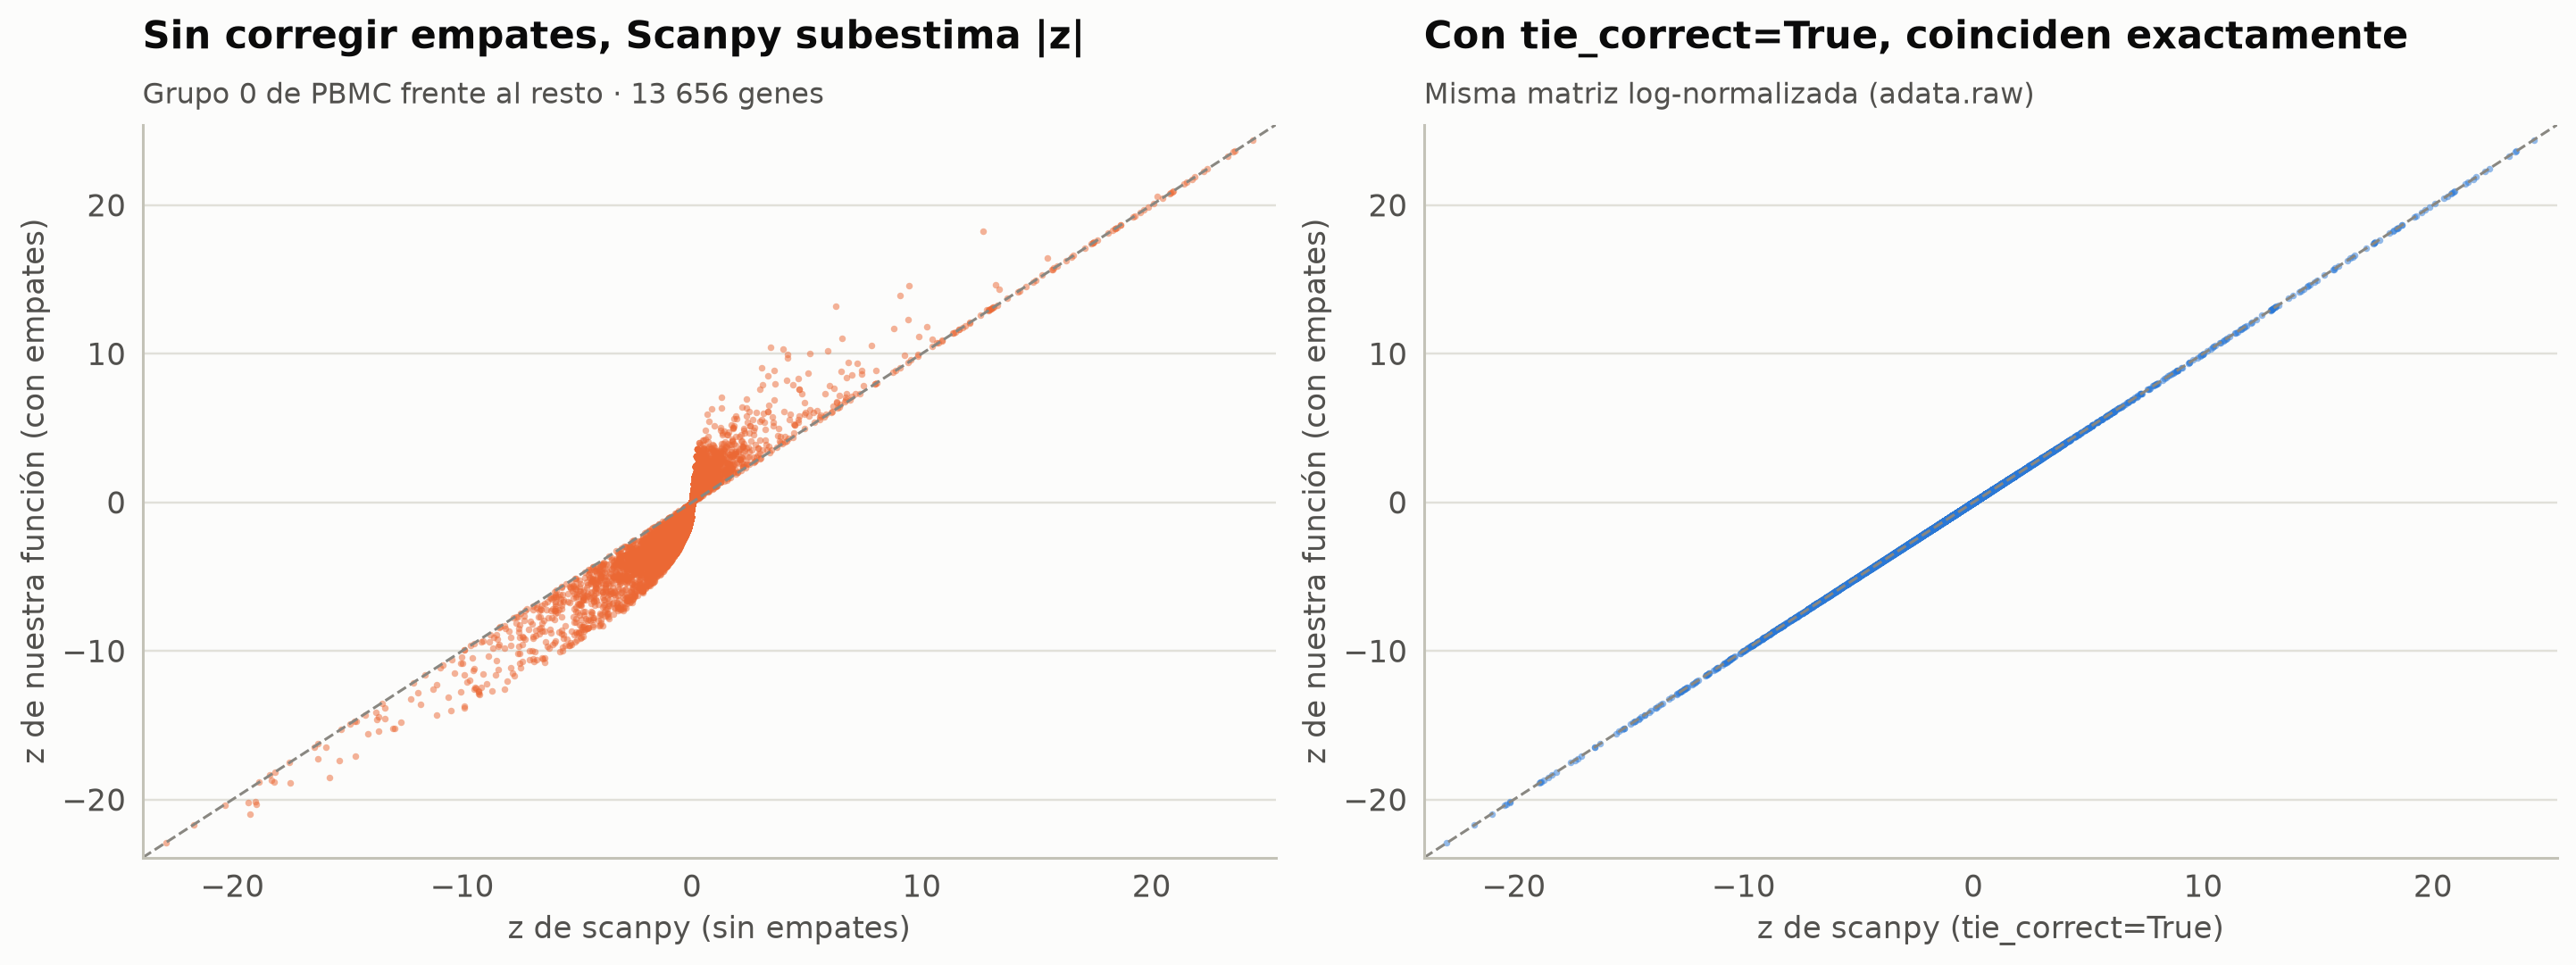

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, col, color in zip(axs, cmp.columns[1:], (ec.ORANGE, ec.BLUE)):
    ax.scatter(cmp[col], cmp["nuestro"], s=6, color=color, alpha=0.5, lw=0)
    lim = [cmp.values.min() - 1, cmp.values.max() + 1]
    ax.plot(lim, lim, color=ec.MUTED, lw=1, ls="--")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"z de {col}"); ax.set_ylabel("z de nuestra función (con empates)")
ec.title(axs[0], "Sin corregir empates, Scanpy subestima |z|",
         f"Grupo {g0} de PBMC frente al resto · 13 656 genes")
ec.title(axs[1], "Con tie_correct=True, coinciden exactamente", "Misma matriz log-normalizada (adata.raw)")
plt.show()

> 🔎 **Qué observamos.** Con `tie_correct=True`, nuestra implementación y la de Scanpy coinciden hasta la cuarta cifra
> decimal. Sin corrección, los $\lvert z\rvert$ de Scanpy son **menores**, y no por poco: en el grupo 0 la diferencia
> llega a $6{,}99$ unidades de $z$, sobre todo en genes con muchos ceros (muchos empates en el rango más bajo): ignorar
> los empates sobrestima la varianza de $U$. Para **ordenar** marcadores da casi igual (el orden cambia poco);
> para interpretar valores $p$ conviene saberlo.

Veamos los mejores marcadores de cada grupo de PBMC, ordenados por $z$:

In [29]:
top_pb = (mk_pb[(mk_pb.log2fc > 0)].sort_values("z", ascending=False).groupby("group").head(6)
          .sort_values(["group", "z"], ascending=[True, False]))
table = top_pb.groupby("group").apply(
    lambda d: ", ".join(f"{g} ({a:.2f})" for g, a in zip(d.gene, d.auc)), include_groups=False)
with pd.option_context("display.max_colwidth", None):   # que no se trunque la lista de marcadores
    display(pd.DataFrame({"n células": np.bincount(lab_leiden), "6 mejores marcadores (AUC)": table}))

,n células,6 mejores marcadores (AUC)
group,,
0,627,"RPS12 (0.82), RPS27 (0.81), RPL32 (0.81), RPS6 (0.81), RPS25 (0.80), RPS14 (0.79)"
1,526,"LTB (0.78), IL32 (0.77), CD3D (0.76), LDHB (0.76), AQP3 (0.67), TNFRSF4 (0.60)"
2,342,"CD79A (0.97), MS4A1 (0.92), CD79B (0.94), TCL1A (0.81), LINC00926 (0.78), HLA-DQA1 (0.92)"
3,485,"LGALS2 (0.93), S100A8 (0.97), S100A9 (0.99), FCN1 (0.95), TYROBP (0.96), CD14 (0.82)"
4,152,"RP11-290F20.3 (0.90), CDKN1C (0.74), HES4 (0.77), FCGR3A (0.95), MS4A7 (0.87), CKB (0.68)"
5,153,"GZMB (0.97), FGFBP2 (0.92), SPON2 (0.85), PRF1 (0.96), XCL2 (0.77), GNLY (0.97)"
6,302,"CCL5 (0.95), NKG7 (0.90), CST7 (0.84), GZMK (0.77), GZMA (0.83), CTSW (0.82)"
7,36,"FCER1A (0.91), SERPINF1 (0.72), CLEC10A (0.84), ENHO (0.71), CLIC2 (0.62), CLEC4C (0.58)"
8,15,"GP9 (0.93), AP001189.4 (0.90), ITGA2B (0.90), TMEM40 (0.87), SEPT5 (0.83), LY6G6F (0.77)"


> 🔎 **Qué observamos.** Aun sin saber inmunología, la lista ya habla: un grupo con *CD79A*, *MS4A1* y moléculas
> HLA de clase II (*HLA-DQA1*, presentación de antígeno) es de **linfocitos B**; uno con *S100A8*, *S100A9*, *FCN1* y
> *CD14* (proteínas antimicrobianas y el receptor del lipopolisacárido) son **monocitos**; uno con *GZMB*, *PRF1* y
> *GNLY* (gránulos citotóxicos) son **NK**; uno con *GP9* e *ITGA2B* (glucoproteínas de la membrana plaquetaria, la
> segunda es la integrina CD41) son **plaquetas**. Fíjese también en lo que **no** esperaría: el grupo más grande
> puede tener como «mejores» marcadores proteínas ribosómicas (*RPS*, *RPL*), que no definen un tipo sino un estado
> (linfocitos pequeños y en reposo, con poco ARN aparte del ribosómico). Es la misma lección que el gradiente simulado.

### 7.6 AUC frente a valor $p$

La interpretación como AUC es la más útil: dice qué tan bien el gen, **por sí solo**, identifica a las células del
grupo, con independencia de cuántas células haya. El valor $p$, en cambio, depende brutalmente del tamaño. Lo vemos
submuestreando el grupo de monocitos CD14: el mismo gen, con el mismo AUC, se vuelve cada vez «más significativo».

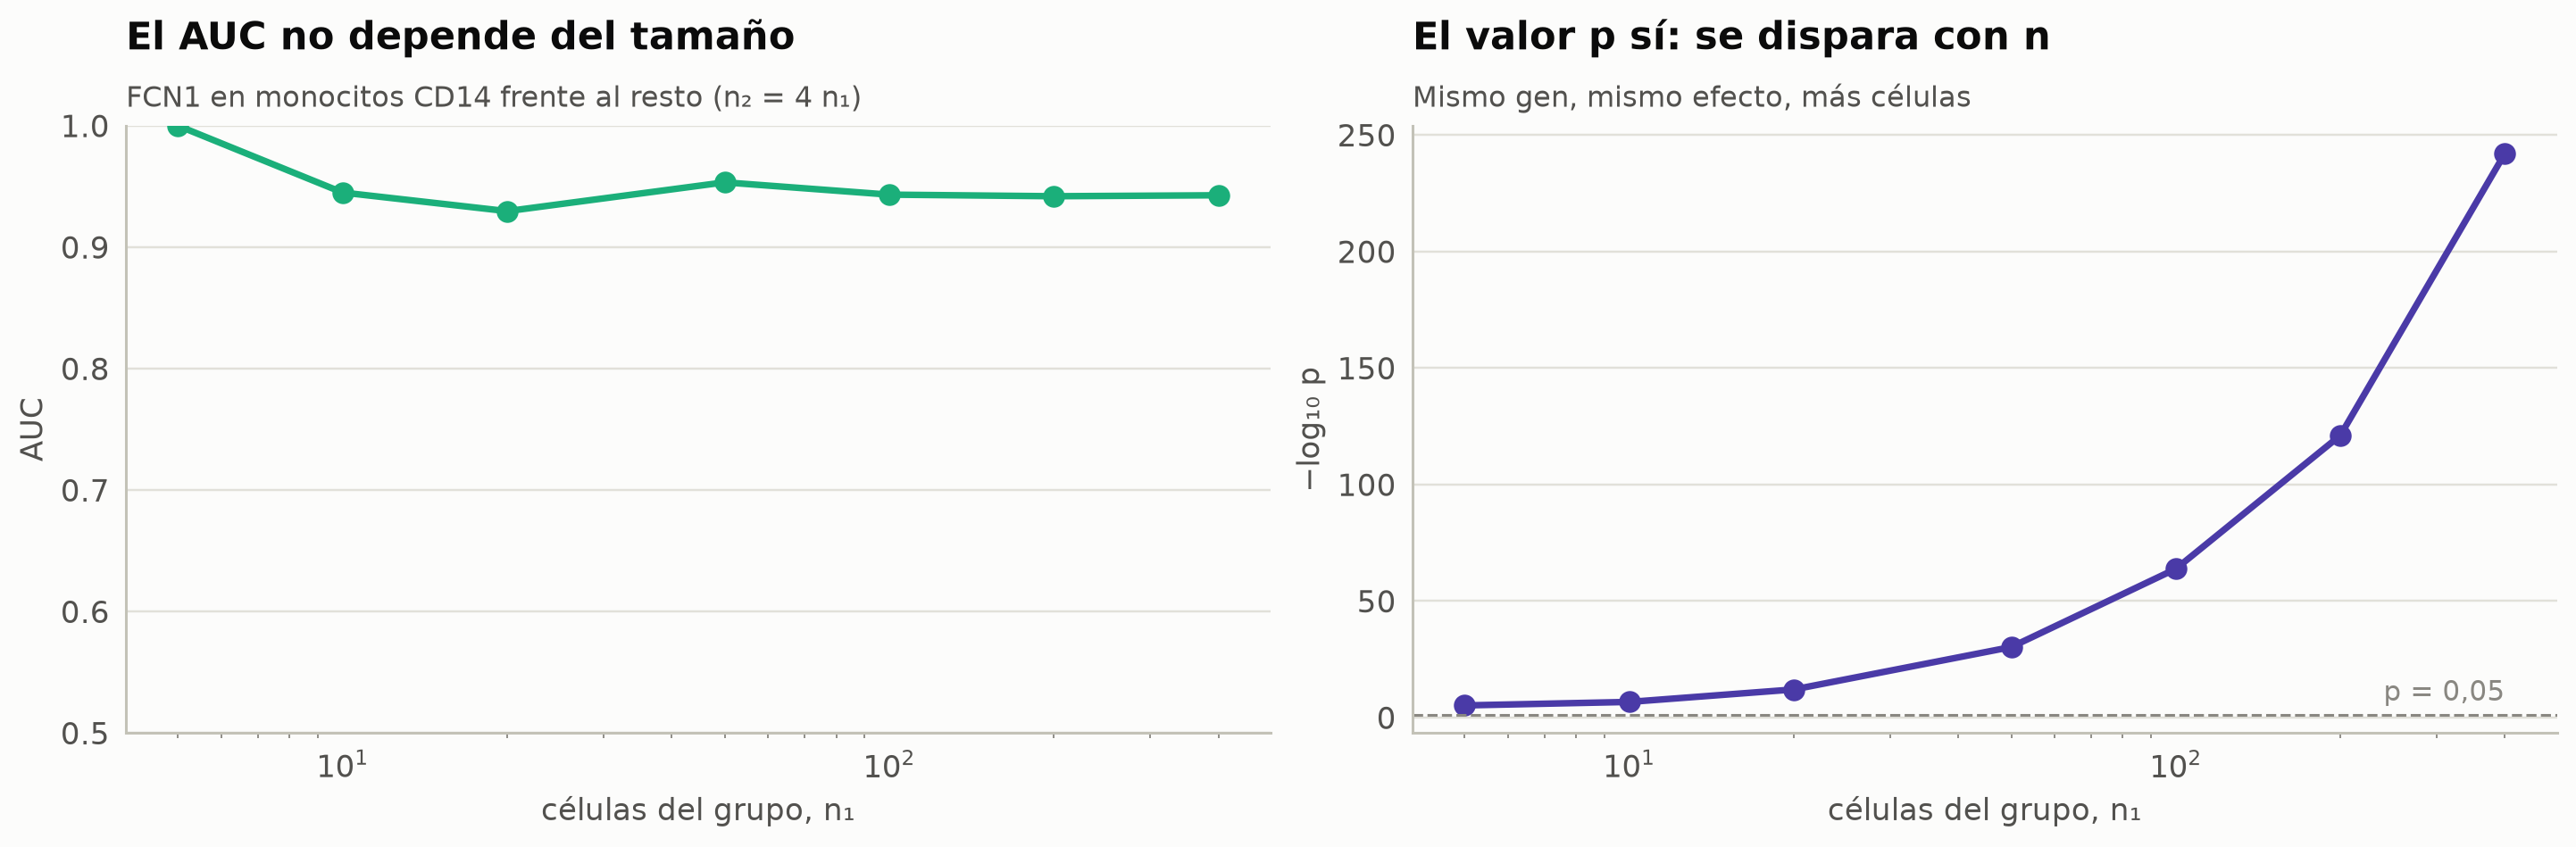

,n1,AUC,mlog10p
0,5,1.000,5.235
1,10,0.945,6.732
2,20,0.930,12.077
3,50,0.953,30.284
4,100,0.943,63.831
5,200,0.942,121.115
6,400,0.943,242.144


In [30]:
mono_grp = int(mk_pb[mk_pb.gene == "CD14"].sort_values("z").group.iloc[-1])     # grupo con mayor z de CD14
gene_demo = "FCN1"
j = int(np.where(genes_pb == gene_demo)[0][0])
xg = np.asarray(Xlog[:, j].todense()).ravel()
rng = np.random.default_rng(0)
rows = []
for n_sub in (5, 10, 20, 50, 100, 200, 400):
    inn = rng.choice(np.where(lab_leiden == mono_grp)[0], n_sub, replace=False)
    out = rng.choice(np.where(lab_leiden != mono_grp)[0], 4 * n_sub, replace=False)
    both = np.r_[xg[inn], xg[out]]; n1, n2 = n_sub, 4 * n_sub; N = n1 + n2
    U = stats.rankdata(both)[:n1].sum() - n1 * (n1 + 1) / 2
    _, t = np.unique(both, return_counts=True)
    z = (U - n1 * n2 / 2) / np.sqrt(n1 * n2 / 12 * ((N + 1) - np.sum(t ** 3.0 - t) / (N * (N - 1))))
    mlog10p = -(np.log(2) + stats.norm.logsf(abs(z))) / np.log(10)   # en logaritmos: sin desbordamiento
    rows.append((n_sub, U / (n1 * n2), mlog10p))
dfp = pd.DataFrame(rows, columns=["n1", "AUC", "mlog10p"])
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
axs[0].plot(dfp.n1, dfp.AUC, "o-", color=ec.AQUA, lw=2.4); axs[0].set_ylim(0.5, 1)
axs[0].set_ylabel("AUC")
ec.title(axs[0], "El AUC no depende del tamaño", f"{gene_demo} en monocitos CD14 frente al resto (n₂ = 4 n₁)")
axs[1].plot(dfp.n1, dfp.mlog10p, "o-", color=ec.VIOLET, lw=2.4)
axs[1].axhline(-np.log10(0.05), color=ec.MUTED, ls="--", lw=1)
axs[1].text(400, -np.log10(0.05) + 6, "p = 0,05", color=ec.MUTED, fontsize=10, ha="right")
axs[1].set_ylabel("−log₁₀ p")
ec.title(axs[1], "El valor p sí: se dispara con n", "Mismo gen, mismo efecto, más células")
for ax in axs:
    ax.set_xscale("log"); ax.set_xlabel("células del grupo, n₁")
plt.show()
dfp.round(3)

> 🔎 **Qué observamos.** El AUC de *FCN1* (ficolina, un marcador de monocitos clásicos) oscila alrededor del mismo valor
> sea cual sea el tamaño de la muestra (≈ 0,94); el $-\log_{10}p$ crece casi en proporción a $n_1$. Con 400
> monocitos, el valor $p$ es tan pequeño que hay que calcularlo en logaritmos (con `norm.logsf`): en coma flotante
> ordinaria sería exactamente 0. Por eso, para **ordenar** marcadores, mire el AUC (o el $z$), el
> log2FC y el porcentaje de células que expresan el gen dentro y fuera del grupo; el valor $p$ casi nunca decide nada.

### 7.7 Explore los marcadores (interactivo)

Cada punto es un gen; el eje horizontal es el log2 del cambio de expresión (grupo frente al resto) y el vertical, el
AUC. Use el menú para cambiar de grupo y **pase el cursor** por los puntos: verá en qué porcentaje de células del grupo
y de fuera se detecta el gen. Los buenos marcadores están **arriba a la derecha** y tienen un porcentaje alto dentro y
bajo fuera.

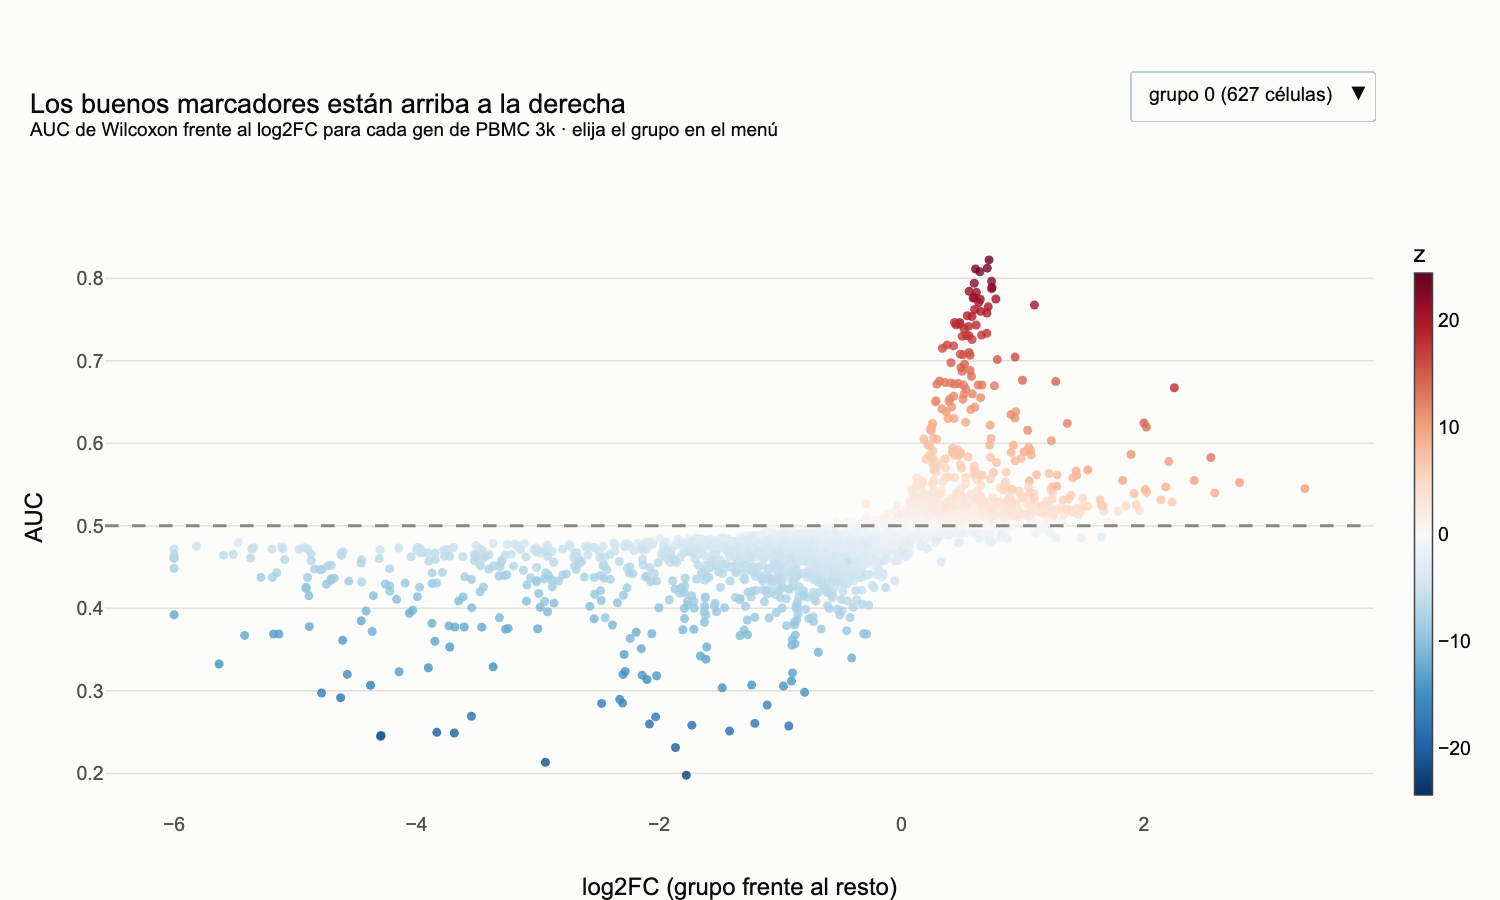

In [31]:
groups_pb = sorted(mk_pb.group.unique())
fig = go.Figure()
for gi in groups_pb:
    d = mk_pb[(mk_pb.group == gi) & ((mk_pb.pct_in > 0.05) | (mk_pb.pct_out > 0.05))]
    fig.add_trace(go.Scatter(
        x=d.log2fc.clip(-6, 8), y=d.auc, mode="markers", visible=(gi == groups_pb[0]), name=f"grupo {gi}",
        marker=dict(size=6, color=d.z.clip(-30, 30), colorscale="RdBu_r", cmid=0, opacity=0.8,
                    colorbar=dict(title="z", thickness=12)),
        text=d.gene,
        customdata=np.column_stack([100 * d.pct_in, 100 * d.pct_out, d.z, d.qval]),
        hovertemplate=("<b>%{text}</b><br>AUC = %{y:.3f} · log2FC = %{x:.2f}"
                       "<br>detectado en %{customdata[0]:.0f} % del grupo y %{customdata[1]:.0f} % del resto"
                       "<br>z = %{customdata[2]:.1f} · q = %{customdata[3]:.1e}<extra></extra>")))
fig.add_hline(y=0.5, line=dict(color="#898781", dash="dash"))
fig.update_layout(
    updatemenus=[dict(buttons=[dict(label=f"grupo {gi} ({np.sum(lab_leiden == gi)} células)", method="update",
                                    args=[{"visible": [g == gi for g in groups_pb]}]) for gi in groups_pb],
                      x=1.0, xanchor="right", y=1.18, yanchor="bottom")],
    title="Los buenos marcadores están arriba a la derecha<br>"
          "<sup>AUC de Wilcoxon frente al log2FC para cada gen de PBMC 3k · elija el grupo en el menú</sup>",
    xaxis_title="log2FC (grupo frente al resto)", yaxis_title="AUC", height=600, showlegend=False,
    margin=dict(t=150, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** En casi todos los grupos, la nube de genes forma una «V» invertida: los genes con log2FC
> grande **y** AUC cercano a 1 son los marcadores limpios. Hay dos trampas típicas: genes con log2FC enorme pero AUC
> modesto (se expresan muchísimo en **pocas** células del grupo; útiles para subtipos, no para el grupo entero), y
> genes con AUC por debajo de 0,5 (marcadores **negativos**: el grupo los ha apagado, como *LYZ* en los linfocitos).

> ⚠️ **Cuidado: doble uso de los datos.** Los *clusters* se definieron **con** la expresión génica, y después se prueba
> si la expresión génica difiere entre ellos. Por construcción, sí difiere: incluso en datos sin estructura, un
> algoritmo de agrupamiento partirá las células en grupos, y la prueba de Wilcoxon encontrará «marcadores» muy
> significativos entre ellos. Los valores $p$ de los marcadores sirven para **ordenar** genes, no como evidencia de que
> los grupos existen. Para comparar condiciones (tratado frente a control), sume las cuentas de cada tipo celular por
> muestra (*pseudobulk*) y use los modelos binomiales negativos del Módulo 11 con las **muestras**, no las células,
> como réplicas (Heumos *et al.*, 2023).

Comprobémoslo con datos **sin ninguna estructura**: 1 500 células en las que cada gen tiene la misma distribución en
todas ellas.

In [32]:
rng = np.random.default_rng(11)
mu_g = rng.lognormal(-0.5, 1.2, 1000)                       # 1 000 genes, misma media en TODAS las células
lib = rng.lognormal(0, 0.3, 1500)[:, None]
Xnull = rng.poisson(lib * mu_g[None, :]).astype(np.float32)
ad0 = sc.AnnData(sparse.csr_matrix(Xnull))
sc.pp.normalize_total(ad0, target_sum=1e4); sc.pp.log1p(ad0)
sc.pp.pca(ad0, n_comps=20, random_state=0)
sc.pp.neighbors(ad0, n_neighbors=15, random_state=0)
sc.tl.leiden(ad0, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0)
lab0 = ad0.obs["leiden"].astype(int).values
mk0 = wilcoxon_markers(ad0.X, lab0, np.array([f"g{i}" for i in range(1000)]))
best0 = mk0.sort_values("pval").groupby("group").head(1)
print(f"Datos SIN estructura → Leiden encuentra {lab0.max() + 1} grupos")
print(f"Genes con q < 0,05 en algún grupo: {mk0[mk0.qval < 0.05].gene.nunique()} de 1000")
best0[["group", "gene", "auc", "pval", "qval"]].round(4)

Datos SIN estructura → Leiden encuentra 11 grupos
Genes con q < 0,05 en algún grupo: 227 de 1000


,group,gene,auc,pval,qval
4959,4,g959,0.3611,0.0000,0.0000
1003,1,g3,0.5815,0.0000,0.0001
3593,3,g593,0.4060,0.0000,0.0008
10291,10,g291,0.6190,0.0000,0.0077
7355,7,g355,0.3721,0.0000,0.0067
2265,2,g265,0.6058,0.0000,0.0247
5004,5,g4,0.3953,0.0000,0.0183
486,0,g486,0.4058,0.0001,0.0350
8186,8,g186,0.6298,0.0001,0.0613
9906,9,g906,0.5724,0.0001,0.0698


> 🔎 **Qué observamos.** Leiden parte la nube homogénea en varios grupos (siempre encuentra *algo*), y Wilcoxon devuelve
> «marcadores» con valores $q$ pequeños para esos grupos inventados, aunque por construcción ningún gen difiere entre
> células. Los AUC, eso sí, se alejan de 0,5 sólo unas décimas (entre ≈ 0,36 y 0,63): otra razón para mirar el AUC y no el valor $p$. Ante un grupo nuevo,
> la pregunta no es «¿tiene marcadores significativos?» (siempre los tendrá) sino «¿tiene marcadores **específicos** y
> con sentido biológico, que se reproducen en otras muestras?».

> ✅ **Compruebe su comprensión.** (1) Un gen tiene AUC $=0{,}30$ en un grupo. ¿Qué significa? (2) ¿Por qué el
> término de empates $\sum_t(t^3-t)$ es casi siempre dominado por un único grupo en célula única?

## 8. Anotación de tipos celulares

### 8.1 Marcadores canónicos de la sangre

Con los marcadores en mano, la anotación clásica es **manual**: se contrastan los genes de cada grupo con el
conocimiento previo. Muchos de estos genes codifican las mismas proteínas que la citometría de flujo usa para el
inmunofenotipo clínico (los «CD», *cluster of differentiation*), lo que permite traducir entre ambos mundos.

| Población | Marcadores de ARN | Qué hacen esas proteínas | Equivalente en citometría |
|---|---|---|---|
| Linfocitos T (todos) | *CD3E*, *CD3D* | complejo del receptor de linfocitos T | CD3⁺ |
| T CD4 vírgenes | *IL7R*, *CCR7*, *LEF1* | receptor de IL-7; receptor de quimiocinas para ir a los ganglios | CD4⁺ CD45RA⁺ CCR7⁺ |
| T CD4 de memoria | *IL7R*, *S100A4* | proteína de unión a calcio, alta en células activadas | CD4⁺ CD45RO⁺ |
| T CD8 | *CD8A*, *CD8B*, *GZMK* | correceptor CD8; granzima K | CD8⁺ |
| NK | *GNLY*, *NKG7*, *GZMB* (y sin *CD3E*) | granulisina, gránulos citotóxicos, granzima B | CD3⁻ CD56⁺ |
| Linfocitos B | *MS4A1*, *CD79A*, *CD79B* | CD20 (diana del rituximab); receptor de linfocitos B | CD19⁺ CD20⁺ |
| Monocitos clásicos | *CD14*, *LYZ*, *S100A8* | receptor del lipopolisacárido; lisozima; calprotectina | CD14⁺⁺ CD16⁻ |
| Monocitos no clásicos | *FCGR3A*, *MS4A7* | CD16 (receptor de Fc de IgG) | CD14 bajo (*dim*) CD16⁺⁺ |
| Dendríticas | *FCER1A*, *CST3*, *CD1C* | receptor de IgE; cistatina C; presentación de lípidos | HLA-DR⁺ CD1c⁺ |
| Plaquetas | *PPBP*, *PF4* | quimiocinas plaquetarias (CXCL7, CXCL4) | CD41⁺ |

Para hacer la anotación **reproducible**, en lugar de mirar a ojo calculamos para cada grupo el AUC medio de los
marcadores de cada población y le asignamos la población con mayor puntuación. Como en citometría, algunas poblaciones
se definen también por lo que **no** expresan: las NK comparten con los T CD8 el programa citotóxico (*NKG7*, *GZMB*),
pero no tienen receptor de linfocitos T (son CD3⁻). Por eso a las NK les sumamos el marcador negativo *CD3E*, que
cuenta como $1-\mathrm{AUC}$. Es una regla simple, pero transparente.

         n       anotación  puntuación  segunda opción
group                                                 
0      627  T CD4 vírgenes       0.650           T CD8
1      526   T CD4 memoria       0.649  T CD4 vírgenes
2      342               B       0.943       Plaquetas
3      485       Mono CD14       0.927     Dendríticas
4      152     Mono FCGR3A       0.914       Mono CD14
5      153              NK       0.869     Mono FCGR3A
6      302           T CD8       0.673              NK
7       36     Dendríticas       0.861       Mono CD14
8       15       Plaquetas       0.983     Dendríticas


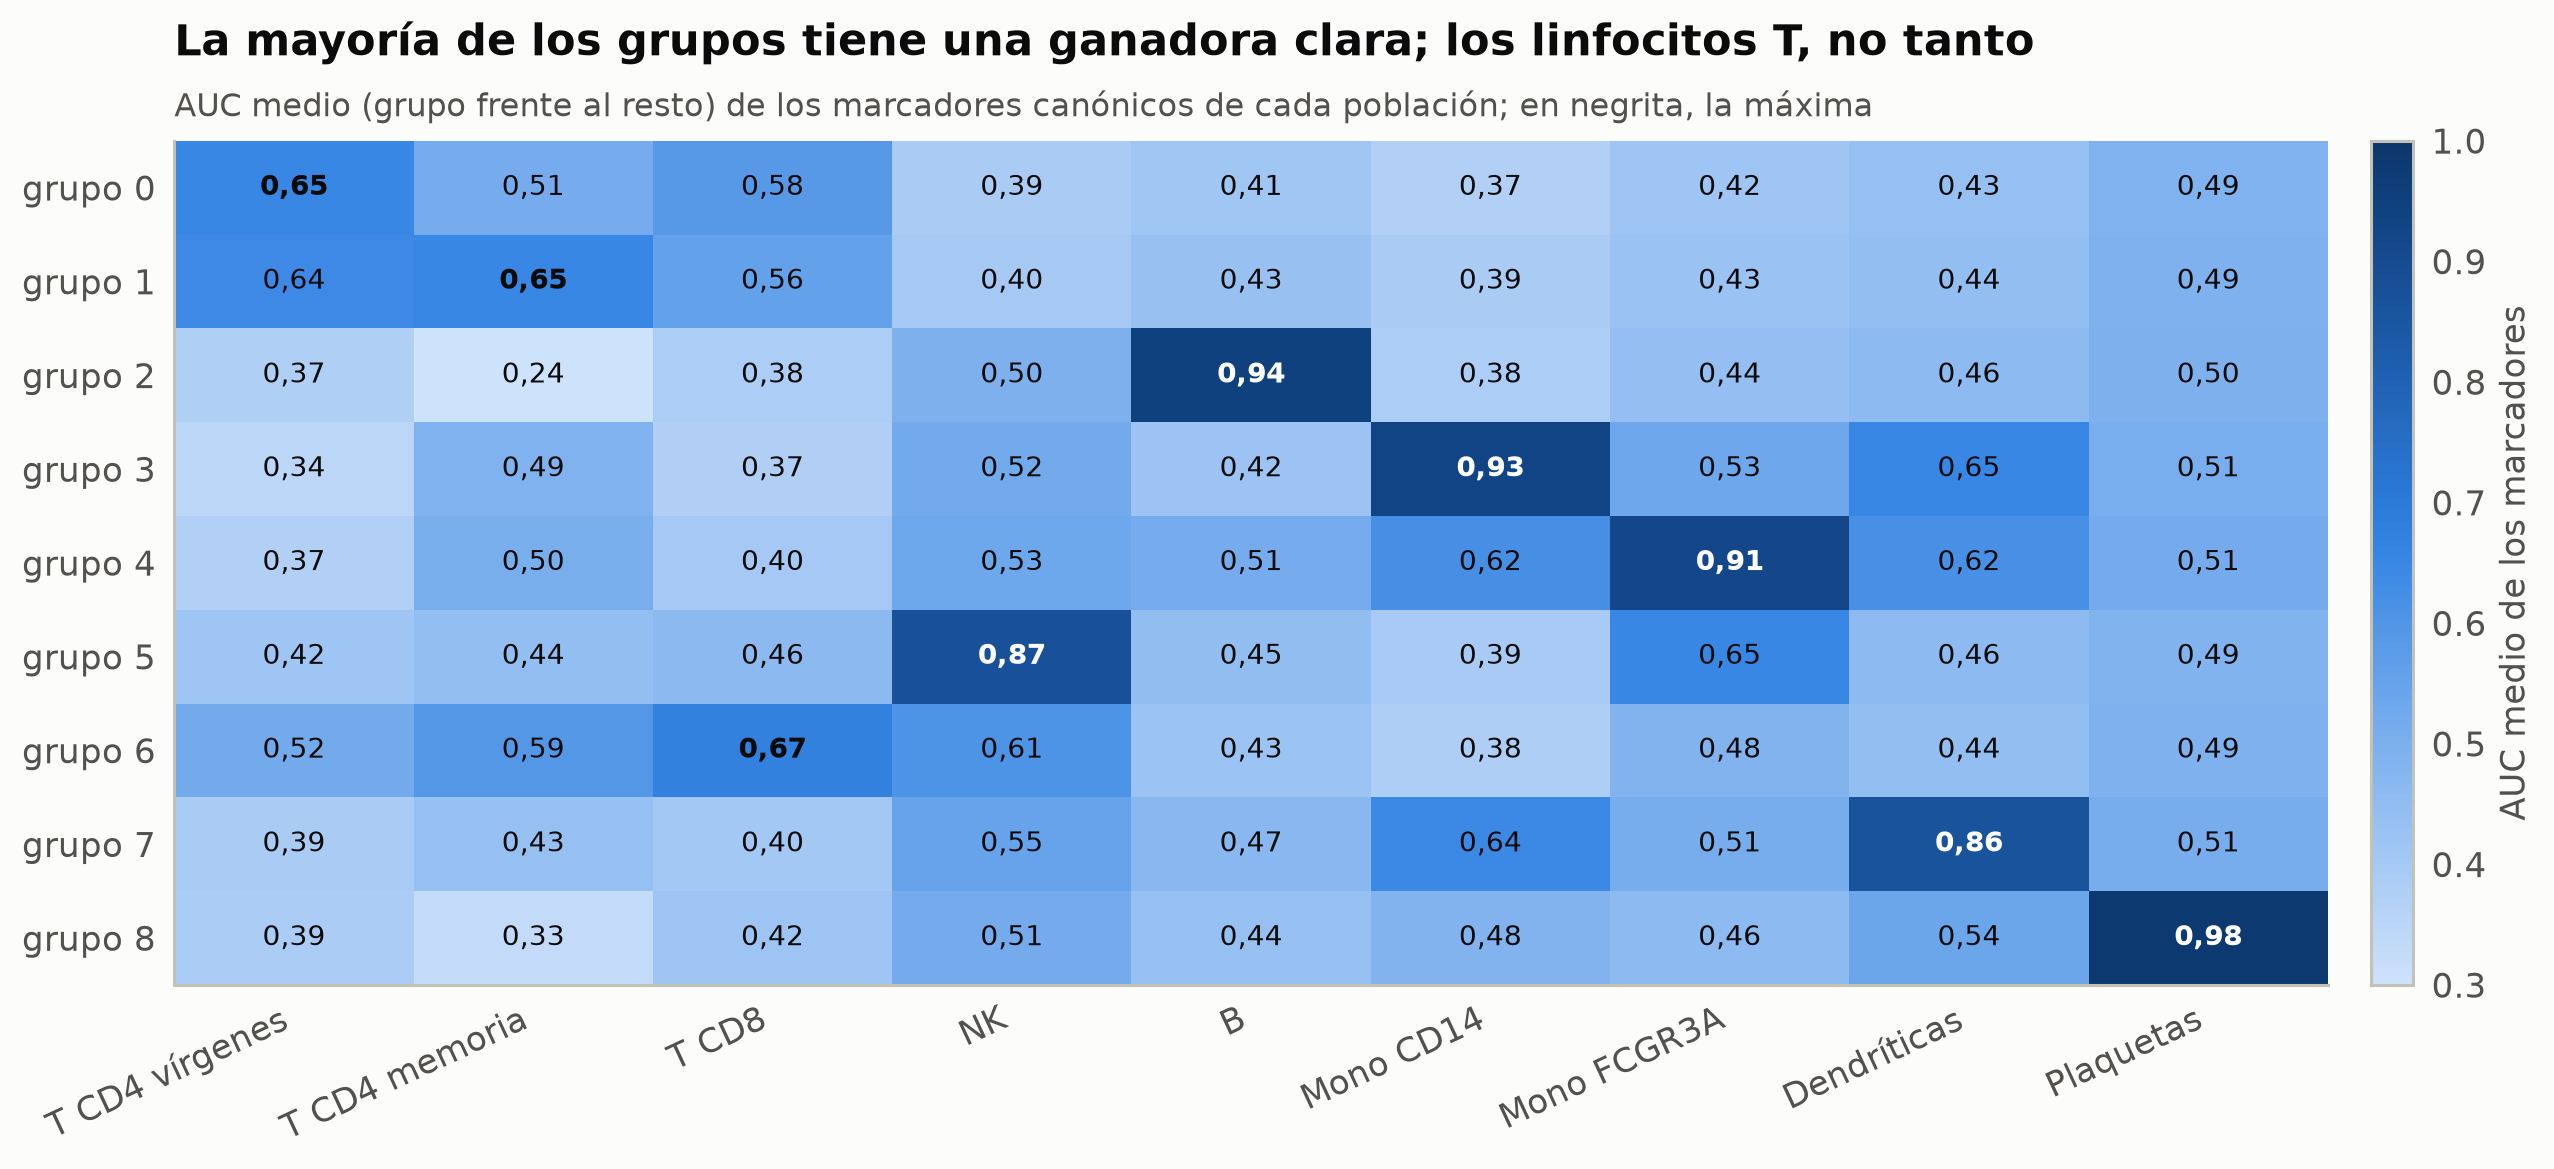

In [33]:
MARKERS = {
    "T CD4 vírgenes": ["CD3E", "IL7R", "CCR7", "LEF1"],
    "T CD4 memoria": ["CD3E", "IL7R", "S100A4"],
    "T CD8": ["CD3E", "CD8A", "CD8B"],
    "NK": ["GNLY", "NKG7", "GZMB", "-CD3E"],          # "-": marcador negativo (NK = CD3⁻), se usa 1 − AUC
    "B": ["MS4A1", "CD79A", "CD79B"],
    "Mono CD14": ["CD14", "LYZ", "S100A8"],
    "Mono FCGR3A": ["FCGR3A", "MS4A7"],
    "Dendríticas": ["FCER1A", "CST3", "CD1C"],
    "Plaquetas": ["PPBP", "PF4"],
}
auc_tab = mk_pb.pivot(index="group", columns="gene", values="auc")
def marker_score(genes):
    """AUC medio de los marcadores; los negativos ("-GEN") cuentan como 1 − AUC."""
    cols = [auc_tab[g] if not g.startswith("-") else 1 - auc_tab[g[1:]] for g in genes]
    return pd.concat(cols, axis=1).mean(axis=1)

score = pd.DataFrame({t: marker_score(g) for t, g in MARKERS.items()})
annot = score.idxmax(axis=1)
print(pd.DataFrame({"n": np.bincount(lab_leiden), "anotación": annot,
                    "puntuación": score.max(axis=1).round(3),
                    "segunda opción": score.apply(lambda r: r.drop(r.idxmax()).idxmax(), axis=1)}).to_string())

fig, ax = plt.subplots(figsize=(11.5, 5.2))
im = ax.imshow(score.values, cmap=ec.CMAP_SEQ, vmin=0.3, vmax=1, aspect="auto")
for i in range(score.shape[0]):
    for j in range(score.shape[1]):
        v = score.values[i, j]
        ax.text(j, i, f"{v:.2f}".replace(".", ","), ha="center", va="center", fontsize=9,
                color="white" if v > 0.75 else ec.INK, fontweight="bold" if score.columns[j] == annot.iloc[i] else None)
ax.set_xticks(range(score.shape[1]), score.columns, rotation=25, ha="right")
ax.set_yticks(range(score.shape[0]), [f"grupo {g}" for g in score.index]); ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cb.set_label("AUC medio de los marcadores")
ec.title(ax, "La mayoría de los grupos tiene una ganadora clara; los linfocitos T, no tanto",
         "AUC medio (grupo frente al resto) de los marcadores canónicos de cada población; en negrita, la máxima")
plt.show()
adata.obs["cell_type"] = pd.Categorical(annot.loc[lab_leiden].values, categories=list(MARKERS))

> 🔎 **Qué observamos.** En los grupos de B, monocitos, NK, dendríticas y plaquetas una casilla destaca con claridad
> (AUC medio 0,86–0,98); en los tres grupos de linfocitos T las puntuaciones son más bajas y parejas. La anotación coincide con la del
> tutorial clásico de este conjunto de datos: dos grupos de T CD4 (vírgenes y de memoria), T CD8, NK, B, monocitos CD14
> y FCGR3A, dendríticas y un grupo pequeño de plaquetas. Donde la segunda opción está cerca (T CD4 vírgenes frente a
> memoria, T CD8 frente a NK) la frontera es genuinamente difusa: son estados de un mismo linaje, no tipos separados por un abismo.

### 8.2 El *dot plot*

El ***dot plot*** es la visualización estándar para la anotación porque codifica a la vez dos cantidades que en célula
única **no coinciden**: qué **fracción** de las células del grupo detecta el gen (tamaño del punto) y **cuánto** lo
expresan en promedio (color). Un gen puede tener una media alta porque unas pocas células lo expresan muchísimo, o
porque todas lo expresan un poco; el *dot plot* distingue ambos casos.

Primero reproducimos el del libro sobre la simulación: 14 marcadores canónicos en los siete *clusters* de Louvain
($\gamma=1$), con la expresión media escalada entre 0 y 1 para cada gen.

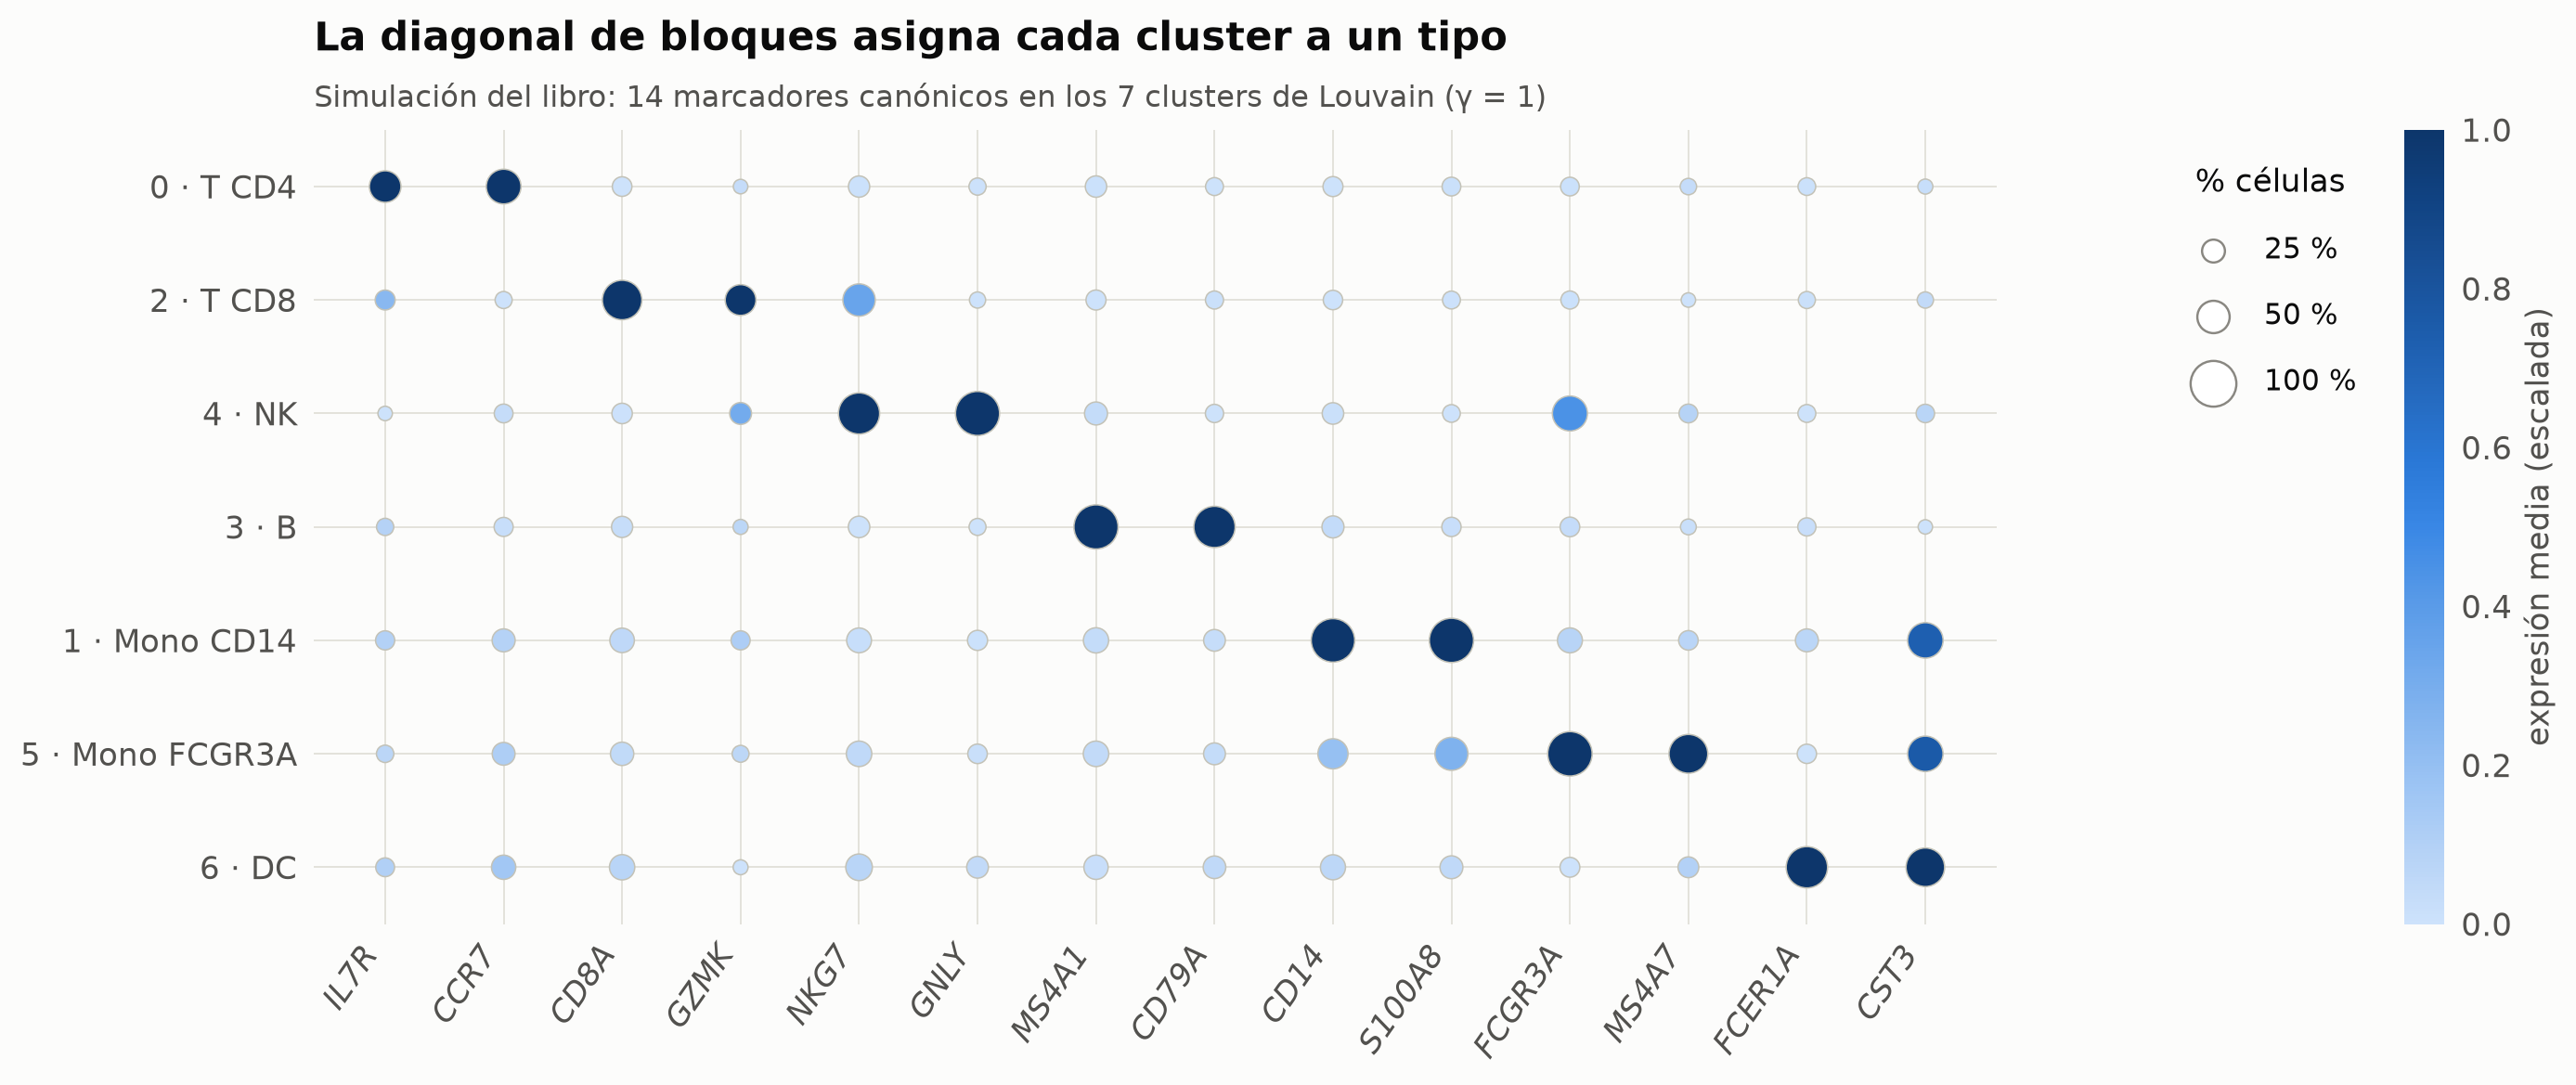

In [34]:
def dot_plot(ax, frac, mean, genes, rows, size=260, title=None, sub=None):
    """Dot plot desde cero: tamaño = fracción de células con el gen; color = media escalada 0–1 por gen."""
    mean_s = (mean - mean.min(0)) / (mean.max(0) - mean.min(0) + 1e-12)
    yy, xx = np.meshgrid(np.arange(len(rows)), np.arange(len(genes)), indexing="ij")
    sca = ax.scatter(xx.ravel(), yy.ravel(), s=frac.ravel() * size, c=mean_s.ravel(), cmap=ec.CMAP_SEQ,
                     vmin=0, vmax=1, edgecolors=ec.BASELINE, linewidths=0.5)
    ax.set_xticks(range(len(genes)), genes, rotation=55, ha="right", style="italic")
    ax.set_yticks(range(len(rows)), rows)
    ax.set_xlim(-0.6, len(genes) - 0.4); ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.grid(color=ec.GRID, lw=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    cb = plt.colorbar(sca, ax=ax, fraction=0.025, pad=0.015)
    cb.set_label("expresión media (escalada)"); cb.outline.set_visible(False)
    handles = [ax.scatter([], [], s=f * size, c="white", edgecolors=ec.MUTED, linewidths=0.8) for f in (0.25, 0.5, 1)]
    ax.legend(handles, ["25 %", "50 %", "100 %"], title="% células", loc="upper left", bbox_to_anchor=(1.09, 1.0),
              frameon=False, labelspacing=1.3, borderpad=0.8)
    if title:
        ec.title(ax, title, sub)

genes_book = ["IL7R", "CCR7", "CD8A", "GZMK", "NKG7", "GNLY", "MS4A1", "CD79A", "CD14", "S100A8",
              "FCGR3A", "MS4A7", "FCER1A", "CST3"]
mk_names = list(sim["marker_names"].astype(str))
order_cl = sorted(range(K1), key=lambda c: (TYPES.index(anot_sim[c]), c))
Ym = sim["Ymark"][:, [mk_names.index(g) for g in genes_book]]
frac_s = np.array([(Ym[lab1 == c] > 0).mean(0) for c in order_cl])       # log1p(x) > 0  ⇔  al menos 1 UMI
mean_s = np.array([Ym[lab1 == c].mean(0) for c in order_cl])
fig, ax = plt.subplots(figsize=(12.5, 5.2))
dot_plot(ax, frac_s, mean_s, genes_book, [f"{c} · {anot_sim[c]}" for c in order_cl],
         title="La diagonal de bloques asigna cada cluster a un tipo",
         sub="Simulación del libro: 14 marcadores canónicos en los 7 clusters de Louvain (γ = 1)")
plt.show()

> 🔎 **Qué observamos.** La diagonal de bloques permite asignar cada grupo a un tipo: *IL7R*/*CCR7* (T CD4),
> *CD8A*/*GZMK* (T CD8), *NKG7*/*GNLY* (NK), *MS4A1*/*CD79A* (B), *CD14*/*S100A8* (monocitos clásicos),
> *FCGR3A*/*MS4A7* (monocitos no clásicos) y *FCER1A*/*CST3* (dendríticas). Los puntos pequeños y claros fuera de la
> diagonal son la huella del **ARN ambiental** (lección 12.1) y de los dobletes residuales.

Ahora el de PBMC 3k, con los grupos ordenados por linaje:

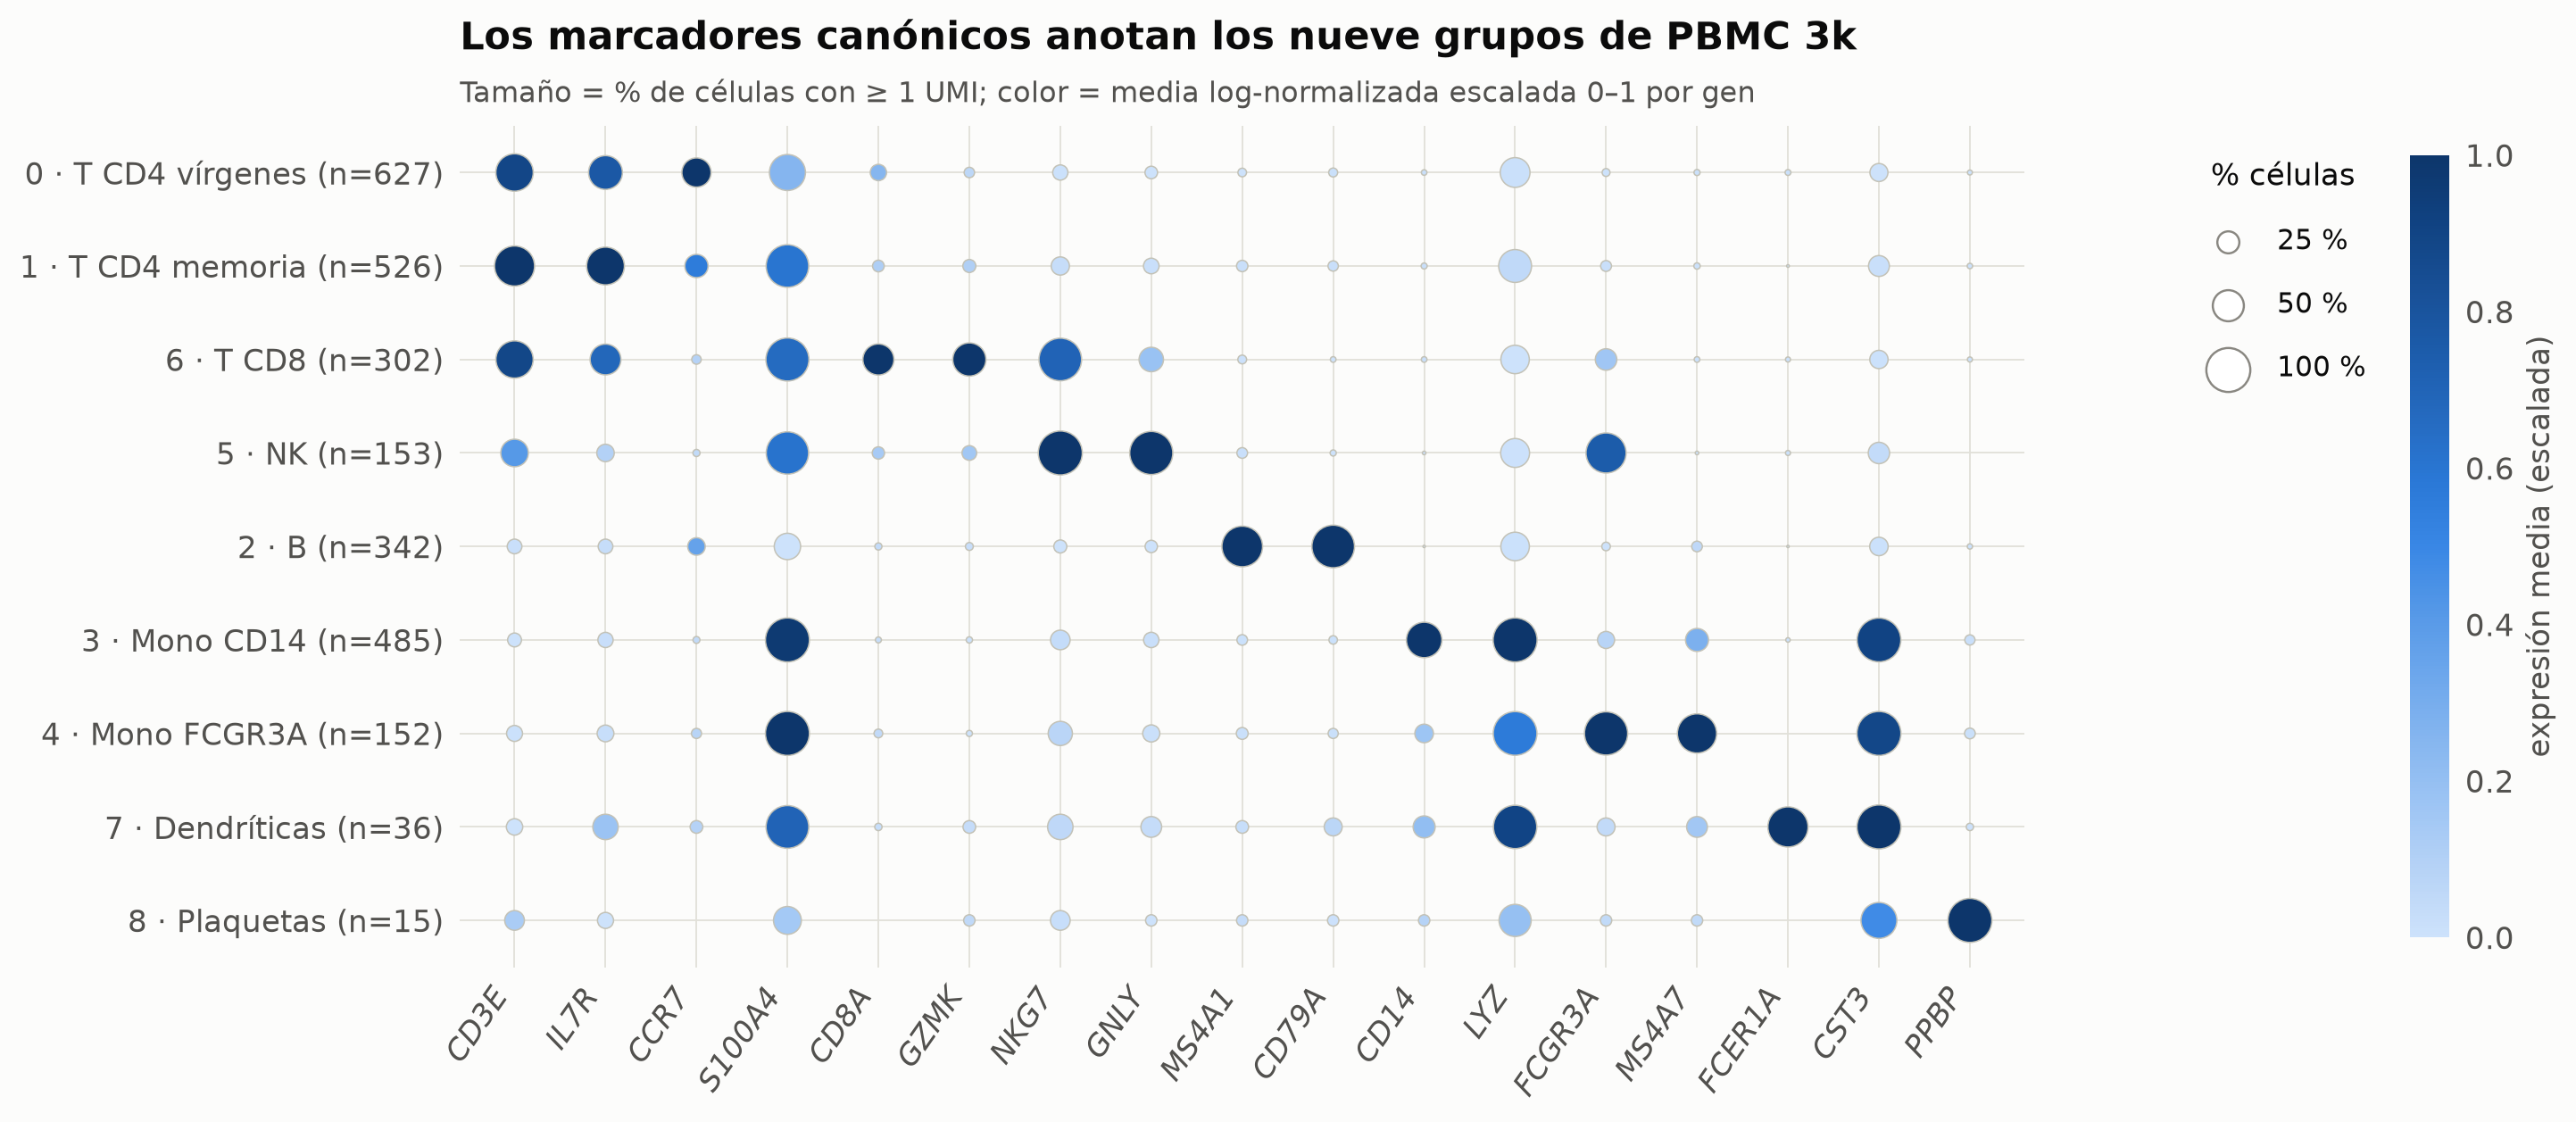

In [35]:
genes_pb_dp = ["CD3E", "IL7R", "CCR7", "S100A4", "CD8A", "GZMK", "NKG7", "GNLY", "MS4A1", "CD79A",
               "CD14", "LYZ", "FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"]
order_pb = sorted(range(lab_leiden.max() + 1), key=lambda c: (list(MARKERS).index(annot[c]), c))
Xd = adata.raw[:, genes_pb_dp].X.toarray()
frac_p = np.array([(Xd[lab_leiden == c] > 0).mean(0) for c in order_pb])
mean_p = np.array([Xd[lab_leiden == c].mean(0) for c in order_pb])
fig, ax = plt.subplots(figsize=(13, 5.6))
dot_plot(ax, frac_p, mean_p, genes_pb_dp, [f"{c} · {annot[c]} (n={np.sum(lab_leiden == c)})" for c in order_pb],
         title="Los marcadores canónicos anotan los nueve grupos de PBMC 3k",
         sub="Tamaño = % de células con ≥ 1 UMI; color = media log-normalizada escalada 0–1 por gen")
plt.show()

> 🔎 **Qué observamos.** La diagonal vuelve a aparecer, ahora con datos reales. Tres detalles que un inmunólogo
> reconocería: (1) *CD3E* ilumina a todos los linfocitos T y, más débil, a parte de las NK; (2) *S100A4* separa a los T
> CD4 de memoria de los vírgenes, que en cambio tienen más *CCR7*; (3) *NKG7* y *GZMK* aparecen también en los T CD8,
> porque comparten con las NK el programa citotóxico. Y fíjese en el tamaño de los puntos de *CCR7*: incluso en su grupo
> «propio» sólo lo detecta una fracción de las células. En célula única, **no detectar** un gen no significa que la
> célula no lo exprese: se capturan unos pocos miles de moléculas por célula.

La misma figura en una línea de Scanpy (la que usará en su trabajo):

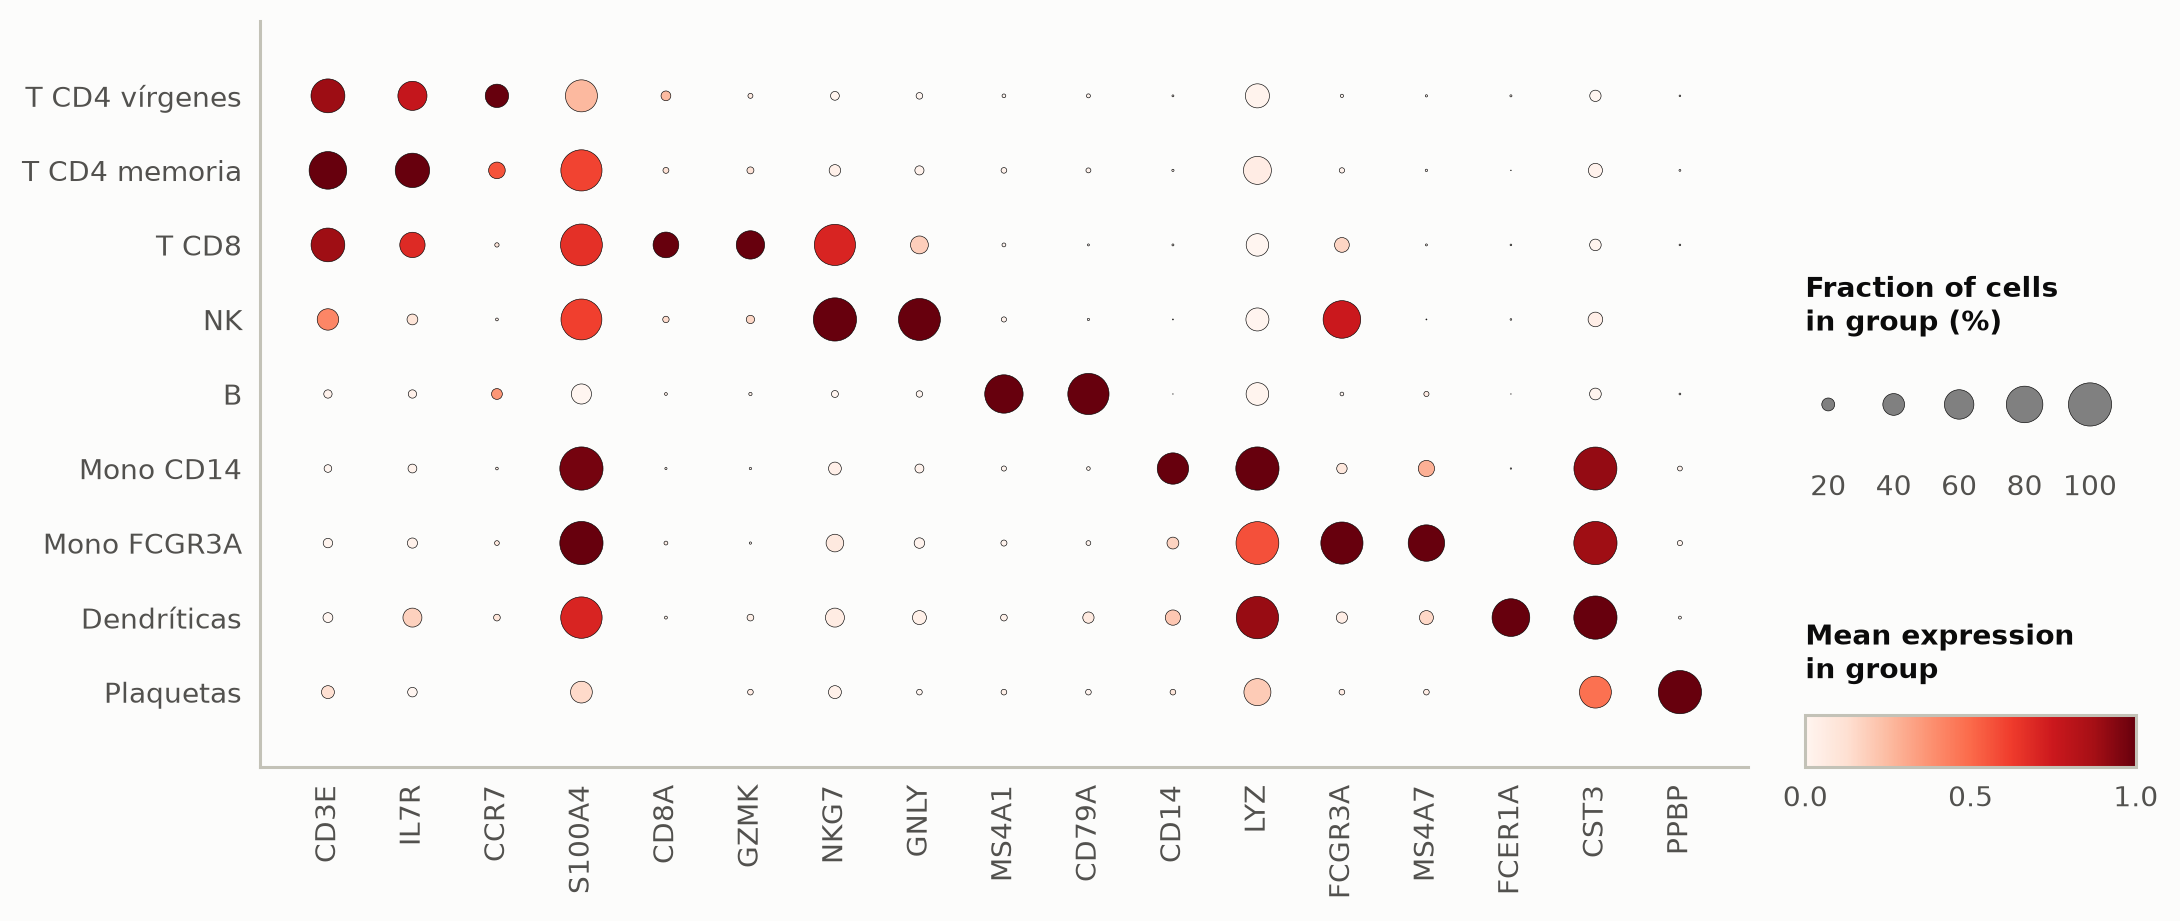

In [36]:
dp = sc.pl.dotplot(adata, genes_pb_dp, groupby="cell_type", standard_scale="var", show=False, figsize=(11, 4.4))
plt.show()

### 8.3 Un gen de libro que el ARN no ve: *CD4*

En citometría, CD4 es **el** marcador de los linfocitos T colaboradores. ¿Y en el ARN? Veamos en qué fracción de las
células de cada población se detecta al menos un UMI de *CD4*, *CD8A* y *CD3E*.

In [37]:
counts_raw = adata.layers["counts"]
det = pd.DataFrame({g: np.asarray((counts_raw[:, list(adata.var_names).index(g)] > 0).todense()).ravel()
                    for g in ["CD3E", "CD4", "CD8A"]})
det["cell_type"] = adata.obs["cell_type"].values
tab_det = (100 * det.groupby("cell_type", observed=True).mean()).round(1)
print("% de células con ≥ 1 UMI:")
print(tab_det.to_string())

% de células con ≥ 1 UMI:
                CD3E   CD4  CD8A
cell_type                       
T CD4 vírgenes  72.2   5.7  13.7
T CD4 memoria   83.1  16.3   7.0
T CD8           71.9   3.0  50.0
NK              39.2   0.7   7.8
B               11.1   1.5   2.6
Mono CD14        9.9  24.5   1.9
Mono FCGR3A     13.2  27.0   3.9
Dendríticas     13.9  33.3   2.8
Plaquetas       20.0   0.0   0.0


> 🔎 **Qué observamos.** *CD4* se detecta sólo en una minoría de los linfocitos T CD4 (≈ 6 % de los vírgenes y 16 %
> de los de memoria) y, sorprendentemente, en una fracción **mayor** de **monocitos y dendríticas** (25–33 %), que
> también expresan CD4 en humanos. *CD8A*, en cambio, se detecta en la mitad de los T CD8. Es la combinación
> de un ARN poco abundante con una captura del orden del 10 % de las moléculas: el «abandono» (*dropout*) hace que un
> marcador perfecto en proteína sea casi inútil en ARN. Por eso los T CD4 se reconocen aquí por *IL7R*, *CCR7* o
> *LTB* y por la **ausencia** de *CD8A*. Las técnicas que miden a la vez ARN y proteínas de superficie en la misma célula
> (CITE-seq) resuelven justamente este problema, y son la base del atlas de sangre de Seurat v4 (Hao *et al.*, 2021).

### 8.4 El inmunofenotipo: proporciones de cada población

Con las células anotadas, contar es trivial. Comparemos con lo que se espera, a grandes rasgos, en las PBMC de un
adulto sano: los linfocitos T suelen ser la mitad o más de las células, los monocitos entre un 10 y un 30 %, y las
células B y NK en torno a un 5–15 % cada una (los rangos varían con la edad, el laboratorio y el método).

T              55.2
B              13.0
NK              5.8
Monocitos      24.1
Dendríticas     1.4
Plaquetas       0.6

Cociente T CD4 / T CD8 = 3.82


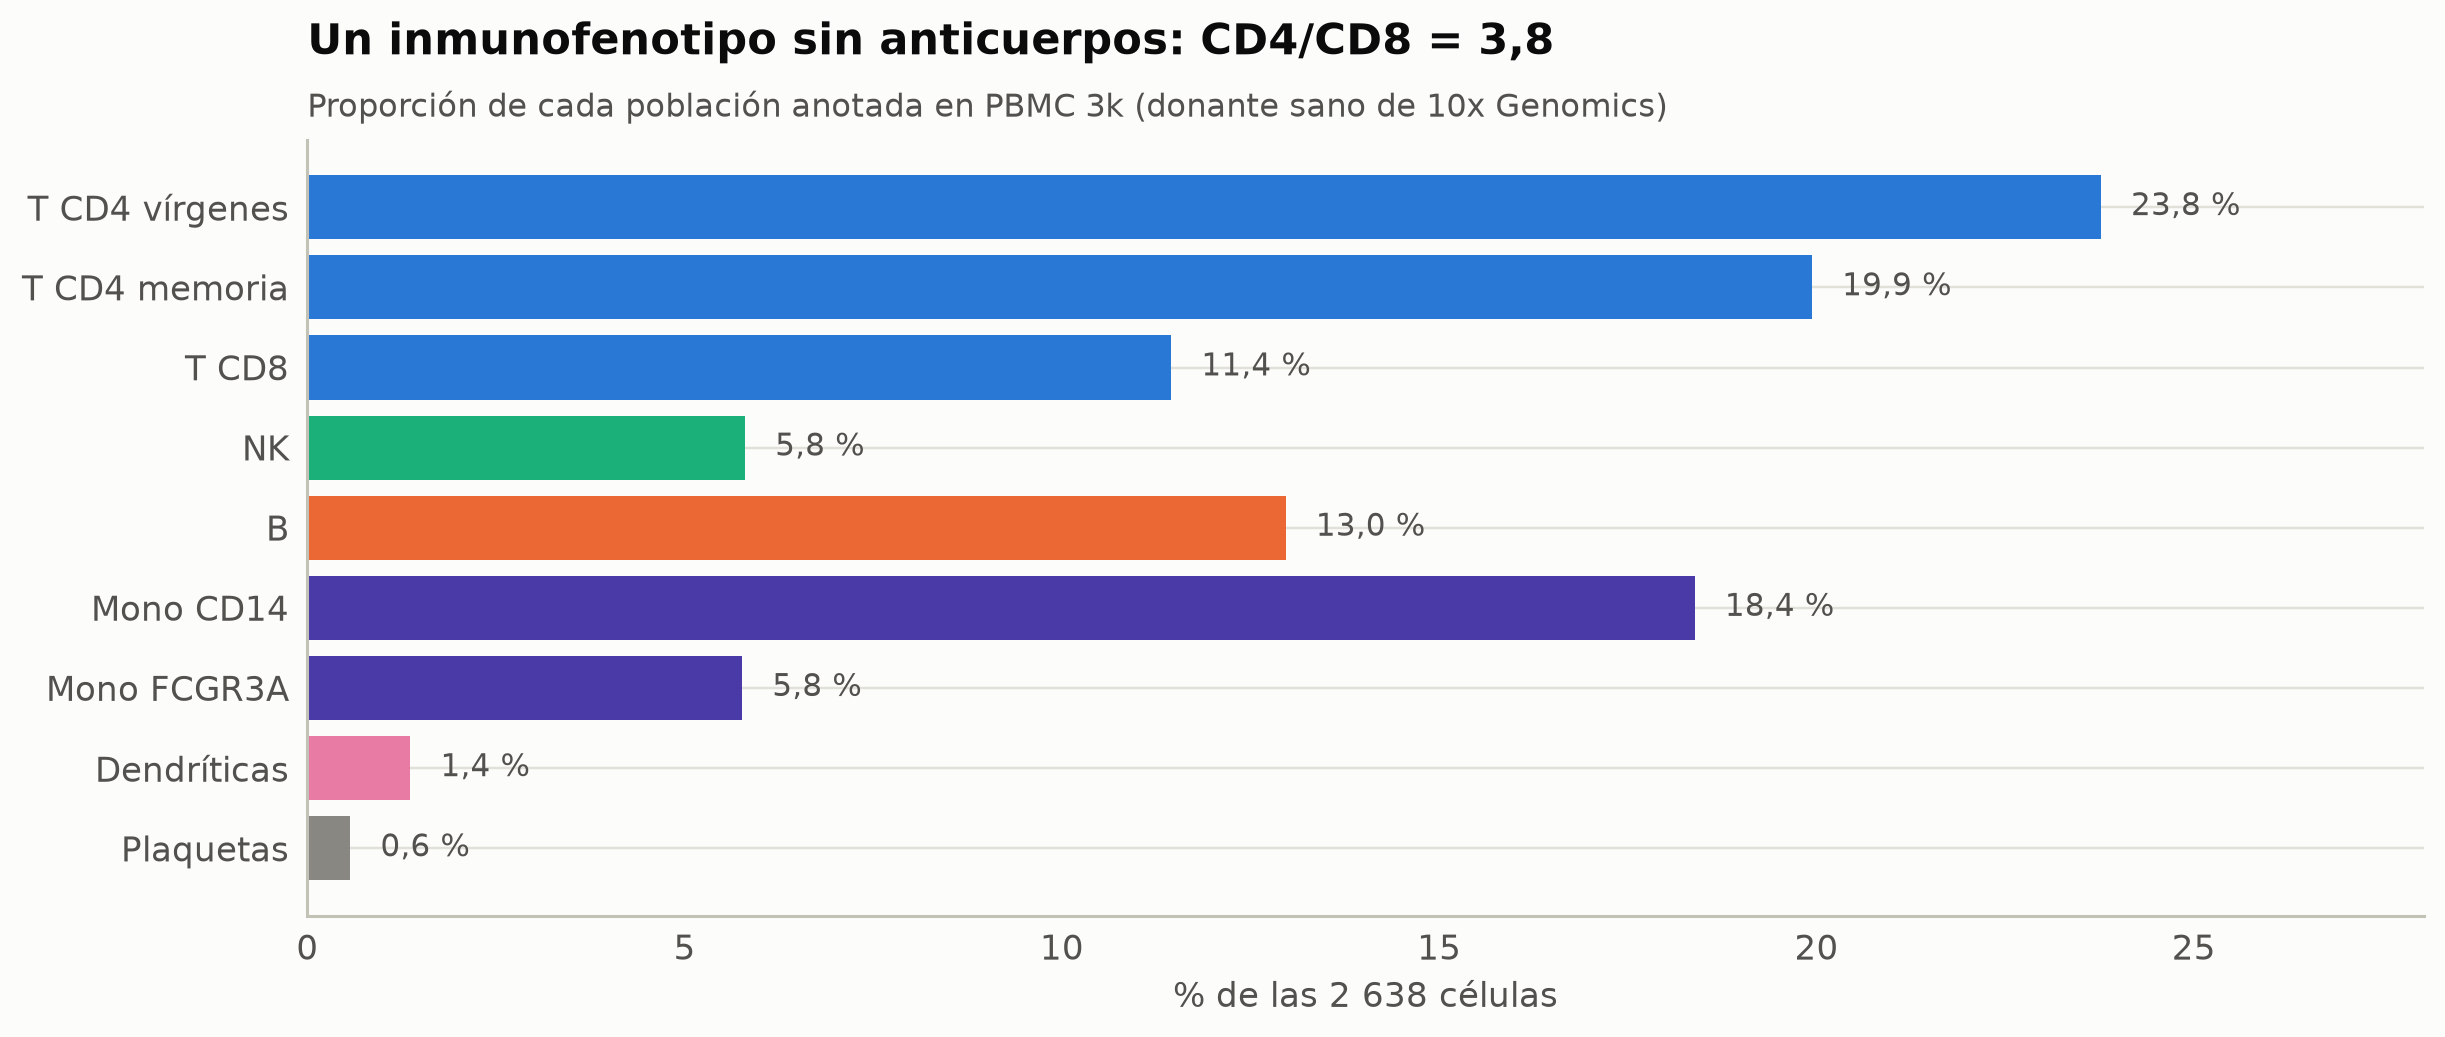

In [38]:
prop = adata.obs["cell_type"].value_counts(normalize=True).reindex(list(MARKERS)) * 100
lineage = {"T CD4 vírgenes": "T", "T CD4 memoria": "T", "T CD8": "T", "NK": "NK", "B": "B",
           "Mono CD14": "Monocitos", "Mono FCGR3A": "Monocitos", "Dendríticas": "Dendríticas", "Plaquetas": "Plaquetas"}
by_lin = prop.groupby(pd.Series(lineage)).sum().reindex(["T", "B", "NK", "Monocitos", "Dendríticas", "Plaquetas"])
cd4 = prop["T CD4 vírgenes"] + prop["T CD4 memoria"]
print(by_lin.round(1).to_string())
print(f"\nCociente T CD4 / T CD8 = {cd4 / prop['T CD8']:.2f}")

fig, ax = plt.subplots(figsize=(11, 4.6))
colors = [ec.BLUE, ec.BLUE, ec.BLUE, ec.AQUA, ec.ORANGE, ec.VIOLET, ec.VIOLET, ec.MAGENTA, ec.MUTED]
bars = ax.barh(prop.index[::-1], prop.values[::-1], color=colors[::-1])
for b, v in zip(bars, prop.values[::-1]):
    ax.text(v + 0.4, b.get_y() + b.get_height() / 2, f"{v:.1f} %".replace(".", ","), va="center", fontsize=10,
            color=ec.INK_2)
ax.set_xlabel("% de las 2 638 células"); ax.set_xlim(0, prop.max() * 1.18)
ec.title(ax, f"Un inmunofenotipo sin anticuerpos: CD4/CD8 = {cd4 / prop['T CD8']:.1f}".replace(".", ","),
         "Proporción de cada población anotada en PBMC 3k (donante sano de 10x Genomics)")
plt.show()

> 🔎 **Qué observamos.** Los linfocitos T son la población mayoritaria, seguidos de los monocitos; B y NK están en el
> rango habitual, y las dendríticas y las plaquetas son minoritarias. El cociente CD4/CD8, que en clínica se usa para
> seguir la infección por VIH (en adultos sanos suele estar por encima de 1), es coherente con un donante sano; el valor obtenido (≈ 3,8) es algo alto
> frente a los valores clínicos habituales, en parte porque algunos T CD8 quedan dentro de los grupos CD4 y porque aquí
> contamos perfiles de ARN, no proteína de superficie. Dos advertencias más: (1) las proporciones en célula única están sesgadas por la eficiencia de captura de cada tipo y por el
> QC (los monocitos, más grandes y frágiles, pueden perderse o dar más ARN mitocondrial); (2) las «plaquetas» no son
> células sino fragmentos que se colaron en el preparado o que viajan pegados a monocitos.

### 8.5 Explore las células anotadas (interactivo)

El menú permite colorear el UMAP por población o por la expresión de un marcador. **Pase el cursor** por las células
para ver su grupo, su número de UMI y de genes detectados.

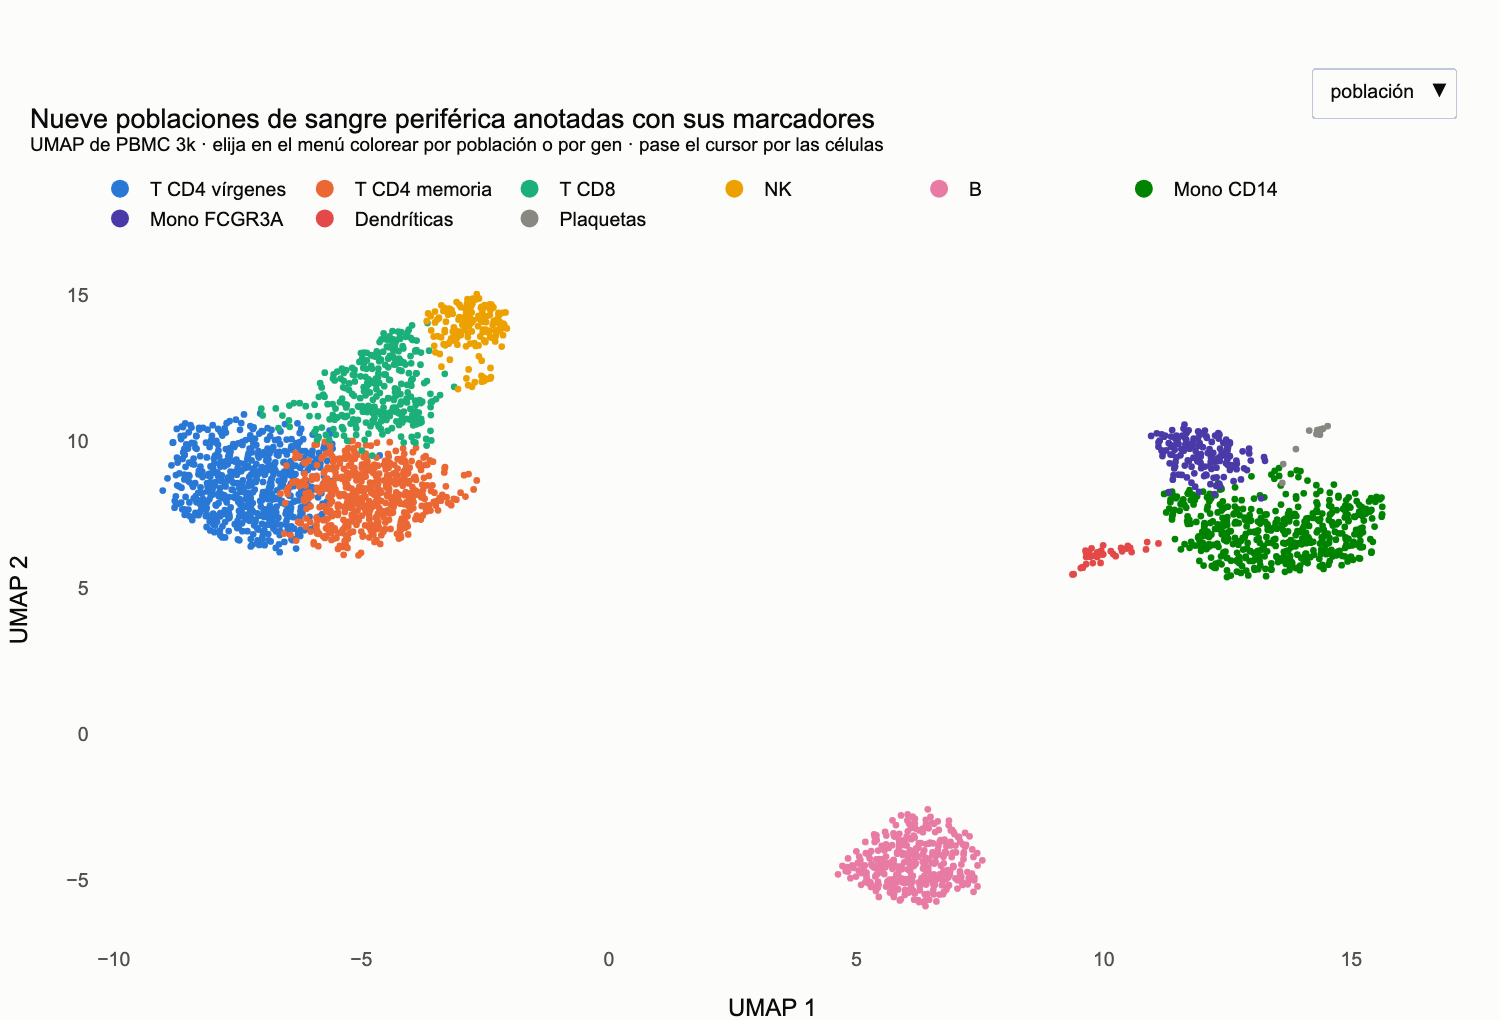

In [39]:
genes_show = ["CD3E", "CCR7", "CD8A", "NKG7", "MS4A1", "CD14", "FCGR3A", "FCER1A", "PPBP"]
Xs = adata.raw[:, genes_show].X.toarray()
ct = adata.obs["cell_type"].astype(str).values
hover = np.column_stack([ct, lab_leiden, adata.obs.total_counts.astype(int), adata.obs.n_genes_by_counts])
htpl = ("<b>%{customdata[0]}</b> (grupo %{customdata[1]})<br>UMI: %{customdata[2]} · genes: %{customdata[3]}")
fig = go.Figure()
type_colors = dict(zip(MARKERS, ec.CATEGORICAL + ["#898781"]))
for t in MARKERS:
    m = ct == t
    fig.add_trace(go.Scatter(x=U_pb[m, 0], y=U_pb[m, 1], mode="markers", name=t,
                               marker=dict(size=4.5, color=type_colors[t]), customdata=hover[m],
                               hovertemplate=htpl + "<extra></extra>"))
n_type = len(MARKERS)
for j, g in enumerate(genes_show):
    fig.add_trace(go.Scatter(x=U_pb[:, 0], y=U_pb[:, 1], mode="markers", name=g, visible=False, showlegend=False,
                               marker=dict(size=4.5, color=Xs[:, j], colorscale="Blues", cmin=0,
                                           colorbar=dict(title=f"{g}<br>log-norm", thickness=12)),
                               customdata=np.column_stack([hover, Xs[:, j]]),
                               hovertemplate=htpl + f"<br><i>{g}</i> = " + "%{customdata[4]:.2f}<extra></extra>"))
n_tr = n_type + len(genes_show)
buttons = [dict(label="población", method="update",
                args=[{"visible": [True] * n_type + [False] * len(genes_show)}, {"showlegend": True}])]
for j, g in enumerate(genes_show):
    vis = [False] * n_tr; vis[n_type + j] = True
    buttons.append(dict(label=g, method="update", args=[{"visible": vis}, {"showlegend": False}]))
fig.update_layout(
    updatemenus=[dict(buttons=buttons, x=1.0, xanchor="right", y=1.2, yanchor="bottom")],
    title="Nueve poblaciones de sangre periférica anotadas con sus marcadores<br>"
          "<sup>UMAP de PBMC 3k · elija en el menú colorear por población o por gen · pase el cursor por las células</sup>",
    xaxis=dict(title="UMAP 1", showgrid=False, zeroline=False), yaxis=dict(title="UMAP 2", showgrid=False, zeroline=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, itemsizing="constant"), height=680,
    margin=dict(t=170, l=60, r=30, b=50))
fig.show()

> 🔎 **Qué observamos.** Al cambiar entre genes se ve la lógica de la anotación: *CD3E* ilumina toda la región de los T;
> *CCR7* sólo una parte (vírgenes); *NKG7* cubre NK **y** parte de los T CD8; *MS4A1*, *CD14*, *FCGR3A*, *FCER1A* y
> *PPBP* señalan islas bien delimitadas. Explore también las células con pocos UMI en las fronteras: son las más
> difíciles de asignar.

### 8.6 Anotación por referencia

La anotación manual no escala a atlas de cientos de tipos ni es del todo reproducible. La alternativa es la
**anotación por referencia**: proyectar las células nuevas sobre un atlas ya anotado y transferir las etiquetas de sus
vecinas. Seurat v4 construyó así un atlas multimodal de sangre, combinando ARN y proteínas de superficie medidas en las
mismas células, y lo usa como referencia para anotar conjuntos nuevos (Hao *et al.*, 2021). Cualquiera de los dos
caminos requiere juicio: una referencia no puede asignar un tipo que no contiene, y un marcador «de libro» puede no
expresarse en otra especie o en otro tejido.

> ✅ **Compruebe su comprensión.** Un grupo tiene AUC alto para *NKG7* y *GNLY*, pero también para *CD3E* y *CD8A*.
> ¿Es NK o T CD8? ¿Qué gen miraría para decidir? (Pista: ¿cuál de los dos tipos tiene receptor de linfocitos T?)

## 9. Efectos de lote e integración

### 9.1 El problema

Cuando se combinan muestras procesadas en días, canales o laboratorios distintos, aparecen diferencias sistemáticas que
no tienen que ver con la biología: son los **efectos de lote**. Piense en un estudio clínico que recoge sangre de
pacientes en tres hospitales: cada centro tiene su centrífuga, su tiempo entre extracción y procesamiento, su lote de
reactivos. En el espacio de PC, las células de un mismo tipo pero de lotes distintos forman grupos separados, y el
agrupamiento las divide **por lote** en lugar de por tipo. Los métodos de **integración** buscan una representación en
la que el lote se mezcle y el tipo celular se conserve.

### 9.2 Harmony

Harmony (Korsunsky *et al.*, 2019) trabaja directamente sobre las coordenadas de PC, alternando dos pasos hasta
converger:

1. **Agrupamiento difuso con penalización de diversidad.** Cada célula $i$ recibe una pertenencia $R_{ki}$ a cada uno
   de $K$ grupos, que favorece los grupos cercanos y, a la vez, penaliza los grupos donde el lote de $i$ está
   sobrerrepresentado:

$$
R_{ki}\;\propto\;\exp\!\left(-\frac{\lVert \hat z_i-y_k\rVert^2}{\sigma}\right)\prod_{b}\left(\frac{E_{kb}+1}{O_{kb}+1}\right)^{\theta\,\phi_{ib}}.
$$

2. **Corrección lineal por grupo.** En cada grupo $k$ se ajusta, ponderando por $R_{ki}$, una regresión de las
   coordenadas sobre el lote, y se resta a cada célula la mezcla de los efectos de lote de sus grupos:
   $\hat z_i \leftarrow z_i-\sum_k R_{ki}\,\beta_k^{\top}\phi_i$.

| Símbolo | Significado |
|---|---|
| $\hat z_i$, $y_k$ | coordenadas (normalizadas) de la célula $i$ y centroide del grupo $k$ |
| $O_{kb}$, $E_{kb}$ | número observado y esperado (según la proporción global del lote) de células del lote $b$ en el grupo $k$ |
| $\phi_{ib}$ | indicador de que la célula $i$ pertenece al lote $b$ |
| $\theta$, $\sigma$ | fuerza de la penalización de diversidad y suavidad del agrupamiento |
| $\beta_k$ | efectos de lote estimados dentro del grupo $k$ |

El truco está en que la corrección es **local**: un lote puede desplazar a los monocitos en una dirección y a los
linfocitos en otra, y Harmony estima un desplazamiento por grupo. La penalización de diversidad evita la solución
trivial en la que cada grupo contiene un solo lote y, por tanto, no hay nada que corregir: si en un grupo hay el doble
de células del lote 1 de lo esperado, el factor $(E+1)/(O+1)\approx1/2$, elevado a $\theta$, reduce la pertenencia de
las células del lote 1 a ese grupo.

Usamos el experimento del libro: dos lotes simulados de 1 500 células, con los mismos tipos pero con un efecto de lote
multiplicativo aleatorio sobre cada gen (desviación estándar 0,45 en escala logarítmica), y la versión didáctica de
Harmony del libro ($K=20$, $\theta=2$, $\sigma=0{,}1$).

> 🤔 **Antes de ejecutar, prediga.** Si el efecto de lote se corrige perfectamente, ¿qué fracción de las 30 vecinas
> de cada célula debería pertenecer al **otro** lote?

In [40]:
pB, TB, BB = sim["pB"], sim["TB"].astype(int), sim["BB"].astype(int)

def mixing(Z, b, k=30):
    """Fracción media de vecinas (k) que pertenecen a otro lote."""
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(Z)[1][:, 1:]
    return np.mean(b[idx] != b[:, None])

def harmony_simple(Z, b, K=20, theta=2.0, sigma=0.1, it=10, lam=1.0, seed=0):
    """Versión didáctica de Harmony (la del libro): k-medias difuso con penalización de diversidad
    + corrección lineal por mezcla de expertos."""
    rng = np.random.default_rng(seed)
    nb_ = b.max() + 1
    Phi = np.eye(nb_)[b]                          # n × B: indicadores de lote φ_ib
    Pr = Phi.mean(0)                              # proporción global de cada lote
    Zc = Z.copy()
    for _ in range(it):
        Zn = Zc / np.linalg.norm(Zc, axis=1, keepdims=True)
        Yk = Zn[rng.choice(len(Zn), K, replace=False)]
        for _ in range(15):
            d = 2 * (1 - Zn @ Yk.T)               # distancia coseno a cada centroide y_k
            Rk = np.exp(-d / sigma)
            Rk /= Rk.sum(1, keepdims=True)
            O = Rk.T @ Phi                        # K × B observado
            Ex = Rk.sum(0)[:, None] * Pr[None]    # K × B esperado
            pen = ((Ex + 1) / (O + 1)) ** theta   # penalización de diversidad
            Rk = Rk * (pen @ Phi.T).T
            Rk /= Rk.sum(1, keepdims=True)
            Yk = Rk.T @ Zn
            Yk /= np.linalg.norm(Yk, axis=1, keepdims=True)
        Phi1 = np.c_[np.ones(len(Z)), Phi]
        corr = np.zeros_like(Z)
        for k in range(K):                        # regresión ponderada por R_ki en cada grupo
            Wk = Rk[:, k]
            A_ = Phi1.T @ (Phi1 * Wk[:, None]) + lam * np.diag(np.r_[0, np.ones(nb_)])
            beta = np.linalg.solve(A_, Phi1.T @ (Z * Wk[:, None]))
            beta[0] = 0                           # no se toca el intercepto (la biología)
            corr += Wk[:, None] * (Phi1 @ beta)
        Zc = Z - corr
    return Zc

t0 = time.time()
pBh = harmony_simple(pB, BB)
print(f"Harmony didáctico: {time.time() - t0:.1f} s")
mz0, mz1 = mixing(pB, BB), mixing(pBh, BB)
l0 = nx_louvain(nx.from_scipy_sparse_array(knn_graph(pB, 15)[0]), 0.5)
l1 = nx_louvain(nx.from_scipy_sparse_array(knn_graph(pBh, 15)[0]), 0.5)
print(f"Fracción de vecinas del otro lote (ideal 0,5): antes = {mz0:.3f}   después = {mz1:.3f}")
print(f"ARI de Louvain frente a los tipos: antes = {adjusted_rand_score(TB, l0):.3f}   después = {adjusted_rand_score(TB, l1):.3f}")
print(f"ARI de Louvain frente al lote:     antes = {adjusted_rand_score(BB, l0):.3f}   después = {adjusted_rand_score(BB, l1):.3f}")

Harmony didáctico: 0.1 s


Fracción de vecinas del otro lote (ideal 0,5): antes = 0.001   después = 0.502
ARI de Louvain frente a los tipos: antes = 0.382   después = 0.816
ARI de Louvain frente al lote:     antes = 0.360   después = 0.000


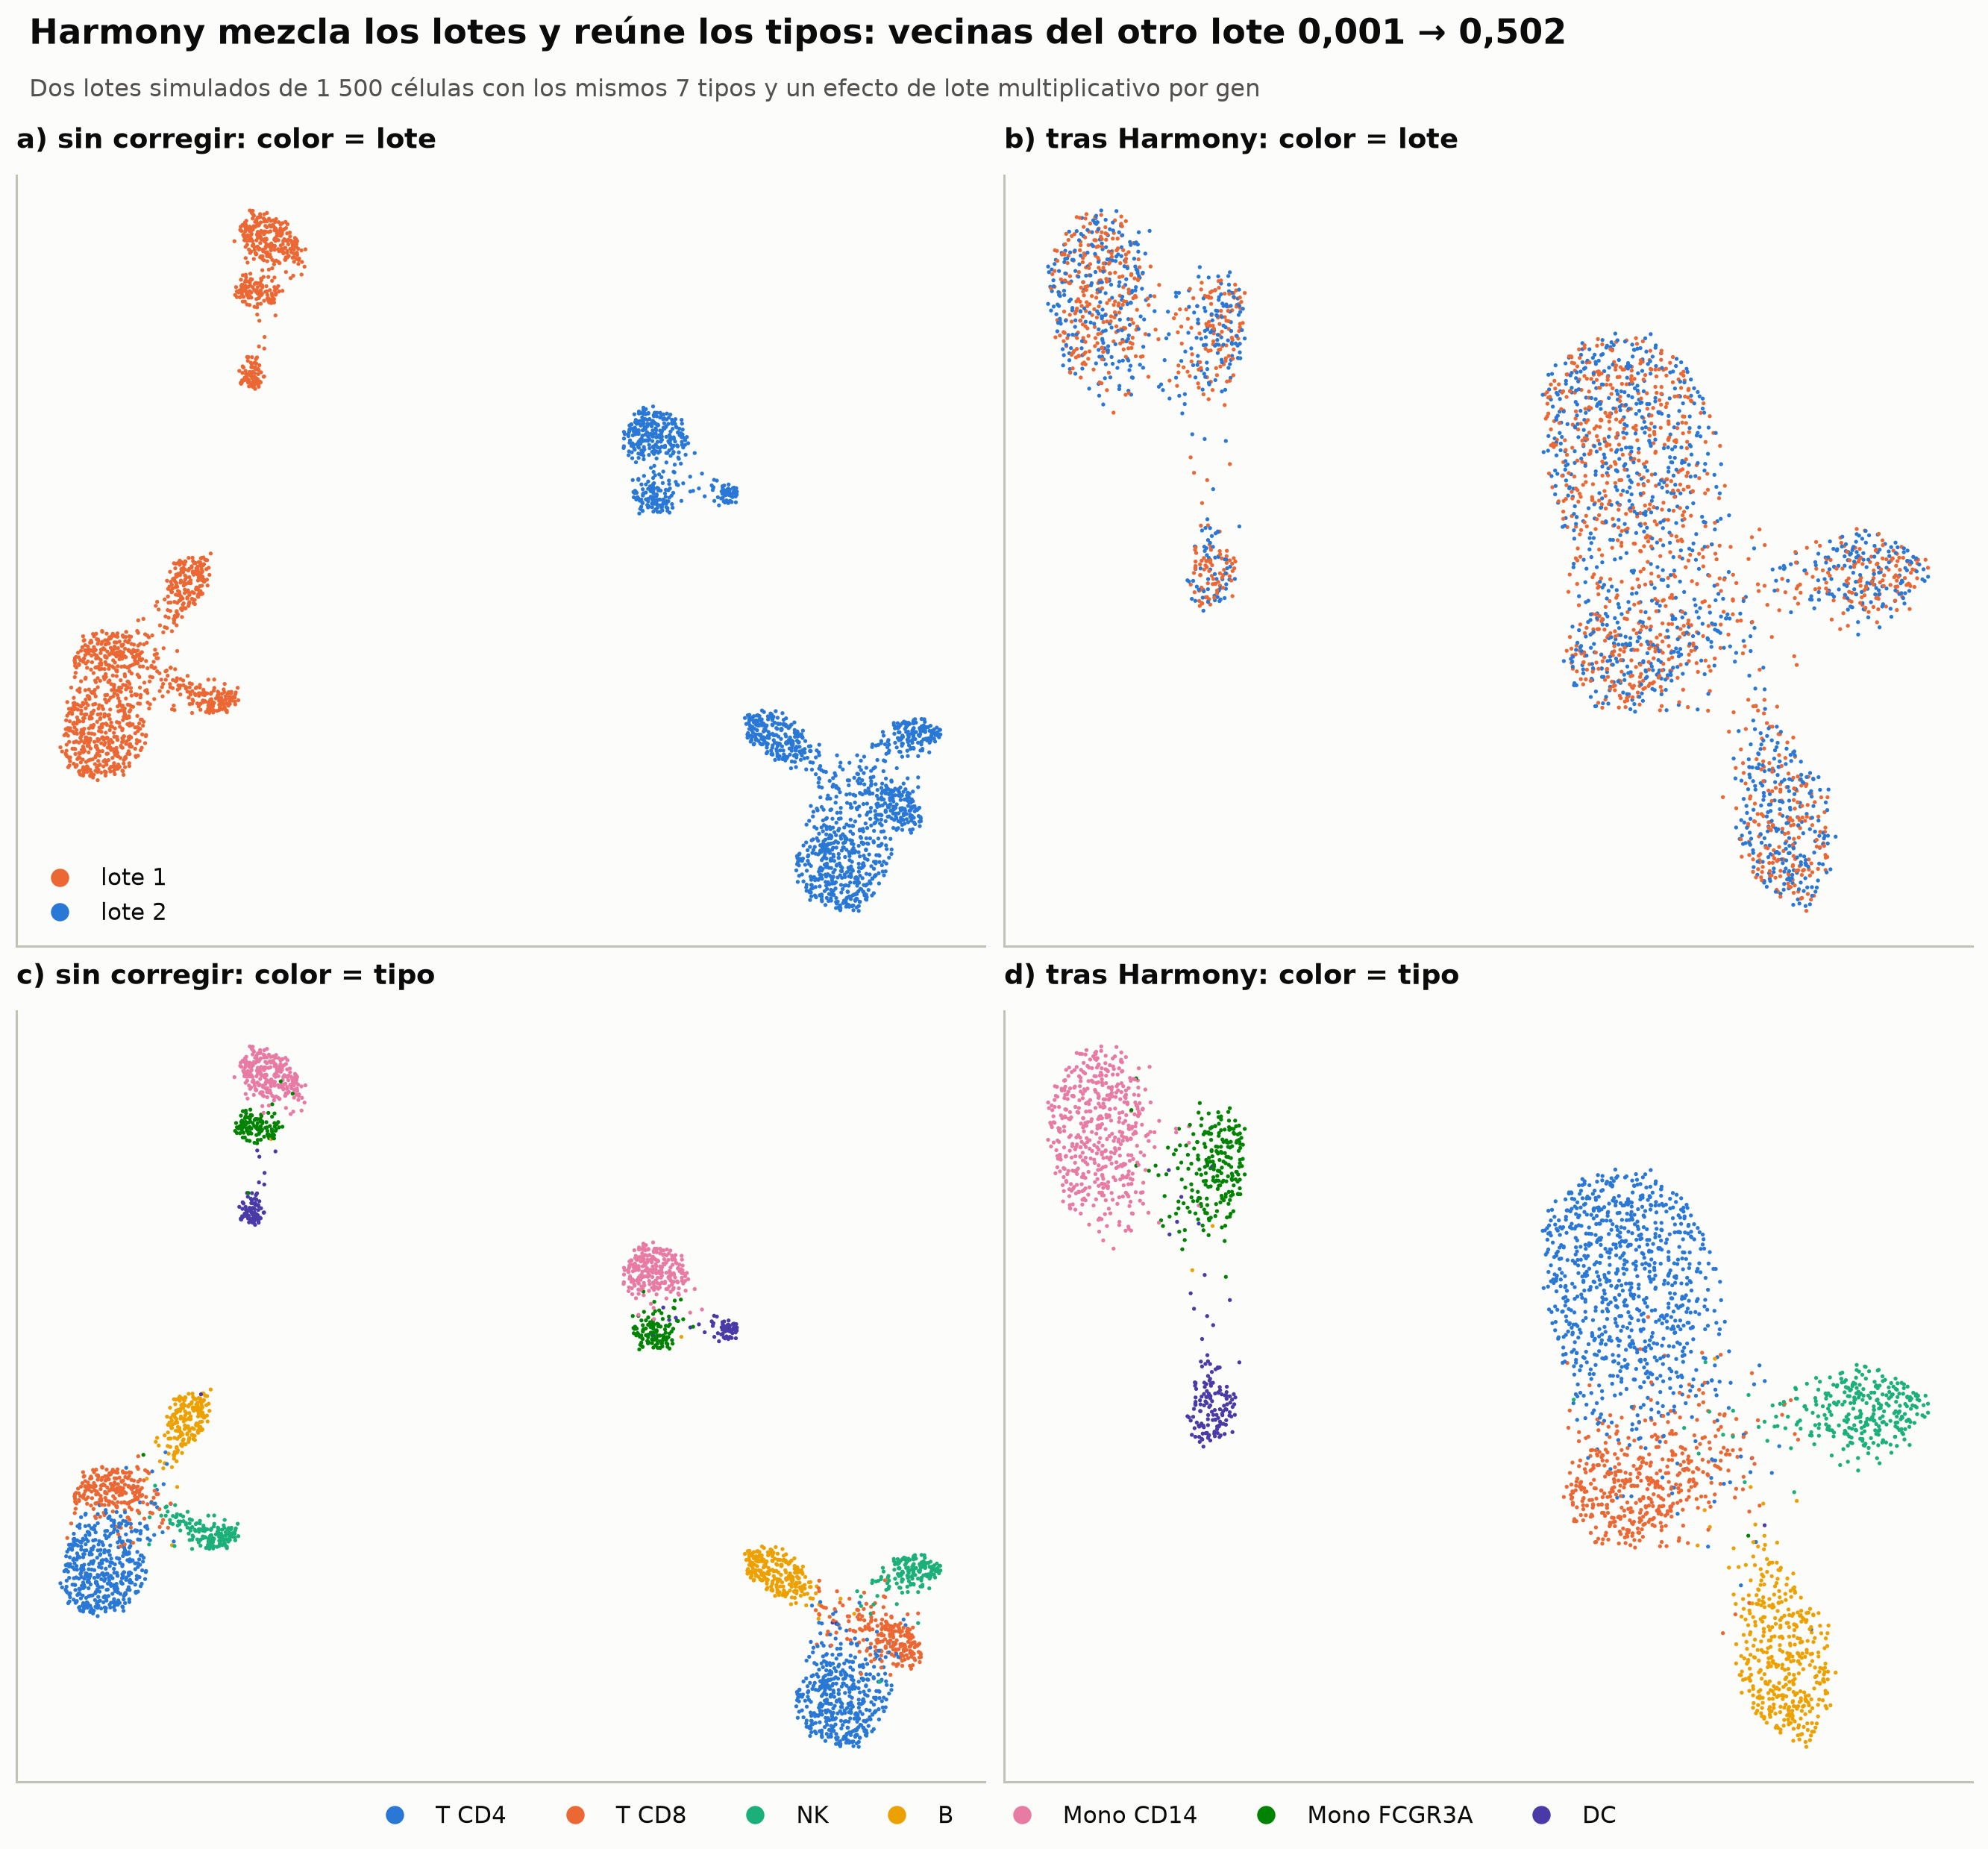

In [41]:
UB0, UB1 = sim["UB0"], sim["UB1"]                 # UMAP de las PC sin corregir y corregidas (del libro)
fig, axs = plt.subplots(2, 2, figsize=(12, 10.5))
o = np.random.default_rng(1).permutation(len(BB))
batch_col = np.array([ec.ORANGE, ec.BLUE])
for j, (UU, name) in enumerate(((UB0, "sin corregir"), (UB1, "tras Harmony"))):
    axs[0, j].scatter(UU[o, 0], UU[o, 1], s=3, lw=0, c=batch_col[BB[o]])
    axs[1, j].scatter(UU[o, 0], UU[o, 1], s=3, lw=0, c=[ec.CATEGORICAL[t] for t in TB[o]])
    axs[0, j].set_title(f"{'ab'[j]}) {name}: color = lote", loc="left", fontsize=12)
    axs[1, j].set_title(f"{'cd'[j]}) {name}: color = tipo", loc="left", fontsize=12)
for ax in axs.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axs[0, 0].legend(handles=[Line2D([], [], marker="o", ls="", color=batch_col[i], label=f"lote {i + 1}") for i in (0, 1)],
                 loc="lower left", frameon=False)
fig.legend(handles=[Line2D([], [], marker="o", ls="", color=ec.CATEGORICAL[i], label=t) for i, t in enumerate(TYPES)],
           loc="outside lower center", ncol=7, frameon=False)
ec.fig_title(fig, f"Harmony mezcla los lotes y reúne los tipos: vecinas del otro lote {mz0:.3f} → {mz1:.3f}".replace(".", ","),
             "Dos lotes simulados de 1 500 células con los mismos 7 tipos y un efecto de lote multiplicativo por gen")
plt.show()

> 🔎 **Qué observamos.** Sin corregir **(a, c)**, cada tipo aparece **duplicado**: una isla por lote. La fracción de
> vecinas del otro lote es prácticamente 0 (0,001), y Louvain agrupa en buena medida por lote (ARI frente al lote
> ≈ 0,36; frente al tipo, sólo ≈ 0,38). Tras Harmony **(b, d)**, los lotes se mezclan (0,502, casi el ideal de 0,5) y
> los tipos se reúnen: el ARI frente a los tipos sube a ≈ 0,82 y frente al lote cae a 0. Las cifras reproducen las del
> libro.

> ⚠️ **Cuidado: corregir de más.** Un método de integración no sabe distinguir un efecto de lote de un efecto biológico
> que coincide con el lote. Si todas las muestras de pacientes se procesaron en un lote y todos los controles en otro,
> la integración borrará también la enfermedad. El diseño experimental (repartir condiciones entre lotes) es la única
> defensa real. Además, las coordenadas corregidas sirven para agrupar y visualizar, pero la expresión diferencial debe
> hacerse sobre las cuentas originales, incluyendo el lote como covariable.

> ✅ **Compruebe su comprensión.** ¿Qué pasaría con la penalización de diversidad si $\theta=0$? ¿Y si un tipo celular
> sólo existe en uno de los lotes (por ejemplo, células tumorales sólo en el paciente)?

## 🧰 El flujo en producción (recuadro `clustering.py` del libro)

Todo lo que programamos desde cero cabe, en el día a día, en unas pocas líneas de Scanpy. La integración con Harmony
requiere el paquete `harmonypy` y, además, que el objeto tenga una columna `lote`; por eso la dejamos comentada.

   names     scores  logfoldchanges          pvals      pvals_adj
0  RPS12  24.391495        0.902058  2.105217e-131  2.874885e-127
1  RPS27  23.633152        0.899511  1.759081e-123  1.201101e-119
2  RPL32  23.559649        0.718198  9.997467e-123  4.550847e-119
3   RPS6  23.297640        0.784472  4.684395e-120  1.599253e-116
4  RPS25  22.433033        0.966758  1.874141e-111  4.265545e-108
5  RPS14  22.245550        0.705338  1.245575e-109  2.429939e-106
6   RPL9  21.874214        0.998177  4.573166e-106  7.806395e-103
7  RPL31  21.748434        0.981212  7.147704e-105  1.084545e-101
8  RPL13  21.516932        0.673531  1.080810e-102   1.341776e-99
9  RPLP2  21.412020        0.768548  1.032381e-101   1.174849e-98


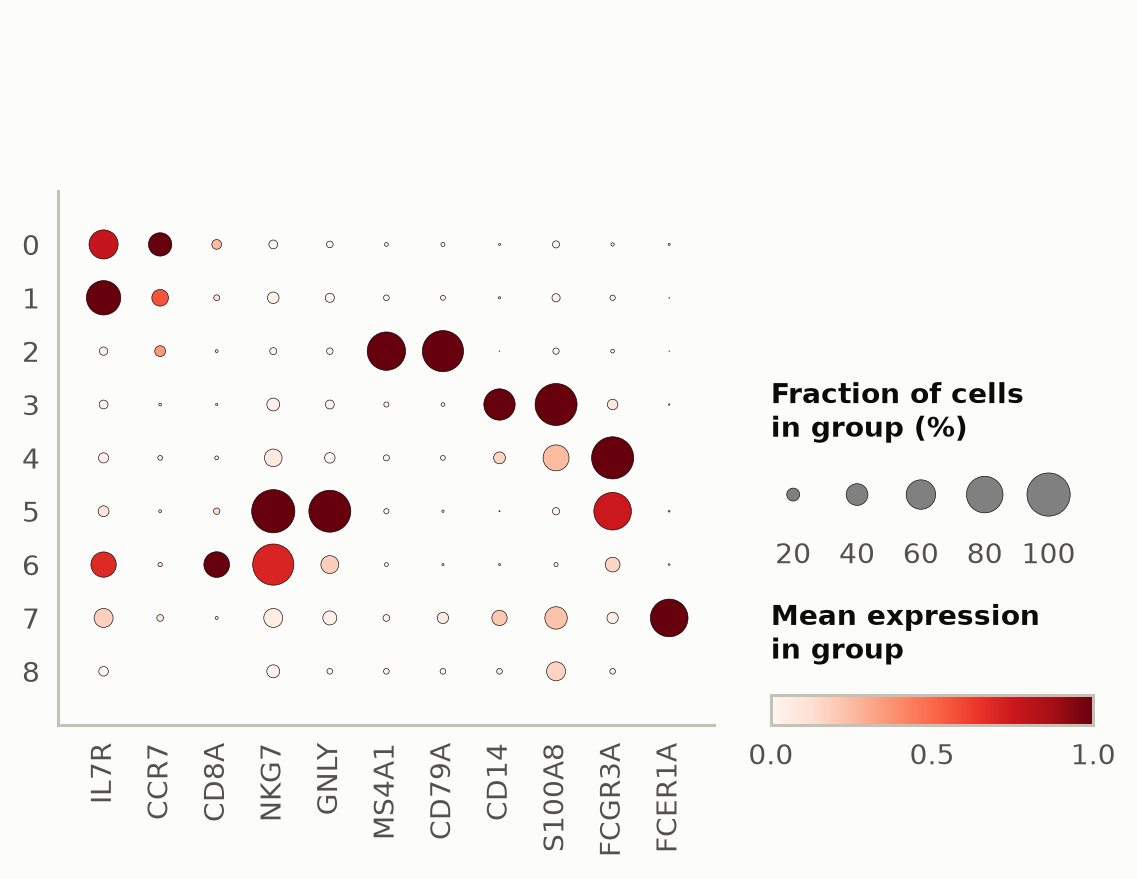

In [42]:
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, key_added="leiden", random_state=0)
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
print(sc.get.rank_genes_groups_df(adata, group="0").head(10))
marcadores = ["IL7R", "CCR7", "CD8A", "NKG7", "GNLY", "MS4A1",
              "CD79A", "CD14", "S100A8", "FCGR3A", "FCER1A"]
sc.pl.dotplot(adata, marcadores, groupby="leiden", standard_scale="var", show=False)
plt.show()
# integración de lotes (requiere el paquete harmonypy y una columna adata.obs["lote"])
# sc.external.pp.harmony_integrate(adata, key="lote")
# sc.pp.neighbors(adata, use_rep="X_pca_harmony")
# sc.tl.umap(adata)

## 10. ✍️ Ejercicios

**Ejercicio 1 (SNN a mano).** Con las siete células A–G de la sección 3.2 y $k=3$: (a) escriba $\mathcal{N}_3$ de cada
célula; (b) calcule los pesos de Jaccard de las aristas A–B y B–G; (c) ¿sigue siendo G un puente de peso nulo? Compruebe
con `neighbor_sets` y `jaccard`.

In [43]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
N3, _ = neighbor_sets(toy_xy, k=3)
print({toy_names[i]: "".join(sorted(toy_names[x] for x in N3[i])) for i in range(7)})
iA, iB, iG = 0, 1, 6
for i, j in [(iA, iB), (iB, iG), (3, iG)]:
    print(f"{toy_names[i]}–{toy_names[j]}: comunes = {sorted(toy_names[x] for x in N3[i] & N3[j])}, "
          f"|unión| = {len(N3[i] | N3[j])}, w = {jaccard(N3[i], N3[j]):.3f}")
# Con k = 3 cada célula de un triángulo debe elegir una tercera vecina fuera de él, y la más cercana es G:
# G pasa a ser vecina común de todos. A–B sube a 0,5 (comparten C y G), D–G ya pesa 0,2 y B–G sigue en 0.
# Un k demasiado grande para el tamaño de los grupos llena el grafo de aristas hacia las células puente
# y empieza a «pegar» poblaciones distintas (recuerde la fiesta con grupos de 10).

{'A': 'BCG', 'B': 'ACG', 'C': 'ABG', 'D': 'EFG', 'E': 'DFG', 'F': 'DEG', 'G': 'BDF'}
A–B: comunes = ['C', 'G'], |unión| = 4, w = 0.500
B–G: comunes = [], |unión| = 6, w = 0.000
D–G: comunes = ['F'], |unión| = 5, w = 0.200


**Ejercicio 2 (fabricar una comunidad desconectada).** Construya este grafo ponderado: un triángulo $\{a_1,a_2,b\}$,
otro $\{b,c_1,c_2\}$ que comparte el nodo $b$ (aristas de peso 1), un triángulo $D=\{d_1,d_2,d_3\}$ (peso 1) y aristas
de peso 2 entre $b$ y cada nodo de $D$ ($b$ comparte muchas vecinas con $D$). (a) Calcule $Q_1$ de la partición $C=\{a_1,a_2,b,c_1,c_2\}$, $D$. (b) Calcule $\Delta Q$ de mover
$b$ a $D$ (use `delta_q`) y la nueva $Q_1$. (c) ¿Cuántos trozos conexos tiene ahora $C$? (d) ¿Qué partición mejoraría
aún más $Q$? Explique por qué una fase de agregación posterior no la encontraría y cómo lo evita Leiden.

In [44]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
names2 = ["a1", "a2", "b", "c1", "c2", "d1", "d2", "d3"]
E2 = [("a1", "a2", 1), ("a1", "b", 1), ("a2", "b", 1), ("b", "c1", 1), ("b", "c2", 1), ("c1", "c2", 1),
      ("d1", "d2", 1), ("d1", "d3", 1), ("d2", "d3", 1), ("b", "d1", 2), ("b", "d2", 2), ("b", "d3", 2)]
A2 = np.zeros((8, 8))
for u, v, w in E2:
    A2[names2.index(u), names2.index(v)] = A2[names2.index(v), names2.index(u)] = w
k2 = A2.sum(1); m2 = k2.sum() / 2
p_a = np.array([0, 0, 0, 0, 0, 1, 1, 1])
p_b = np.array([0, 0, 1, 0, 0, 1, 1, 1])                          # b se muda a D
p_c = np.array([0, 0, 1, 2, 2, 1, 1, 1])                          # y C se parte en sus dos trozos
ib = names2.index("b")
Sigma_D = k2[5:].sum()
dq_leave = -delta_q(4, k2[[0, 1, 3, 4]].sum(), k2[ib], m2)       # salir de C (4 aristas a a1, a2, c1, c2)
dq_join = delta_q(6, Sigma_D, k2[ib], m2)                         # entrar en D (peso 2 + 2 + 2)
print(f"(a) Q_1(C, D) = {modularity(A2, p_a):.4f}")
print(f"(b) ΔQ(salir de C) + ΔQ(entrar en D) = {dq_leave:+.4f} {dq_join:+.4f} = {dq_leave + dq_join:+.4f};"
      f"  nueva Q_1 = {modularity(A2, p_b):.4f}")
sub_C = np.where(p_b == 0)[0]
print("(c) trozos conexos de C sin b:", sparse.csgraph.connected_components(sparse.csr_matrix(A2[np.ix_(sub_C, sub_C)]))[0])
print(f"(d) partir C en {{a1,a2}} y {{c1,c2}}: Q_1 = {modularity(A2, p_c):.4f}")
# Tras la agregación, C viaja como UN supernodo y nunca se vuelve a partir: Louvain no puede separar sus
# dos trozos. Leiden refina cada comunidad en subcomunidades bien conectadas ANTES de agregar, y detecta que
# {a1,a2} y {c1,c2} no tienen ninguna arista entre sí.

(a) Q_1(C, D) = 0.0800
(b) ΔQ(salir de C) + ΔQ(entrar en D) = -0.0889 +0.1333 = +0.0444;  nueva Q_1 = 0.1244
(c) trozos conexos de C sin b: 2
(d) partir C en {a1,a2} y {c1,c2}: Q_1 = 0.1600


**Ejercicio 3 (Wilcoxon a mano).** Un gen tiene, en cuatro células de un grupo, los valores 0; 0; 1,2 y 3,1, y en seis
de fuera, 0; 0; 0; 0,5; 0,9 y 0. Calcule a mano los rangos, $R_1$, $U$, el AUC y $\mathrm{Var}[U]$ con la corrección
por empates. Compruebe con `scipy.stats.mannwhitneyu`. ¿Es este gen mejor o peor marcador que el del ejemplo del libro?

In [45]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
a = np.array([0, 0, 1.2, 3.1]); b = np.array([0, 0, 0, 0.5, 0.9, 0])
r = stats.rankdata(np.r_[a, b]); n1, n2 = len(a), len(b); N = n1 + n2
R1 = r[:n1].sum(); U = R1 - n1 * (n1 + 1) / 2
tie = 6 ** 3 - 6                                   # un único grupo de 6 ceros
varU = n1 * n2 / 12 * ((N + 1) - tie / (N * (N - 1)))
print("rangos:", r.tolist())                       # los 6 ceros → rango medio 3,5
print(f"R1 = {R1}, U = {U}, AUC = {U / (n1 * n2):.3f}, Var[U] = {varU:.3f}, "
      f"z = {(U - n1 * n2 / 2) / np.sqrt(varU):.3f}")
print("scipy:", stats.mannwhitneyu(a, b, alternative="two-sided").statistic)
# AUC = 16/24 ≈ 0,667 < 0,825: peor marcador; la mitad de las células del grupo no lo detecta.

rangos: [3.5, 3.5, 9.0, 10.0, 3.5, 3.5, 3.5, 7.0, 8.0, 3.5]
R1 = 26.0, U = 16.0, AUC = 0.667, Var[U] = 17.333, z = 0.961
scipy: 16.0


**Ejercicio 4 (estabilidad frente a la semilla).** Ejecute Leiden sobre PBMC 3k con cinco semillas distintas
(`random_state=0…4`) para $\gamma\in\{0{,}3;\,1;\,2{,}5\}$ y calcule el ARI medio entre todos los pares de
particiones. ¿Qué resolución da particiones más estables? ¿Cómo encaja con la idea de «meseta» de la sección 6?

In [46]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
from itertools import combinations
for g in (0.3, 1.0, 2.5):
    parts_s = []
    for s in range(5):
        sc.tl.leiden(adata, resolution=g, flavor="igraph", n_iterations=2, random_state=s, key_added="tmp")
        parts_s.append(adata.obs["tmp"].astype(int).values)
    aris = [adjusted_rand_score(p, q) for p, q in combinations(parts_s, 2)]
    print(f"γ = {g}: grupos = {[int(p.max() + 1) for p in parts_s]}, ARI medio entre semillas = {np.mean(aris):.3f}")
del adata.obs["tmp"]
# Las resoluciones altas trocean el continuo de los linfocitos T de maneras distintas según la semilla:
# el ARI entre semillas baja. Un grupo que cambia con la semilla no es una entidad biológica robusta.

γ = 0.3: grupos = [6, 6, 6, 6, 6], ARI medio entre semillas = 0.991


γ = 1.0: grupos = [9, 9, 9, 9, 9], ARI medio entre semillas = 0.911


γ = 2.5: grupos = [24, 26, 25, 27, 23], ARI medio entre semillas = 0.750


**Ejercicio 5 (subagrupar los linfocitos T).** Tome sólo las células anotadas como T CD4 vírgenes, T CD4 de memoria y
T CD8; recalcule los HVG, la PCA, el grafo y Leiden ($\gamma=0{,}6$) **dentro** de ese subconjunto, y busque los
marcadores de cada subgrupo con Wilcoxon. ¿Aparecen mejor separados los CD4 vírgenes (*CCR7*, *LEF1*), de memoria
(*S100A4*) y los CD8 (*CD8A*, *GZMK*)? ¿Por qué subagrupar puede revelar estructura que el análisis global no ve?

In [47]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
tsub = adata[adata.obs.cell_type.isin(["T CD4 vírgenes", "T CD4 memoria", "T CD8"])].copy()
tsub = tsub.raw.to_adata()
sc.pp.highly_variable_genes(tsub, n_top_genes=1500, flavor="seurat")
hv_t = tsub[:, tsub.var.highly_variable].copy(); sc.pp.scale(hv_t, max_value=10)
sc.tl.pca(hv_t, n_comps=30, random_state=0); tsub.obsm["X_pca"] = hv_t.obsm["X_pca"]
sc.pp.neighbors(tsub, n_neighbors=15, n_pcs=20, random_state=0)
sc.tl.leiden(tsub, resolution=0.6, flavor="igraph", n_iterations=2, random_state=0, key_added="sub")
mk_t = wilcoxon_markers(tsub.X, tsub.obs["sub"].astype(int).values, tsub.var_names.values)
print(pd.crosstab(tsub.obs["sub"], tsub.obs["cell_type"].astype(str)))
for g, d in mk_t[mk_t.log2fc > 0].sort_values("z", ascending=False).groupby("group"):
    print(f"subgrupo {g}:", ", ".join(d.gene.head(8)))
# Al quitar monocitos, B y NK, la PCA dedica sus componentes a la variación DENTRO de los T
# (virgen ↔ memoria, CD4 ↔ CD8), que en el análisis global quedaba eclipsada por las grandes diferencias entre linajes.

cell_type  T CD4 memoria  T CD4 vírgenes  T CD8
sub                                            
0                     74             502     12
1                    445             119     15
2                      7               6    275
subgrupo 0: RPL32, RPS27, RPS6, RPL13, RPS12, RPS23, RPS3A, RPS14
subgrupo 1: LTB, VIM, S100A4, S100A11, TNFRSF4, PLP2, CD52, TRADD
subgrupo 2: NKG7, CCL5, CST7, GZMA, GZMH, CTSW, GZMK, B2M


## 📌 Resumen

* Los tipos celulares no son esféricos ni del mismo tamaño: por eso se agrupa sobre un **grafo kNN** (arista si
  $j\in\mathcal{N}_k(i)$ o $i\in\mathcal{N}_k(j)$), a veces ponderado por **vecinos compartidos** (Jaccard), que quita
  peso a los puentes accidentales. En la simulación del libro: 38 688 aristas y grado medio 25,1 con $k=15$.
* La **modularidad** $Q_\gamma$ compara las aristas internas con las esperadas en un grafo aleatorio con los mismos
  grados; $\gamma$ fija la escala de la respuesta.
* **Louvain** maximiza $Q$ con movimientos locales ($\Delta Q=k_{i,C}/m-\gamma\Sigma_Ck_i/2m^2$) y agregación; lo
  programamos en unas 60 líneas y reproduce $Q\approx0{,}72$ y ARI $\approx0{,}89$. **Leiden** añade un refinamiento que
  garantiza comunidades conectadas: es el recomendado.
* La **resolución** corta la jerarquía de tipos a distinta altura; una meseta en el número de grupos sugiere estructura
  robusta, pero **un *cluster* no es un tipo celular**.
* La prueba de **Wilcoxon** da $U=R_1-n_1(n_1+1)/2$ y $\mathrm{AUC}=U/n_1n_2$ (ejemplo del libro: 16,5 y 0,825). El
  AUC mide lo buen marcador que es un gen; el valor $p$ depende del tamaño y, por el **doble uso de los datos**, sólo
  sirve para ordenar. Scanpy no corrige empates por defecto (`tie_correct=False`).
* En PBMC 3k, Leiden + Wilcoxon + marcadores canónicos recuperan nueve poblaciones (T CD4 vírgenes y de memoria, T CD8,
  NK, B, monocitos CD14 y FCGR3A, dendríticas y plaquetas): un **inmunofenotipo sin anticuerpos**, con la advertencia
  del *dropout* (*CD4* casi no se detecta en ARN).
* El ***dot plot*** muestra a la vez fracción de células y expresión media. **Harmony** corrige efectos de lote con
  un agrupamiento difuso que exige diversidad de lotes y correcciones lineales locales; no puede separar lote y biología
  si el diseño los confunde.

## 📚 Lecturas y referencias

* Blondel, V. D., Guillaume, J.-L., Lambiotte, R. y Lefebvre, E. (2008). Fast unfolding of communities in large
  networks. *Journal of Statistical Mechanics: Theory and Experiment*, 2008(10), P10008.
  https://doi.org/10.1088/1742-5468/2008/10/P10008
* Hao, Y. *et al.* (2021). Integrated analysis of multimodal single-cell data. *Cell*, 184(13), 3573–3587.e29.
  https://doi.org/10.1016/j.cell.2021.04.048
* Heumos, L. *et al.* (2023). Best practices for single-cell analysis across modalities. *Nature Reviews Genetics*,
  24(8), 550–572. https://doi.org/10.1038/s41576-023-00586-w
* Hubert, L. y Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218.
  https://doi.org/10.1007/BF01908075
* Korsunsky, I. *et al.* (2019). Fast, sensitive and accurate integration of single-cell data with Harmony. *Nature
  Methods*, 16(12), 1289–1296. https://doi.org/10.1038/s41592-019-0619-0
* Luecken, M. D. y Theis, F. J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial.
  *Molecular Systems Biology*, 15(6), e8746. https://doi.org/10.15252/msb.20188746
* Mann, H. B. y Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than
  the other. *Annals of Mathematical Statistics*, 18(1), 50–60. https://doi.org/10.1214/aoms/1177730491
* Newman, M. E. J. y Girvan, M. (2004). Finding and evaluating community structure in networks. *Physical Review E*,
  69(2), 026113. https://doi.org/10.1103/PhysRevE.69.026113
* Traag, V. A., Waltman, L. y van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities.
  *Scientific Reports*, 9, 5233. https://doi.org/10.1038/s41598-019-41695-z
* Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin*, 1(6), 80–83.
  https://doi.org/10.2307/3001968
* Wolf, F. A., Angerer, P. y Theis, F. J. (2018). SCANPY: large-scale single-cell gene expression data analysis.
  *Genome Biology*, 19, 15. https://doi.org/10.1186/s13059-017-1382-0
* Zheng, G. X. Y. *et al.* (2017). Massively parallel digital transcriptional profiling of single cells. *Nature
  Communications*, 8, 14049. https://doi.org/10.1038/ncomms14049

**Datos:** PBMC 3k de 10x Genomics (química 3′ v1, referencia hg19),
https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz (copia en
`data/12_pbmc3k_filtered.tar.gz`); simulación del capítulo 12 del libro (`figuras/cap12/generar.py`, mismas
semillas), extracto en `data/123_sim_libro.npz`.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)